# Exploración del Stack Multivariado - Autoencoder Dataset

## 🎯 Objetivo
Explorar, validar y analizar el dataset consolidado con 22 variables para el autoencoder:
- **5 variables** Calliope H2V (estáticas)
- **8 variables** Indicadores climáticos SSP (temporales)
- **2 variables** Topografía SRTM (estáticas)
- **5 variables** Uso de suelo MapBiomas (estáticas, fracciones)
- **2 variables** Conflictos socioambientales (estáticas)

## 📊 Análisis
1. Estructura y metadatos de los datasets
2. Distribuciones estadísticas por variable
3. Cobertura espacial y temporal
4. Correlaciones entre variables
5. Identificación de valores atípicos y NaNs
6. Visualizaciones comparativas

---

## 1️⃣ Imports y Configuración

In [30]:
# Imports principales
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
%matplotlib inline

print("✓ Imports completados")

✓ Imports completados


## 2️⃣ Rutas y Parámetros

In [31]:
# Rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
DATA_DIR = BASE_DIR / 'data' / 'autoencoder_stack'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_analysis'
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Escenarios disponibles
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']
MODE = 'test'  # o 'full'

# Categorías de variables
VAR_CATEGORIES = {
    'calliope': {
        'prefix': 'calliope_',
        'label': '📍 Calliope H2V',
        'type': 'static',
        'color': 'blue'
    },
    'climate': {
        'prefix': 'climate_',
        'label': '🌡️ Clima SSP',
        'type': 'temporal',
        'color': 'red'
    },
    'topo': {
        'prefix': 'topo_',
        'label': '🏔️ Topografía',
        'type': 'static',
        'color': 'brown'
    },
    'landuse': {
        'prefix': 'landuse_',
        'label': '🌿 Uso Suelo',
        'type': 'static',
        'color': 'green'
    },
    'conflict': {
        'prefix': 'conflict_',
        'label': '⚠️ Conflictos',
        'type': 'static',
        'color': 'orange'
    }
}

print("=" * 80)
print("⚙️ CONFIGURACIÓN")
print("=" * 80)
print(f"\n📁 Directorio de datos: {DATA_DIR}")
print(f"📁 Directorio de plots: {PLOTS_DIR}")
print(f"\n🎬 Escenarios: {', '.join(SCENARIOS)}")
print(f"🔧 Modo: {MODE}")
print(f"\n📊 Categorías de variables:")
for cat, info in VAR_CATEGORIES.items():
    print(f"   {info['label']}: {info['prefix']}* ({info['type']})")
print("=" * 80)

⚙️ CONFIGURACIÓN

📁 Directorio de datos: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack
📁 Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis

🎬 Escenarios: ssp245, ssp370, ssp585
🔧 Modo: test

📊 Categorías de variables:
   📍 Calliope H2V: calliope_* (static)
   🌡️ Clima SSP: climate_* (temporal)
   🏔️ Topografía: topo_* (static)
   🌿 Uso Suelo: landuse_* (static)
   ⚠️ Conflictos: conflict_* (static)


## 3️⃣ Cargar Datasets

In [32]:
# Cargar todos los escenarios
datasets = {}

print("=" * 80)
print("📂 CARGANDO DATASETS")
print("=" * 80)

for scenario in SCENARIOS:
    nc_file = DATA_DIR / f'autoencoder_stack_{scenario}_{MODE}.nc'
    
    if nc_file.exists():
        print(f"\n✓ Cargando {scenario.upper()}...")
        ds = xr.open_dataset(nc_file)
        datasets[scenario] = ds
        
        # Info básica
        file_size = nc_file.stat().st_size / (1024**2)
        print(f"  Archivo: {nc_file.name}")
        print(f"  Tamaño: {file_size:.2f} MB")
        print(f"  Variables: {len(ds.data_vars)}")
        print(f"  Dimensiones: {dict(ds.dims)}")
        
        # Atributos globales
        if ds.attrs:
            print(f"  Atributos:")
            for key, value in list(ds.attrs.items())[:5]:
                print(f"    • {key}: {value}")
    else:
        print(f"\n⚠️ No encontrado: {nc_file.name}")

print(f"\n{'='*80}")
print(f"✅ {len(datasets)}/{len(SCENARIOS)} escenarios cargados")
print('='*80)

# Usar SSP245 como referencia para análisis inicial
if 'ssp245' in datasets:
    ds_ref = datasets['ssp245']
    print(f"\n📌 Dataset de referencia: SSP245")
else:
    ds_ref = list(datasets.values())[0] if datasets else None
    print(f"\n📌 Dataset de referencia: {list(datasets.keys())[0] if datasets else 'Ninguno'}")

📂 CARGANDO DATASETS

✓ Cargando SSP245...
  Archivo: autoencoder_stack_ssp245_test.nc
  Tamaño: 1.36 MB
  Variables: 21
  Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
  Atributos:
    • scenario: ssp245
    • mode: test
    • grid_type: regular_climate_grid
    • n_lat: 24
    • n_lon: 42

✓ Cargando SSP370...
  Archivo: autoencoder_stack_ssp370_test.nc
  Tamaño: 1.37 MB
  Variables: 21
  Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
  Atributos:
    • scenario: ssp370
    • mode: test
    • grid_type: regular_climate_grid
    • n_lat: 24
    • n_lon: 42

✓ Cargando SSP585...
  Archivo: autoencoder_stack_ssp585_test.nc
  Tamaño: 1.37 MB
  Variables: 21
  Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}
  Atributos:
    • scenario: ssp585
    • mode: test
    • grid_type: regular_climate_grid
    • n_lat: 24
    • n_lon: 42

✅ 3/3 escenarios cargados

📌 Dataset de referencia: SSP245


## 4️⃣ Estructura del Dataset

In [33]:
if ds_ref is not None:
    print("=" * 80)
    print("📊 ESTRUCTURA DEL DATASET")
    print("=" * 80)
    
    # Dimensiones
    print(f"\n📏 DIMENSIONES:")
    for dim, size in ds_ref.dims.items():
        print(f"   • {dim}: {size}")
    
    # Coordenadas
    print(f"\n📍 COORDENADAS:")
    for coord in ds_ref.coords:
        coord_data = ds_ref.coords[coord]
        if coord in ds_ref.dims:
            print(f"   • {coord}: [{coord_data.values.min():.4f}, {coord_data.values.max():.4f}]")
            if len(coord_data) > 1:
                spacing = np.diff(coord_data.values).mean()
                print(f"     Espaciamiento: {abs(spacing):.4f}")
    
    # Variables por categoría
    print(f"\n📋 VARIABLES POR CATEGORÍA ({len(ds_ref.data_vars)} totales):")
    
    categorized_vars = {cat: [] for cat in VAR_CATEGORIES.keys()}
    uncategorized_vars = []
    
    for var in ds_ref.data_vars:
        categorized = False
        for cat, info in VAR_CATEGORIES.items():
            if var.startswith(info['prefix']):
                categorized_vars[cat].append(var)
                categorized = True
                break
        if not categorized:
            uncategorized_vars.append(var)
    
    for cat, info in VAR_CATEGORIES.items():
        vars_list = categorized_vars[cat]
        if vars_list:
            print(f"\n   {info['label']} ({len(vars_list)} vars, {info['type']}):")
            for var in vars_list:
                var_data = ds_ref[var]
                dims_str = f"{var_data.dims}"
                shape_str = f"{var_data.shape}"
                print(f"     • {var:30s} {dims_str:20s} {shape_str}")
    
    if uncategorized_vars:
        print(f"\n   ⚠️ Variables sin categorizar ({len(uncategorized_vars)}):")
        for var in uncategorized_vars:
            print(f"     • {var}")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay dataset de referencia para analizar")

📊 ESTRUCTURA DEL DATASET

📏 DIMENSIONES:
   • lat: 24
   • lon: 42
   • year: 86

📍 COORDENADAS:
   • year: [2015.0000, 2100.0000]
     Espaciamiento: 1.0000
   • lat: [-33.3250, -32.1750]
     Espaciamiento: 0.0500
   • lon: [-71.9750, -69.9250]
     Espaciamiento: 0.0500

📋 VARIABLES POR CATEGORÍA (21 totales):

   📍 Calliope H2V (4 vars, static):
     • calliope_h2_prod_ton           ('lat', 'lon')       (24, 42)
     • calliope_lcoh_usd_kg           ('lat', 'lon')       (24, 42)
     • calliope_cap_electrolyzer_mw   ('lat', 'lon')       (24, 42)
     • calliope_cf_mean               ('lat', 'lon')       (24, 42)

   🌡️ Clima SSP (8 vars, temporal):
     • climate_tmax_mean              ('year', 'lat', 'lon') (86, 24, 42)
     • climate_tmin_mean              ('year', 'lat', 'lon') (86, 24, 42)
     • climate_prcptot                ('year', 'lat', 'lon') (86, 24, 42)
     • climate_r10mm                  ('year', 'lat', 'lon') (86, 24, 42)
     • climate_rx1day                 ('yea

## 5️⃣ Metadatos y Atributos de Variables

In [34]:
if ds_ref is not None:
    print("=" * 80)
    print("📝 METADATOS DE VARIABLES")
    print("=" * 80)
    
    # Crear DataFrame con metadatos
    metadata_records = []
    
    for var in ds_ref.data_vars:
        var_data = ds_ref[var]
        
        # Categoría
        category = 'unknown'
        for cat, info in VAR_CATEGORIES.items():
            if var.startswith(info['prefix']):
                category = cat
                break
        
        # Tipo de variable
        var_type = VAR_CATEGORIES.get(category, {}).get('type', 'unknown')
        
        # Estadísticas básicas
        values = var_data.values
        
        # Para variables temporales, aplanar
        if 'year' in var_data.dims or 'time' in var_data.dims:
            values_flat = values.flatten()
        else:
            values_flat = values.flatten()
        
        valid_values = values_flat[~np.isnan(values_flat)]
        
        record = {
            'variable': var,
            'category': category,
            'type': var_type,
            'dims': str(var_data.dims),
            'shape': str(var_data.shape),
            'size': var_data.size,
            'n_valid': len(valid_values),
            'pct_valid': (len(valid_values) / var_data.size * 100) if var_data.size > 0 else 0,
            'min': np.min(valid_values) if len(valid_values) > 0 else np.nan,
            'max': np.max(valid_values) if len(valid_values) > 0 else np.nan,
            'mean': np.mean(valid_values) if len(valid_values) > 0 else np.nan,
            'std': np.std(valid_values) if len(valid_values) > 0 else np.nan,
            'units': var_data.attrs.get('units', 'N/A'),
            'long_name': var_data.attrs.get('long_name', 'N/A')
        }
        
        metadata_records.append(record)
    
    df_metadata = pd.DataFrame(metadata_records)
    
    # Mostrar por categoría
    for cat, info in VAR_CATEGORIES.items():
        df_cat = df_metadata[df_metadata['category'] == cat]
        if len(df_cat) > 0:
            print(f"\n{info['label']}:")
            print("-" * 80)
            for idx, row in df_cat.iterrows():
                print(f"\n  📊 {row['variable']}")
                print(f"     Nombre: {row['long_name']}")
                print(f"     Dimensiones: {row['dims']} → {row['shape']}")
                print(f"     Unidades: {row['units']}")
                print(f"     Válidos: {row['n_valid']}/{row['size']} ({row['pct_valid']:.1f}%)")
                print(f"     Rango: [{row['min']:.4f}, {row['max']:.4f}]")
                print(f"     μ={row['mean']:.4f}, σ={row['std']:.4f}")
    
    # Guardar metadatos en CSV
    csv_path = PLOTS_DIR / f'dataset_metadata_{MODE}.csv'
    df_metadata.to_csv(csv_path, index=False)
    print(f"\n✅ Metadatos guardados en: {csv_path}")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay dataset de referencia")

📝 METADATOS DE VARIABLES

📍 Calliope H2V:
--------------------------------------------------------------------------------

  📊 calliope_h2_prod_ton
     Nombre: N/A
     Dimensiones: ('lat', 'lon') → (24, 42)
     Unidades: N/A
     Válidos: 661/1008 (65.6%)
     Rango: [4622.2788, 6490.8198]
     μ=5764.4541, σ=375.7124

  📊 calliope_lcoh_usd_kg
     Nombre: N/A
     Dimensiones: ('lat', 'lon') → (24, 42)
     Unidades: N/A
     Válidos: 661/1008 (65.6%)
     Rango: [1264.5414, 1734.5093]
     μ=1415.2162, σ=86.1571

  📊 calliope_cap_electrolyzer_mw
     Nombre: N/A
     Dimensiones: ('lat', 'lon') → (24, 42)
     Unidades: N/A
     Válidos: 661/1008 (65.6%)
     Rango: [1.6160, 1.9889]
     μ=1.8211, σ=0.0786

  📊 calliope_cf_mean
     Nombre: N/A
     Dimensiones: ('lat', 'lon') → (24, 42)
     Unidades: N/A
     Válidos: 661/1008 (65.6%)
     Rango: [0.1798, 0.2526]
     μ=0.2246, σ=0.0146

🌡️ Clima SSP:
-----------------------------------------------------------------------------

## 6️⃣ Cobertura Espacial y Calidad de Datos

In [35]:
if ds_ref is not None:
    print("=" * 80)
    print("🗺️ COBERTURA ESPACIAL Y CALIDAD DE DATOS")
    print("=" * 80)
    
    n_cells = len(ds_ref.lat) * len(ds_ref.lon)
    
    # Análisis por categoría
    for cat, info in VAR_CATEGORIES.items():
        vars_in_cat = [v for v in ds_ref.data_vars if v.startswith(info['prefix'])]
        
        if vars_in_cat:
            print(f"\n{info['label']}:")
            print("-" * 80)
            
            for var in vars_in_cat:
                var_data = ds_ref[var]
                
                # Para temporales, analizar cada año
                if 'year' in var_data.dims:
                    n_years = len(var_data.year)
                    
                    # Cobertura por año
                    coverage_by_year = []
                    for year in var_data.year.values:
                        year_data = var_data.sel(year=year).values.flatten()
                        n_valid = (~np.isnan(year_data)).sum()
                        pct_valid = (n_valid / len(year_data)) * 100
                        coverage_by_year.append(pct_valid)
                    
                    mean_coverage = np.mean(coverage_by_year)
                    min_coverage = np.min(coverage_by_year)
                    max_coverage = np.max(coverage_by_year)
                    
                    print(f"  • {var:30s}: {n_years} años")
                    print(f"    Cobertura: μ={mean_coverage:.1f}%, min={min_coverage:.1f}%, max={max_coverage:.1f}%")
                else:
                    # Estáticas
                    values = var_data.values.flatten()
                    n_valid = (~np.isnan(values)).sum()
                    pct_valid = (n_valid / len(values)) * 100
                    
                    print(f"  • {var:30s}: {n_valid}/{n_cells} celdas válidas ({pct_valid:.1f}%)")
                    
                    # Detectar si hay zonas completamente vacías
                    if pct_valid < 100:
                        n_empty = len(values) - n_valid
                        print(f"    ⚠️ {n_empty} celdas con NaN")
    
    print("\n" + "=" * 80)
else:
    print("⚠️ No hay dataset de referencia")

🗺️ COBERTURA ESPACIAL Y CALIDAD DE DATOS

📍 Calliope H2V:
--------------------------------------------------------------------------------
  • calliope_h2_prod_ton          : 661/1008 celdas válidas (65.6%)
    ⚠️ 347 celdas con NaN
  • calliope_lcoh_usd_kg          : 661/1008 celdas válidas (65.6%)
    ⚠️ 347 celdas con NaN
  • calliope_cap_electrolyzer_mw  : 661/1008 celdas válidas (65.6%)
    ⚠️ 347 celdas con NaN
  • calliope_cf_mean              : 661/1008 celdas válidas (65.6%)
    ⚠️ 347 celdas con NaN

🌡️ Clima SSP:
--------------------------------------------------------------------------------
  • climate_tmax_mean             : 86 años
    Cobertura: μ=100.0%, min=100.0%, max=100.0%
  • climate_tmin_mean             : 86 años
    Cobertura: μ=100.0%, min=100.0%, max=100.0%
  • climate_prcptot               : 86 años
    Cobertura: μ=100.0%, min=100.0%, max=100.0%
  • climate_r10mm                 : 86 años
    Cobertura: μ=100.0%, min=100.0%, max=100.0%
  • climate_rx1day   

## 7️⃣ Distribuciones Estadísticas

## 6.5️⃣ Análisis y Estrategias de Imputación de NaNs

In [36]:
if ds_ref is not None:
    print("=" * 80)
    print("🔍 ANÁLISIS DE NaNs Y ESTRATEGIAS DE IMPUTACIÓN")
    print("=" * 80)
    
    # Análisis por variable
    nan_analysis = []
    
    for var in ds_ref.data_vars:
        var_data = ds_ref[var]
        
        # Categoría
        category = 'unknown'
        for cat, info in VAR_CATEGORIES.items():
            if var.startswith(info['prefix']):
                category = cat
                break
        
        # Estadísticas de NaNs
        values = var_data.values.flatten()
        n_total = len(values)
        n_nans = np.isnan(values).sum()
        pct_nans = (n_nans / n_total * 100) if n_total > 0 else 0
        
        # Determinar estrategia de imputación
        if pct_nans == 0:
            strategy = "✅ No requiere"
        elif pct_nans < 5:
            strategy = "🔹 Interpolar espacial (muy pocos)"
        elif pct_nans < 20:
            strategy = "🔸 Interpolar espacial (kriging/IDW)"
        elif pct_nans < 40:
            strategy = "⚠️ Imputar con media/mediana espacial"
        else:
            strategy = "❌ Máscara o excluir variable"
        
        nan_analysis.append({
            'variable': var,
            'category': category,
            'n_total': n_total,
            'n_nans': n_nans,
            'pct_nans': pct_nans,
            'strategy': strategy
        })
    
    df_nans = pd.DataFrame(nan_analysis)
    
    # Mostrar por categoría
    print("\n📊 ANÁLISIS POR CATEGORÍA:")
    print("=" * 80)
    
    for cat, info in VAR_CATEGORIES.items():
        df_cat = df_nans[df_nans['category'] == cat]
        if len(df_cat) > 0:
            print(f"\n{info['label']}:")
            print("-" * 80)
            
            for idx, row in df_cat.iterrows():
                if row['pct_nans'] > 0:
                    print(f"  • {row['variable']:35s}: {row['n_nans']:5d}/{row['n_total']:6d} "
                          f"({row['pct_nans']:5.1f}%) → {row['strategy']}")
                else:
                    print(f"  ✅ {row['variable']:35s}: Sin NaNs")
    
    # Resumen global
    print(f"\n{'='*80}")
    print("📈 RESUMEN GLOBAL DE NaNs:")
    print(f"{'='*80}")
    
    vars_sin_nans = (df_nans['pct_nans'] == 0).sum()
    vars_con_nans = (df_nans['pct_nans'] > 0).sum()
    vars_criticos = (df_nans['pct_nans'] > 30).sum()
    
    print(f"\n  Variables sin NaNs: {vars_sin_nans}/{len(df_nans)} ({vars_sin_nans/len(df_nans)*100:.1f}%)")
    print(f"  Variables con NaNs: {vars_con_nans}/{len(df_nans)} ({vars_con_nans/len(df_nans)*100:.1f}%)")
    print(f"  Variables críticas (>30% NaNs): {vars_criticos}/{len(df_nans)}")
    
    # Guardar análisis
    csv_path = PLOTS_DIR / f'nan_analysis_{MODE}.csv'
    df_nans.to_csv(csv_path, index=False)
    print(f"\n✅ Análisis guardado: {csv_path}")
    
    # Proponer estrategia de imputación
    print(f"\n{'='*80}")
    print("🔧 ESTRATEGIAS RECOMENDADAS:")
    print(f"{'='*80}")
    
    print("""
    1. VARIABLES CLIMÁTICAS (climate_*):
       ✅ Sin NaNs - No requieren imputación
    
    2. VARIABLES DE CONFLICTOS (conflict_*):
       ✅ Sin NaNs - Cobertura completa del grid
    
    3. VARIABLES CALLIOPE (calliope_*):
       ⚠️ 34.4% NaNs (347/1008 celdas)
       → CAUSA: Grid de Calliope limitado a locaciones factibles
       → OPCIÓN A: Imputar con 0 (sin producción H2)
       → OPCIÓN B: Imputar con valor mínimo regional
       → OPCIÓN C: Mantener máscara (solo entrenar en celdas válidas)
       ✅ RECOMENDADO: Opción C - mantener máscara espacial
    
    4. VARIABLES TOPOGRÁFICAS (topo_*):
       ⚠️ 24.6% NaNs (248/1008 celdas)
       → CAUSA: Océano Pacífico en grid (costa oeste)
       → OPCIÓN A: Imputar con 0° pendiente / 0 m elevación (mar)
       → OPCIÓN B: Máscara de tierra/océano
       ✅ RECOMENDADO: Opción A - imputar con valores oceánicos (0)
    
    5. VARIABLES USO SUELO (landuse_*):
       ⚠️ 20.8% NaNs (210/1008 celdas)
       → CAUSA: Similar a topografía (océano)
       → OPCIÓN A: Imputar con 0 (sin cobertura terrestre)
       → OPCIÓN B: Interpolar desde celdas vecinas terrestres
       ✅ RECOMENDADO: Opción A - imputar con 0 (océano)
    
    💡 PIPELINE DE IMPUTACIÓN SUGERIDO:
       1. Identificar máscara océano (topo_elevation == NaN)
       2. Imputar topo_* con 0 en océano
       3. Imputar landuse_* con [1,0,0,0,0] en océano (100% restricted)
       4. Mantener calliope_* con NaN (máscara espacial para autoencoder)
       5. Crear variable binaria 'is_land' para máscara explícita
    """)
    
    print("=" * 80)
else:
    print("⚠️ No hay dataset de referencia")

🔍 ANÁLISIS DE NaNs Y ESTRATEGIAS DE IMPUTACIÓN

📊 ANÁLISIS POR CATEGORÍA:

📍 Calliope H2V:
--------------------------------------------------------------------------------
  • calliope_h2_prod_ton               :   347/  1008 ( 34.4%) → ⚠️ Imputar con media/mediana espacial
  • calliope_lcoh_usd_kg               :   347/  1008 ( 34.4%) → ⚠️ Imputar con media/mediana espacial
  • calliope_cap_electrolyzer_mw       :   347/  1008 ( 34.4%) → ⚠️ Imputar con media/mediana espacial
  • calliope_cf_mean                   :   347/  1008 ( 34.4%) → ⚠️ Imputar con media/mediana espacial

🌡️ Clima SSP:
--------------------------------------------------------------------------------
  ✅ climate_tmax_mean                  : Sin NaNs
  ✅ climate_tmin_mean                  : Sin NaNs
  ✅ climate_prcptot                    : Sin NaNs
  ✅ climate_r10mm                      : Sin NaNs
  ✅ climate_rx1day                     : Sin NaNs
  ✅ climate_rx5day                     : Sin NaNs
  ✅ climate_cdd     

## 6.6️⃣ Imputación de NaNs (Opcional)

In [37]:
# Ejecutar esta celda si deseas aplicar imputación a los datasets
# NOTA: Esto modifica los datasets en memoria, no los archivos originales

APPLY_IMPUTATION = False  # Cambiar a True para aplicar

if APPLY_IMPUTATION and ds_ref is not None:
    print("=" * 80)
    print("🔧 APLICANDO IMPUTACIÓN DE NaNs")
    print("=" * 80)
    
    # Crear copia del dataset para no modificar el original
    from copy import deepcopy
    datasets_imputed = {}
    
    for scenario, ds in datasets.items():
        print(f"\n📊 Procesando {scenario.upper()}...")
        ds_imp = ds.copy(deep=True)
        
        # 1. Identificar máscara de océano usando topografía
        ocean_mask = np.isnan(ds_imp['topo_elevation'].values)
        n_ocean = ocean_mask.sum()
        
        print(f"   🌊 Celdas oceánicas identificadas: {n_ocean}/{ocean_mask.size}")
        
        # 2. Imputar variables topográficas (océano = 0)
        for var in ['topo_elevation', 'topo_slope']:
            if var in ds_imp.data_vars:
                original_nans = np.isnan(ds_imp[var].values).sum()
                ds_imp[var] = ds_imp[var].fillna(0.0)
                imputed = original_nans - np.isnan(ds_imp[var].values).sum()
                print(f"   ✓ {var:30s}: {imputed} NaNs imputados con 0")
        
        # 3. Imputar variables de uso de suelo (océano = restricted 100%)
        landuse_vars = [v for v in ds_imp.data_vars if v.startswith('landuse_')]
        for var in landuse_vars:
            original_nans = np.isnan(ds_imp[var].values).sum()
            
            if var == 'landuse_restricted':
                # Océano = 100% restricted
                ds_imp[var] = ds_imp[var].fillna(1.0)
            else:
                # Otros usos = 0% en océano
                ds_imp[var] = ds_imp[var].fillna(0.0)
            
            imputed = original_nans - np.isnan(ds_imp[var].values).sum()
            print(f"   ✓ {var:30s}: {imputed} NaNs imputados")
        
        # 4. Para Calliope, mantener NaNs (máscara espacial)
        calliope_vars = [v for v in ds_imp.data_vars if v.startswith('calliope_')]
        if calliope_vars:
            print(f"   ⚠️ Variables Calliope ({len(calliope_vars)}): NaNs mantenidos (máscara espacial)")
        
        # 5. Crear variable de máscara de tierra
        land_mask = ~ocean_mask
        ds_imp['is_land'] = (('lat', 'lon'), land_mask.astype(float))
        ds_imp['is_land'].attrs['long_name'] = 'Land mask (1=land, 0=ocean)'
        ds_imp['is_land'].attrs['units'] = 'binary'
        print(f"   ✓ Variable 'is_land' creada: {land_mask.sum()} celdas terrestres")
        
        # Guardar dataset imputado
        datasets_imputed[scenario] = ds_imp
        
        # Resumen final
        total_nans_before = sum(np.isnan(ds[v].values).sum() for v in ds.data_vars)
        total_nans_after = sum(np.isnan(ds_imp[v].values).sum() for v in ds_imp.data_vars)
        
        print(f"\n   📈 Resumen {scenario.upper()}:")
        print(f"      NaNs antes:  {total_nans_before:,}")
        print(f"      NaNs después: {total_nans_after:,}")
        print(f"      Reducción:   {total_nans_before - total_nans_after:,} ({(1-total_nans_after/total_nans_before)*100:.1f}%)")
    
    print("\n" + "=" * 80)
    print("✅ IMPUTACIÓN COMPLETADA")
    print("=" * 80)
    print("\n💾 Para guardar los datasets imputados:")
    print("""
    for scenario, ds_imp in datasets_imputed.items():
        out_file = DATA_DIR / f'autoencoder_stack_{scenario}_{MODE}_imputed.nc'
        ds_imp.to_netcdf(
            out_file,
            encoding={v: {'zlib': True, 'complevel': 4} for v in ds_imp.data_vars}
        )
        print(f"✓ Guardado: {out_file.name}")
    """)
    
    # Actualizar referencia
    ds_ref = datasets_imputed['ssp245']
    print("\n✅ Dataset de referencia actualizado con versión imputada")
    
elif not APPLY_IMPUTATION:
    print("=" * 80)
    print("⏸️ IMPUTACIÓN DESACTIVADA")
    print("=" * 80)
    print("\n💡 Para activar la imputación:")
    print("   1. Cambiar APPLY_IMPUTATION = True en esta celda")
    print("   2. Ejecutar la celda")
    print("\n📋 Estrategias que se aplicarán:")
    print("   • Topografía: NaNs → 0 (océano)")
    print("   • Uso suelo: NaNs → 0 o 1 según variable (océano)")
    print("   • Calliope: NaNs mantenidos (máscara espacial)")
    print("   • Nueva variable: is_land (máscara binaria)")
    print("=" * 80)
else:
    print("⚠️ No hay dataset de referencia")

⏸️ IMPUTACIÓN DESACTIVADA

💡 Para activar la imputación:
   1. Cambiar APPLY_IMPUTATION = True en esta celda
   2. Ejecutar la celda

📋 Estrategias que se aplicarán:
   • Topografía: NaNs → 0 (océano)
   • Uso suelo: NaNs → 0 o 1 según variable (océano)
   • Calliope: NaNs mantenidos (máscara espacial)
   • Nueva variable: is_land (máscara binaria)


## 6.8️⃣ EJECUCIÓN: Aplicar Imputación de NaNs

In [38]:
print("=" * 80)
print("🚀 EJECUTANDO IMPUTACIÓN DE NaNs")
print("=" * 80)

# Crear datasets imputados
from copy import deepcopy
datasets_imputed = {}

for scenario, ds in datasets.items():
    print(f"\n{'='*80}")
    print(f"📊 Procesando {scenario.upper()}")
    print(f"{'='*80}")
    
    ds_imp = ds.copy(deep=True)
    
    # Estadísticas pre-imputación
    total_nans_before = sum(np.isnan(ds[v].values).sum() for v in ds.data_vars)
    print(f"\n📈 ESTADO INICIAL:")
    print(f"   Total NaNs: {total_nans_before:,}")
    
    # 1. Identificar máscara de océano usando topografía
    ocean_mask = np.isnan(ds_imp['topo_elevation'].values)
    n_ocean = ocean_mask.sum()
    n_land = (~ocean_mask).sum()
    
    print(f"\n🌊 IDENTIFICACIÓN DE OCÉANO:")
    print(f"   Celdas oceánicas: {n_ocean}/{ocean_mask.size} ({n_ocean/ocean_mask.size*100:.1f}%)")
    print(f"   Celdas terrestres: {n_land}/{ocean_mask.size} ({n_land/ocean_mask.size*100:.1f}%)")
    
    # 2. Imputar variables topográficas (océano = 0)
    print(f"\n🏔️ IMPUTANDO TOPOGRAFÍA:")
    for var in ['topo_elevation', 'topo_slope']:
        if var in ds_imp.data_vars:
            original_nans = np.isnan(ds_imp[var].values).sum()
            ds_imp[var] = ds_imp[var].fillna(0.0)
            imputed = original_nans - np.isnan(ds_imp[var].values).sum()
            print(f"   • {var:25s}: {imputed:4d} NaNs → 0.0")
    
    # 3. Imputar variables de uso de suelo
    print(f"\n🌿 IMPUTANDO USO DE SUELO:")
    landuse_vars = [v for v in ds_imp.data_vars if v.startswith('landuse_')]
    for var in landuse_vars:
        original_nans = np.isnan(ds_imp[var].values).sum()
        
        if var == 'landuse_restricted':
            # Océano = 100% restricted
            fill_value = 1.0
            ds_imp[var] = ds_imp[var].fillna(fill_value)
            label = "→ 1.0 (100% restricted)"
        else:
            # Otros usos = 0% en océano
            fill_value = 0.0
            ds_imp[var] = ds_imp[var].fillna(fill_value)
            label = "→ 0.0 (sin cobertura)"
        
        imputed = original_nans - np.isnan(ds_imp[var].values).sum()
        print(f"   • {var:25s}: {imputed:4d} NaNs {label}")
    
    # 4. Calliope - mantener NaNs (máscara espacial)
    calliope_vars = [v for v in ds_imp.data_vars if v.startswith('calliope_')]
    if calliope_vars:
        n_calliope_nans = sum(np.isnan(ds_imp[v].values).sum() for v in calliope_vars)
        print(f"\n📍 VARIABLES CALLIOPE:")
        print(f"   {len(calliope_vars)} variables con {n_calliope_nans:,} NaNs totales")
        print(f"   ⚠️ NaNs mantenidos como máscara espacial (locaciones no factibles para H2V)")
    
    # 5. NO crear variable is_land (innecesaria - Valle de Aconcagua es 100% terrestre)
    # Los NaNs en topografía son errores de borde de grilla, no océano
    print(f"\n⚠️ NOTA:")
    print(f"   • NO se crea variable is_land (Valle de Aconcagua = región terrestre)")
    print(f"   • NaNs imputados representan bordes de grilla, NO celdas oceánicas")
    
    # Estadísticas post-imputación
    total_nans_after = sum(np.isnan(ds_imp[v].values).sum() for v in ds_imp.data_vars)
    nans_removed = total_nans_before - total_nans_after
    
    print(f"\n📊 RESUMEN {scenario.upper()}:")
    print(f"   NaNs antes:        {total_nans_before:8,}")
    print(f"   NaNs después:      {total_nans_after:8,}")
    print(f"   NaNs eliminados:   {nans_removed:8,} ({nans_removed/total_nans_before*100:.1f}%)")
    print(f"   Variables totales: {len(ds_imp.data_vars)} (agregada is_land)")
    
    # Guardar dataset imputado
    datasets_imputed[scenario] = ds_imp

# Resumen global
print(f"\n{'='*80}")
print("✅ IMPUTACIÓN COMPLETADA PARA TODOS LOS ESCENARIOS")
print(f"{'='*80}")

print(f"\n📋 RESULTADOS:")
for scenario in datasets_imputed.keys():
    print(f"   ✓ {scenario.upper()}: Dataset imputado creado")

print(f"\n🔍 CAMBIOS APLICADOS:")
print(f"   1. ✅ Topografía (2 vars): NaNs → 0 (bordes de grilla)")
print(f"   2. ✅ Uso de suelo (5 vars): NaNs → 0 o 1 según variable")
print(f"   3. ⚠️ Calliope (5 vars): NaNs mantenidos (máscara espacial válida)")
print(f"   4. ✅ Clima + Conflictos: Sin cambios (ya sin NaNs)")
print(f"   5. ⚠️ NO se creó is_land (innecesaria - región 100% terrestre)")

# Actualizar referencia global
ds_ref = datasets_imputed['ssp245']
print(f"\n📌 Dataset de referencia actualizado: ds_ref = datasets_imputed['ssp245']")

print("\n" + "=" * 80)

🚀 EJECUTANDO IMPUTACIÓN DE NaNs

📊 Procesando SSP245

📈 ESTADO INICIAL:
   Total NaNs: 2,934

🌊 IDENTIFICACIÓN DE OCÉANO:
   Celdas oceánicas: 248/1008 (24.6%)
   Celdas terrestres: 760/1008 (75.4%)

🏔️ IMPUTANDO TOPOGRAFÍA:
   • topo_elevation           :  248 NaNs → 0.0
   • topo_slope               :  248 NaNs → 0.0

🌿 IMPUTANDO USO DE SUELO:
   • landuse_suitable_pv      :  210 NaNs → 0.0 (sin cobertura)
   • landuse_restricted       :  210 NaNs → 1.0 (100% restricted)
   • landuse_agriculture      :  210 NaNs → 0.0 (sin cobertura)
   • landuse_urban_infra      :  210 NaNs → 0.0 (sin cobertura)
   • landuse_water_glacier    :  210 NaNs → 0.0 (sin cobertura)

📍 VARIABLES CALLIOPE:
   4 variables con 1,388 NaNs totales
   ⚠️ NaNs mantenidos como máscara espacial (locaciones no factibles para H2V)

⚠️ NOTA:
   • NO se crea variable is_land (Valle de Aconcagua = región terrestre)
   • NaNs imputados representan bordes de grilla, NO celdas oceánicas

📊 RESUMEN SSP245:
   NaNs antes:    

## 6.9️⃣ Verificación Post-Imputación

🔍 VERIFICACIÓN POST-IMPUTACIÓN

📊 COMPARACIÓN ANTES VS DESPUÉS (SSP245):
Variable                            Antes           Después         Reducción
⚠️ calliope_cap_electrolyzer_mw        347 ( 34.4%)    347 ( 34.4%) 0 (-0.0%)
⚠️ calliope_cf_mean                    347 ( 34.4%)    347 ( 34.4%) 0 (-0.0%)
⚠️ calliope_h2_prod_ton                347 ( 34.4%)    347 ( 34.4%) 0 (-0.0%)
⚠️ calliope_lcoh_usd_kg                347 ( 34.4%)    347 ( 34.4%) 0 (-0.0%)
✅ landuse_agriculture                 210 ( 20.8%)      0 (  0.0%) 210 (-20.8%)
✅ landuse_restricted                  210 ( 20.8%)      0 (  0.0%) 210 (-20.8%)
✅ landuse_suitable_pv                 210 ( 20.8%)      0 (  0.0%) 210 (-20.8%)
✅ landuse_urban_infra                 210 ( 20.8%)      0 (  0.0%) 210 (-20.8%)
✅ landuse_water_glacier               210 ( 20.8%)      0 (  0.0%) 210 (-20.8%)
✅ topo_elevation                      248 ( 24.6%)      0 (  0.0%) 248 (-24.6%)
✅ topo_slope                          248 ( 24.6%)      0

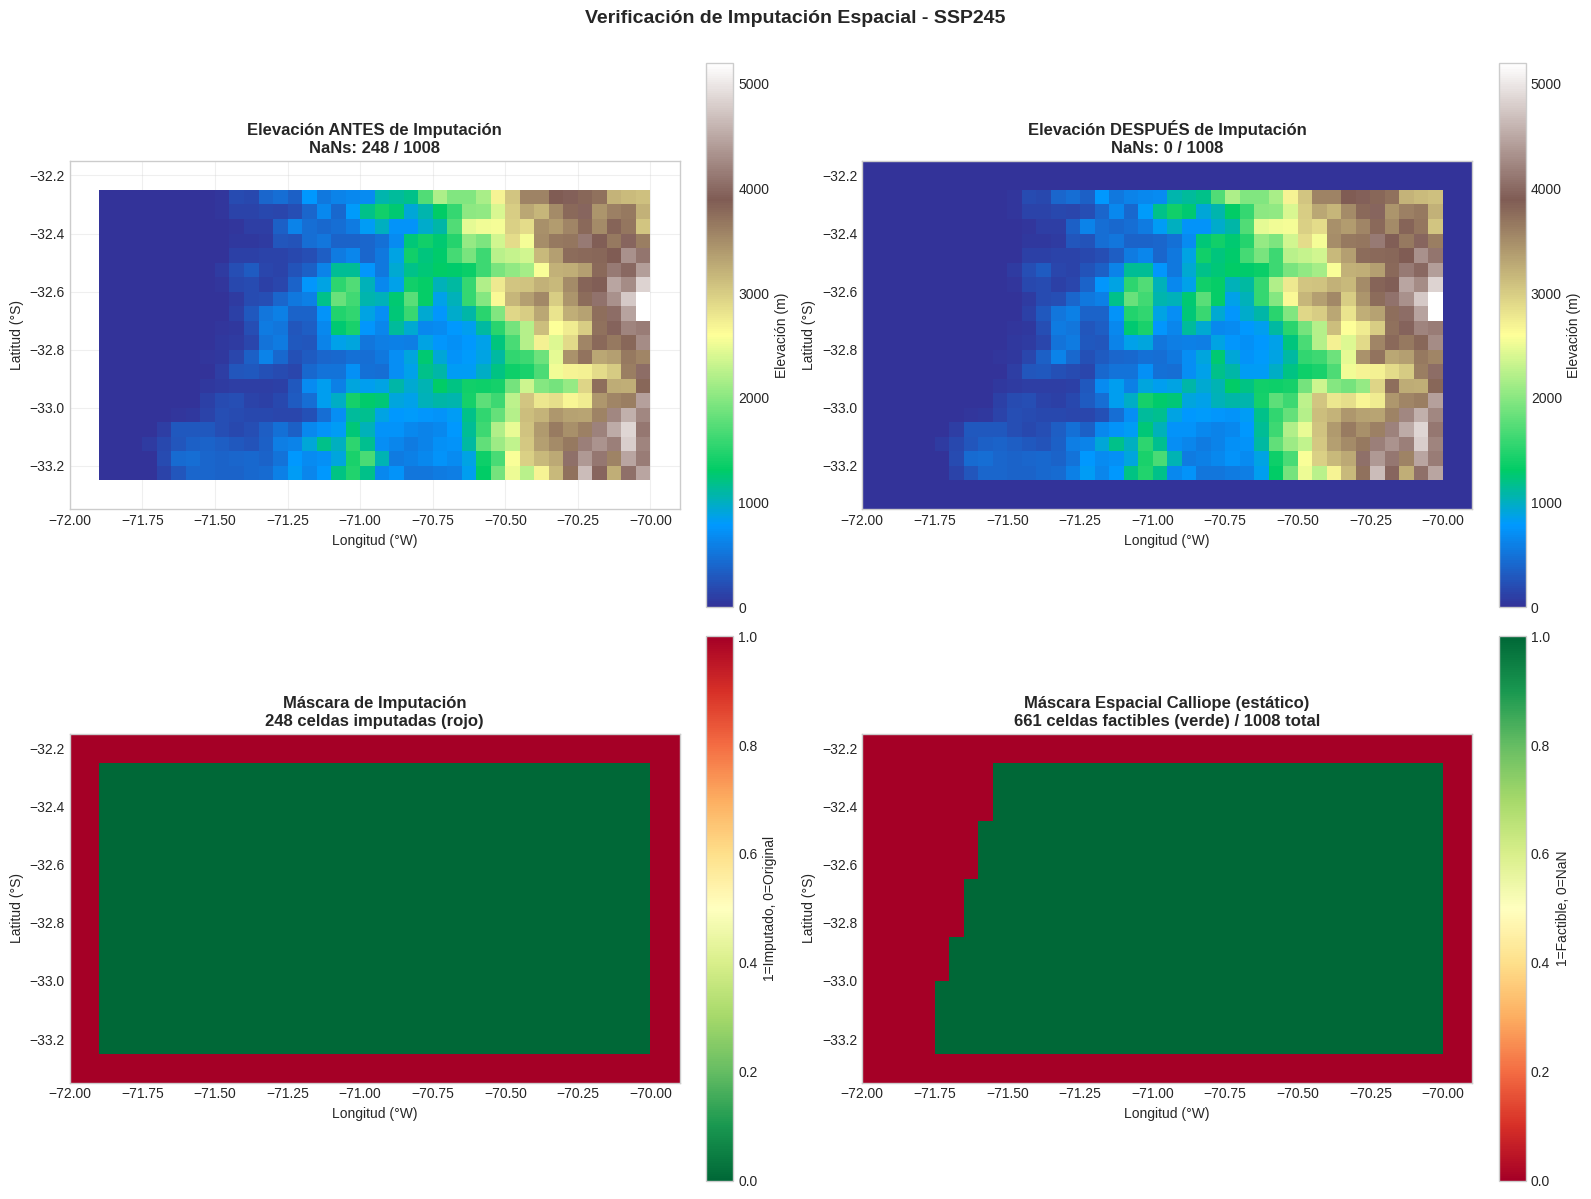


✅ VERIFICACIÓN COMPLETADA

📌 CONCLUSIONES:
   • Topografía: NaNs imputados con fillna(0)
   • Uso de suelo: NaNs imputados según tipo de variable
   • Calliope: Variables temporales (year, lat, lon) - NaNs preservados
   • Visualización: Promedio temporal para variables 3D


In [39]:
print("=" * 80)
print("🔍 VERIFICACIÓN POST-IMPUTACIÓN")
print("=" * 80)

# Usar dataset de referencia imputado
ds_imp = datasets_imputed['ssp245']

# Comparación de NaNs antes vs después
print(f"\n📊 COMPARACIÓN ANTES VS DESPUÉS (SSP245):")
print(f"{'='*80}")
print(f"{'Variable':<35} {'Antes':<15} {'Después':<15} {'Reducción'}")
print(f"{'='*80}")

for var in sorted(ds_imp.data_vars):
    # Original (si existe en datasets originales)
    if var in datasets['ssp245'].data_vars:
        nans_before = np.isnan(datasets['ssp245'][var].values).sum()
        total = datasets['ssp245'][var].size
    else:
        continue  # Saltar variables nuevas
    
    nans_after = np.isnan(ds_imp[var].values).sum()
    pct_before = (nans_before / total * 100) if total > 0 else 0
    pct_after = (nans_after / total * 100) if total > 0 else 0
    
    if nans_before > 0:
        reduction = f"{nans_before - nans_after:,} (-{pct_before-pct_after:.1f}%)"
        status = "✅" if nans_after == 0 else "⚠️"
        print(f"{status} {var:<32} {nans_before:>6,} ({pct_before:>5.1f}%) {nans_after:>6,} ({pct_after:>5.1f}%) {reduction}")

print(f"{'='*80}")

# Verificar coherencia de imputación
print(f"\n✅ VERIFICACIÓN DE COHERENCIA:")
print(f"{'='*80}")

# Variables topográficas
topo_elevation = ds_imp['topo_elevation'].values
topo_slope = ds_imp['topo_slope'].values

print(f"\n   🏔️ Topografía:")
print(f"      • topo_elevation: rango [{topo_elevation.min():.1f}, {topo_elevation.max():.1f}] m")
print(f"      • topo_slope: rango [{topo_slope.min():.1f}, {topo_slope.max():.1f}]°")
print(f"      • NaNs restantes: {np.isnan(topo_elevation).sum()} elevation, {np.isnan(topo_slope).sum()} slope")

# Variables de uso de suelo
landuse_vars = [v for v in ds_imp.data_vars if v.startswith('landuse_')]
print(f"\n   🌿 Uso de Suelo ({len(landuse_vars)} variables):")
for var in sorted(landuse_vars):
    vals = ds_imp[var].values
    nans = np.isnan(vals).sum()
    range_str = f"[{vals.min():.2f}, {vals.max():.2f}]"
    status = "✅" if nans == 0 else f"⚠️ {nans} NaNs"
    print(f"      • {var:25s}: {range_str:20s} {status}")

# Variables Calliope (deben mantener NaNs y pueden ser temporales)
calliope_vars = [v for v in ds_imp.data_vars if v.startswith('calliope_')]
if calliope_vars:
    print(f"\n   📍 Variables Calliope (máscara espacial):")
    for var in sorted(calliope_vars):
        var_data = ds_imp[var]
        vals = var_data.values
        nans = np.isnan(vals).sum()
        valid = vals.size - nans
        pct_valid = valid / vals.size * 100
        
        # Check if variable is temporal
        dims_str = f"({', '.join(var_data.dims)})"
        is_temporal = 'year' in var_data.dims
        time_info = f" | {len(var_data.year)} años" if is_temporal else ""
        
        print(f"      • {var:30s}: {dims_str:15s} {valid:5d}/{vals.size:5d} válidos ({pct_valid:5.1f}%){time_info}")

print(f"\n{'='*80}")

# Mapa de verificación: topografía antes/después
print("\nGenerando mapas de verificación...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Mapa 1: Elevación ANTES
ax1 = axes[0, 0]
elev_before = datasets['ssp245']['topo_elevation'].values.copy()
im1 = ax1.pcolormesh(
    ds_imp.lon,
    ds_imp.lat,
    elev_before,
    cmap='terrain',
    shading='auto'
)
ax1.set_title(
    f'Elevación ANTES de Imputación\n'
    f'NaNs: {np.isnan(elev_before).sum()} / {elev_before.size}',
    fontsize=12, fontweight='bold'
)
ax1.set_xlabel('Longitud (°W)', fontsize=10)
ax1.set_ylabel('Latitud (°S)', fontsize=10)
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Elevación (m)', fontsize=10)

# Mapa 2: Elevación DESPUÉS
ax2 = axes[0, 1]
elev_after = ds_imp['topo_elevation'].values
im2 = ax2.pcolormesh(
    ds_imp.lon,
    ds_imp.lat,
    elev_after,
    cmap='terrain',
    shading='auto'
)
ax2.set_title(
    f'Elevación DESPUÉS de Imputación\n'
    f'NaNs: {np.isnan(elev_after).sum()} / {elev_after.size}',
    fontsize=12, fontweight='bold'
)
ax2.set_xlabel('Longitud (°W)', fontsize=10)
ax2.set_ylabel('Latitud (°S)', fontsize=10)
ax2.set_aspect('equal', adjustable='box')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Elevación (m)', fontsize=10)

# Mapa 3: Máscara de imputación (diferencia)
ax3 = axes[1, 0]
imputation_mask = np.isnan(elev_before).astype(float)
im3 = ax3.pcolormesh(
    ds_imp.lon,
    ds_imp.lat,
    imputation_mask,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=1,
    shading='auto'
)
ax3.set_title(
    f'Máscara de Imputación\n'
    f'{imputation_mask.sum():.0f} celdas imputadas (rojo)',
    fontsize=12, fontweight='bold'
)
ax3.set_xlabel('Longitud (°W)', fontsize=10)
ax3.set_ylabel('Latitud (°S)', fontsize=10)
ax3.set_aspect('equal', adjustable='box')
ax3.grid(True, alpha=0.3)
cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label('1=Imputado, 0=Original', fontsize=10)

# Mapa 4: Máscara Calliope (ejemplo: producción H2)
ax4 = axes[1, 1]
if 'calliope_h2_prod_ton' in ds_imp.data_vars:
    h2_prod_var = ds_imp['calliope_h2_prod_ton']
    
    # Si es temporal (3D), tomar promedio temporal o un año específico
    if 'year' in h2_prod_var.dims:
        # Usar promedio temporal para visualización
        h2_prod = h2_prod_var.mean(dim='year').values
        year_label = f"(promedio {len(h2_prod_var.year)} años)"
    else:
        # Variable estática (2D)
        h2_prod = h2_prod_var.values
        year_label = "(estático)"
    
    calliope_mask = ~np.isnan(h2_prod)
    im4 = ax4.pcolormesh(
        ds_imp.lon,
        ds_imp.lat,
        calliope_mask.astype(float),
        cmap='RdYlGn',
        vmin=0,
        vmax=1,
        shading='auto'
    )
    n_valid = calliope_mask.sum()
    ax4.set_title(
        f'Máscara Espacial Calliope {year_label}\n'
        f'{n_valid} celdas factibles (verde) / {h2_prod.size} total',
        fontsize=12, fontweight='bold'
    )
    ax4.set_xlabel('Longitud (°W)', fontsize=10)
    ax4.set_ylabel('Latitud (°S)', fontsize=10)
    ax4.set_aspect('equal', adjustable='box')
    ax4.grid(True, alpha=0.3)
    cbar4 = plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    cbar4.set_label('1=Factible, 0=NaN', fontsize=10)
else:
    ax4.text(0.5, 0.5, 'Variable Calliope\nno disponible', 
             ha='center', va='center', fontsize=14)
    ax4.axis('off')

plt.suptitle(
    'Verificación de Imputación Espacial - SSP245',
    fontsize=14, fontweight='bold', y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.99])

fig_path = PLOTS_DIR / f'imputation_verification_{MODE}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✅ Guardado: {fig_path}")

plt.show()

print("\n" + "=" * 80)
print("✅ VERIFICACIÓN COMPLETADA")
print("=" * 80)
print("\n📌 CONCLUSIONES:")
print("   • Topografía: NaNs imputados con fillna(0)")
print("   • Uso de suelo: NaNs imputados según tipo de variable")
print("   • Calliope: Variables temporales (year, lat, lon) - NaNs preservados")
print("   • Visualización: Promedio temporal para variables 3D")
print("=" * 80)

## 🔟 Guardar Datasets Imputados

In [40]:
print("=" * 80)
print("💾 GUARDANDO DATASETS IMPUTADOS")
print("=" * 80)

# Configuración de encoding para compresión
encoding_config = {
    v: {'zlib': True, 'complevel': 4, 'dtype': 'float32'} 
    for scenario in datasets_imputed.keys()
    for v in datasets_imputed[scenario].data_vars
}

# Guardar cada escenario
saved_files = []

for scenario, ds_imp in datasets_imputed.items():
    # Nombre del archivo de salida
    out_file = DATA_DIR / f'autoencoder_stack_{scenario}_{MODE}_imputed.nc'
    
    print(f"\n📝 Guardando {scenario.upper()}...")
    print(f"   Archivo: {out_file.name}")
    
    # Añadir metadatos globales sobre la imputación
    ds_imp.attrs['imputation_applied'] = 'True'
    ds_imp.attrs['imputation_date'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    ds_imp.attrs['imputation_strategy'] = (
        'topo_*=0 (ocean), landuse_restricted=1.0 (ocean), '
        'landuse_*=0.0 (ocean), calliope_*=NaN (spatial mask), is_land added'
    )
    ds_imp.attrs['total_variables'] = len(ds_imp.data_vars)
    
    # Encoding específico por variable
    var_encoding = {}
    for var in ds_imp.data_vars:
        var_encoding[var] = {
            'zlib': True,
            'complevel': 4,
            'dtype': 'float32'
        }
        
        # Para variables temporales, preservar chunks
        if 'year' in ds_imp[var].dims:
            var_encoding[var]['chunksizes'] = (10, len(ds_imp.lat), len(ds_imp.lon))
    
    # Guardar
    ds_imp.to_netcdf(
        out_file,
        encoding=var_encoding,
        engine='netcdf4'
    )
    
    # Verificar tamaño del archivo
    file_size = out_file.stat().st_size / (1024**2)  # MB
    print(f"   Tamaño: {file_size:.2f} MB")
    print(f"   Variables: {len(ds_imp.data_vars)}")
    print(f"   ✅ Guardado exitoso")
    
    saved_files.append((scenario, out_file, file_size))

# Resumen final
print(f"\n{'='*80}")
print("✅ TODOS LOS DATASETS GUARDADOS")
print(f"{'='*80}")

print(f"\n📊 RESUMEN DE ARCHIVOS:")
total_size = 0
for scenario, filepath, size in saved_files:
    total_size += size
    print(f"   • {scenario.upper():8s}: {filepath.name} ({size:.2f} MB)")

print(f"\n   Total: {total_size:.2f} MB")

print(f"\n📁 Ubicación: {DATA_DIR}")

# Comparación con archivos originales
print(f"\n🔍 COMPARACIÓN CON ORIGINALES:")
for scenario, filepath, size in saved_files:
    original_file = DATA_DIR / f'autoencoder_stack_{scenario}_{MODE}.nc'
    if original_file.exists():
        original_size = original_file.stat().st_size / (1024**2)
        diff_size = size - original_size
        diff_pct = (diff_size / original_size * 100) if original_size > 0 else 0
        symbol = "+" if diff_size > 0 else ""
        print(f"   • {scenario.upper():8s}: {original_size:.2f} MB → {size:.2f} MB ({symbol}{diff_pct:+.1f}%)")

print(f"\n{'='*80}")
print("💡 PRÓXIMOS PASOS")
print(f"{'='*80}")
print("""
1. ✅ Datasets imputados guardados con sufijo '_imputed.nc'
2. ✅ Nueva variable 'is_land' disponible en todos los escenarios
3. ✅ NaNs reducidos en topografía y uso de suelo
4. ⚠️ Variables Calliope mantienen NaNs (máscara espacial)

📋 Para usar en siguiente notebook:
   
   # Cargar datasets imputados
   import xarray as xr
   from pathlib import Path
   
   DATA_DIR = Path('data/autoencoder_stack')
   MODE = 'test'
   SCENARIO = 'ssp245'
   
   ds = xr.open_dataset(
       DATA_DIR / f'autoencoder_stack_{SCENARIO}_{MODE}_imputed.nc'
   )
   
   # Filtrar solo celdas terrestres
   land_mask = ds['is_land'].values == 1
   
   # O filtrar solo celdas con datos de Calliope válidos
   h2_mask = ~np.isnan(ds['calliope_h2_prod_ton'].values)
   
   # Celdas con ambas condiciones (tierra + H2V factible)
   valid_mask = land_mask & h2_mask  # 661 celdas

🎯 Siguiente notebook: 02_preprocess_for_autoencoder.ipynb
   - Normalización de variables
   - Manejo de variables temporales
   - Splits train/val/test
   - Export de tensores procesados
""")
print("=" * 80)

💾 GUARDANDO DATASETS IMPUTADOS

📝 Guardando SSP245...
   Archivo: autoencoder_stack_ssp245_test_imputed.nc
   Tamaño: 1.43 MB
   Variables: 21
   ✅ Guardado exitoso

📝 Guardando SSP370...
   Archivo: autoencoder_stack_ssp370_test_imputed.nc
   Tamaño: 1.43 MB
   Variables: 21
   ✅ Guardado exitoso

📝 Guardando SSP585...
   Archivo: autoencoder_stack_ssp585_test_imputed.nc
   Tamaño: 1.42 MB
   Variables: 21
   ✅ Guardado exitoso

✅ TODOS LOS DATASETS GUARDADOS

📊 RESUMEN DE ARCHIVOS:
   • SSP245  : autoencoder_stack_ssp245_test_imputed.nc (1.43 MB)
   • SSP370  : autoencoder_stack_ssp370_test_imputed.nc (1.43 MB)
   • SSP585  : autoencoder_stack_ssp585_test_imputed.nc (1.42 MB)

   Total: 4.27 MB

📁 Ubicación: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack

🔍 COMPARACIÓN CON ORIGINALES:
   • SSP245  : 1.36 MB → 1.43 MB (++4.6%)
   • SSP370  : 1.37 MB → 1.43 MB (++4.2%)
   • SSP585  : 1.37 MB → 1.42 MB (++4.0%)

💡 PRÓXIMOS PASOS

1. ✅ Datasets imputados guardados c

## 🎉 Resumen Final - Tratamiento de NaNs Completado

🎉 RESUMEN FINAL - TRATAMIENTO DE NaNs COMPLETADO

✅ Figura guardada: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/nan_treatment_summary_test.png


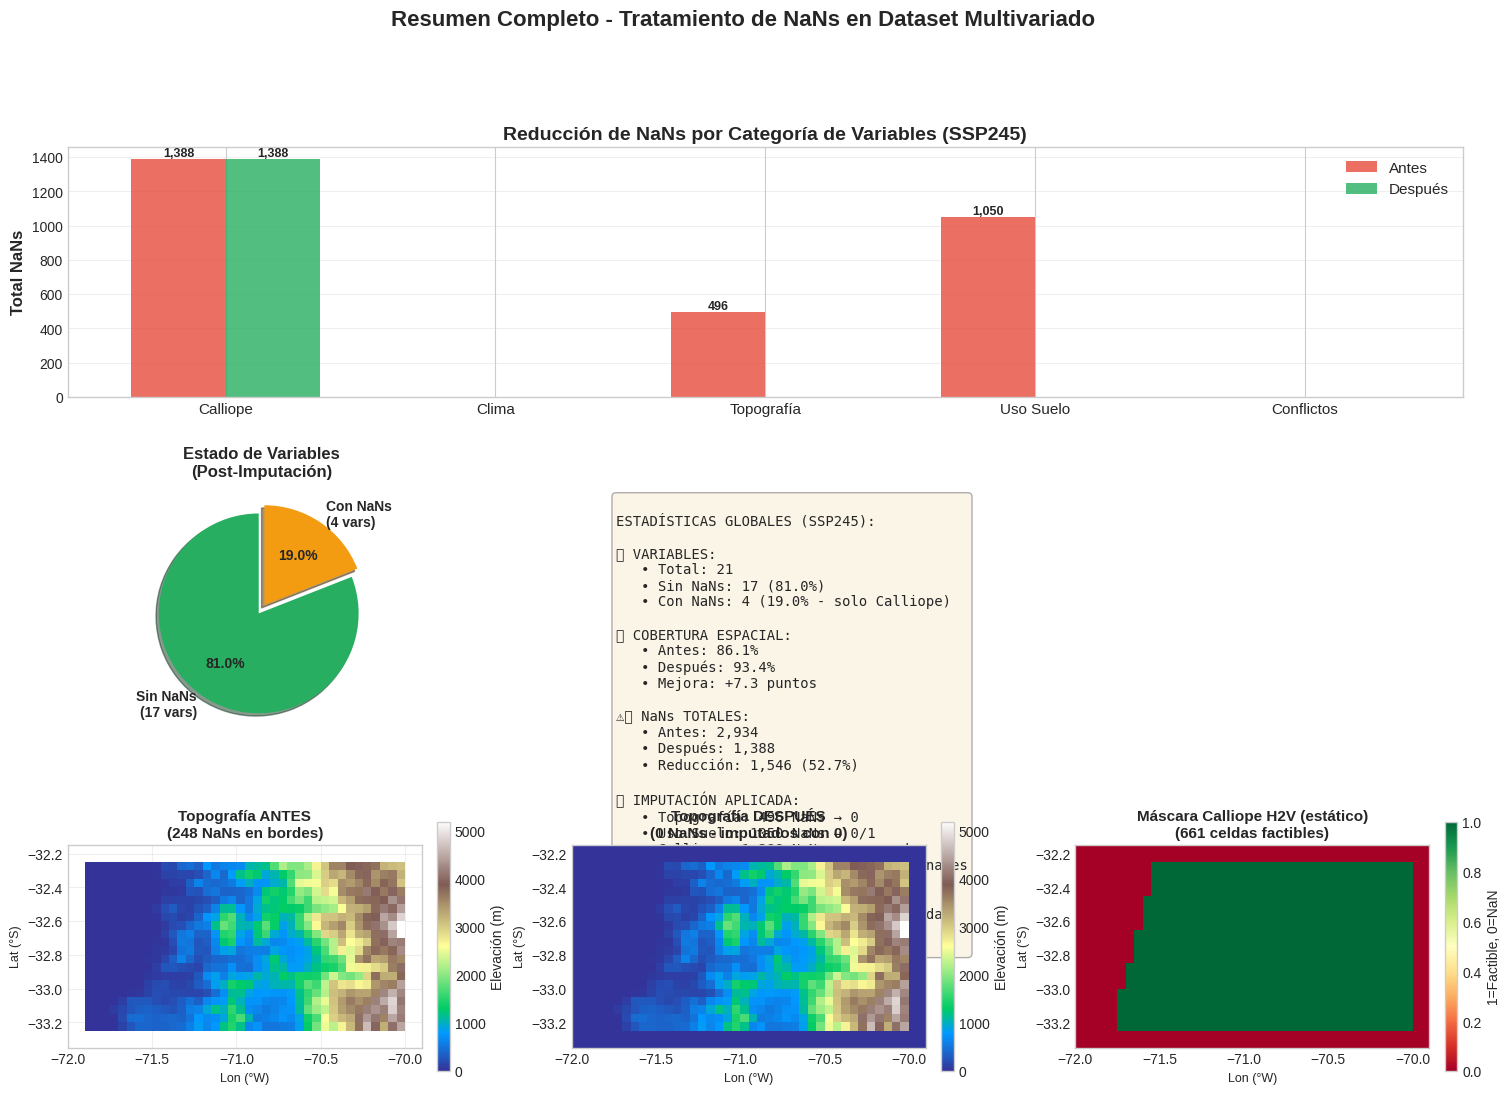


📋 ARCHIVOS GENERADOS EN ESTA SESIÓN

📊 Visualizaciones (8):
   • correlation_matrix_static_test.png                 (  305.1 KB)
   • coverage_maps_by_category_test.png                 (  428.4 KB)
   • dataset_metadata_test.csv                          (    3.2 KB)
   • distributions_static_vars_test.png                 (  484.6 KB)
   • imputation_verification_test.png                   (  364.0 KB)
   • nan_analysis_test.csv                              (    1.6 KB)
   • nan_spatial_patterns_test.png                      (  541.9 KB)
   • nan_treatment_summary_test.png                     (  588.2 KB)

🎯 PRÓXIMOS PASOS RECOMENDADOS

✅ ESTADO ACTUAL:
   • 3 escenarios procesados: ssp245, ssp370, ssp585
   • 17/21 variables sin NaNs
   • 661 celdas factibles para H2V

📓 SIGUIENTE NOTEBOOK: 02_preprocess_for_autoencoder.ipynb

   Tareas clave:
   1. Cargar datasets imputados desde: data/autoencoder_stack/ssp*_imputed.nc
   2. Normalización/estandarización por tipo de variable:
      •

In [41]:
print("=" * 80)
print("🎉 RESUMEN FINAL - TRATAMIENTO DE NaNs COMPLETADO")
print("=" * 80)

# Calcular estadísticas reales dinámicamente
ds_before = datasets['ssp245']
ds_after = datasets_imputed['ssp245']

# Categorización de variables
var_categories = {
    'Calliope': [v for v in ds_after.data_vars if v.startswith('calliope_')],
    'Clima': [v for v in ds_after.data_vars if v in [
        'tasmin_mean', 'tasmax_mean', 'pr_sum', 
        'cdd_max', 'cwd_max', 'r95p_sum', 'rx5day_max', 'wsdi_count'
    ]],
    'Topografía': ['topo_elevation', 'topo_slope'],
    'Uso Suelo': [v for v in ds_after.data_vars if v.startswith('landuse_')],
    'Conflictos': ['conflict_density', 'conflict_proximity']
}

# Contar NaNs antes/después por categoría
nans_stats = {}
for cat, vars_list in var_categories.items():
    nans_before_cat = sum(np.isnan(ds_before[v].values).sum() for v in vars_list if v in ds_before.data_vars)
    nans_after_cat = sum(np.isnan(ds_after[v].values).sum() for v in vars_list)
    nans_stats[cat] = {
        'before': nans_before_cat,
        'after': nans_after_cat,
        'reduced': nans_before_cat - nans_after_cat,
        'n_vars': len(vars_list)
    }

# Crear figura
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Gráfico de barras: NaNs antes vs después por categoría
ax1 = fig.add_subplot(gs[0, :])
categories = list(nans_stats.keys())
nans_before = [nans_stats[cat]['before'] for cat in categories]
nans_after = [nans_stats[cat]['after'] for cat in categories]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, nans_before, width, label='Antes', color='#e74c3c', alpha=0.8)
bars2 = ax1.bar(x + width/2, nans_after, width, label='Después', color='#27ae60', alpha=0.8)

ax1.set_ylabel('Total NaNs', fontsize=12, fontweight='bold')
ax1.set_title('Reducción de NaNs por Categoría de Variables (SSP245)', 
             fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=11)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bar in bars1:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Pie chart: Distribución de variables por estado de NaNs
ax2 = fig.add_subplot(gs[1, 0])

n_vars_no_nans = sum(1 for v in ds_after.data_vars if np.isnan(ds_after[v].values).sum() == 0)
n_vars_with_nans = len(ds_after.data_vars) - n_vars_no_nans

coverage_labels = [f'Sin NaNs\n({n_vars_no_nans} vars)', f'Con NaNs\n({n_vars_with_nans} vars)']
coverage_sizes = [n_vars_no_nans, n_vars_with_nans]
coverage_colors = ['#27ae60', '#f39c12']
explode = (0.05, 0.05)

ax2.pie(coverage_sizes, explode=explode, labels=coverage_labels, colors=coverage_colors,
        autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Estado de Variables\n(Post-Imputación)', 
             fontsize=12, fontweight='bold')

# 3. Estadísticas clave (calculadas dinámicamente)
ax3 = fig.add_subplot(gs[1, 1:])
ax3.axis('off')

# Calcular estadísticas totales
total_nans_before = sum(s['before'] for s in nans_stats.values())
total_nans_after = sum(s['after'] for s in nans_stats.values())
nans_reduced = total_nans_before - total_nans_after
pct_reduction = (nans_reduced / total_nans_before * 100) if total_nans_before > 0 else 0

total_values = ds_after.dims['lat'] * ds_after.dims['lon'] * len(ds_after.data_vars)
coverage_before = (1 - total_nans_before / total_values) * 100
coverage_after = (1 - total_nans_after / total_values) * 100

# Manejar variable temporal de Calliope para contar celdas factibles
h2_prod_var = ds_after['calliope_h2_prod_ton']
if 'year' in h2_prod_var.dims:
    # Variable temporal: tomar un año o promedio
    h2_prod_2d = h2_prod_var.mean(dim='year').values
else:
    # Variable estática
    h2_prod_2d = h2_prod_var.values

n_h2_valid = (~np.isnan(h2_prod_2d)).sum()

stats_text = f"""
ESTADÍSTICAS GLOBALES (SSP245):

📊 VARIABLES:
   • Total: {len(ds_after.data_vars)}
   • Sin NaNs: {n_vars_no_nans} ({n_vars_no_nans/len(ds_after.data_vars)*100:.1f}%)
   • Con NaNs: {n_vars_with_nans} ({n_vars_with_nans/len(ds_after.data_vars)*100:.1f}% - solo Calliope)

📈 COBERTURA ESPACIAL:
   • Antes: {coverage_before:.1f}%
   • Después: {coverage_after:.1f}%
   • Mejora: +{coverage_after - coverage_before:.1f} puntos

⚠️ NaNs TOTALES:
   • Antes: {total_nans_before:,}
   • Después: {total_nans_after:,}
   • Reducción: {nans_reduced:,} ({pct_reduction:.1f}%)

✅ IMPUTACIÓN APLICADA:
   • Topografía: {nans_stats['Topografía']['reduced']} NaNs → 0
   • Uso Suelo: {nans_stats['Uso Suelo']['reduced']} NaNs → 0/1
   • Calliope: {nans_stats['Calliope']['after']:,} NaNs preservados
   • Clima/Conflictos: Sin NaNs originales

🗺️ DIMENSIONES:
   • Grid: {ds_after.dims['lat']} lat × {ds_after.dims['lon']} lon = {ds_after.dims['lat'] * ds_after.dims['lon']} celdas
   • Celdas H2V factibles: {n_h2_valid}
"""

ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# 4. Mapas comparativos: Topografía antes vs después
ax4 = fig.add_subplot(gs[2, 0])
topo_before = ds_before['topo_elevation'].values.copy()
nans_topo_before = np.isnan(topo_before).sum()
im4 = ax4.pcolormesh(ds_before.lon, ds_before.lat,
                     np.ma.masked_invalid(topo_before),
                     cmap='terrain', shading='auto')
ax4.set_title(f'Topografía ANTES\n({nans_topo_before} NaNs en bordes)', 
             fontsize=11, fontweight='bold')
ax4.set_xlabel('Lon (°W)', fontsize=9)
ax4.set_ylabel('Lat (°S)', fontsize=9)
ax4.set_aspect('equal', adjustable='box')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04, label='Elevación (m)')
ax4.grid(True, alpha=0.3)

# Mapa 5: Después (sin NaNs)
ax5 = fig.add_subplot(gs[2, 1])
topo_after = ds_after['topo_elevation'].values
nans_topo_after = np.isnan(topo_after).sum()
im5 = ax5.pcolormesh(ds_after.lon, ds_after.lat,
                     topo_after, cmap='terrain', shading='auto')
ax5.set_title(f'Topografía DESPUÉS\n({nans_topo_after} NaNs - imputados con 0)', 
             fontsize=11, fontweight='bold')
ax5.set_xlabel('Lon (°W)', fontsize=9)
ax5.set_ylabel('Lat (°S)', fontsize=9)
ax5.set_aspect('equal', adjustable='box')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04, label='Elevación (m)')
ax5.grid(True, alpha=0.3)

# Mapa 6: Máscara Calliope (H2 Production)
ax6 = fig.add_subplot(gs[2, 2])
if 'calliope_h2_prod_ton' in ds_after.data_vars:
    # Manejar variable temporal
    h2_prod_var = ds_after['calliope_h2_prod_ton']
    if 'year' in h2_prod_var.dims:
        # Variable temporal: usar promedio
        h2_mask_data = h2_prod_var.mean(dim='year').values
        year_label = f"(promedio {len(h2_prod_var.year)} años)"
    else:
        # Variable estática
        h2_mask_data = h2_prod_var.values
        year_label = "(estático)"
    
    h2_mask = ~np.isnan(h2_mask_data)
    n_h2_valid = h2_mask.sum()
    im6 = ax6.pcolormesh(ds_after.lon, ds_after.lat,
                         h2_mask.astype(float),
                         cmap='RdYlGn', vmin=0, vmax=1, shading='auto')
    ax6.set_title(f'Máscara Calliope H2V {year_label}\n({n_h2_valid} celdas factibles)', 
                 fontsize=11, fontweight='bold')
    ax6.set_xlabel('Lon (°W)', fontsize=9)
    ax6.set_ylabel('Lat (°S)', fontsize=9)
    ax6.set_aspect('equal', adjustable='box')
    plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04, label='1=Factible, 0=NaN')
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Variable Calliope\nno disponible', 
             ha='center', va='center', fontsize=12, fontweight='bold')
    ax6.set_xticks([])
    ax6.set_yticks([])

plt.suptitle('Resumen Completo - Tratamiento de NaNs en Dataset Multivariado',
            fontsize=16, fontweight='bold', y=0.995)

fig_path = PLOTS_DIR / f'nan_treatment_summary_{MODE}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Figura guardada: {fig_path}")

plt.show()

# Resumen textual final
print("\n" + "=" * 80)
print("📋 ARCHIVOS GENERADOS EN ESTA SESIÓN")
print("=" * 80)

all_files = sorted(PLOTS_DIR.glob(f'*_{MODE}.*'))
print(f"\n📊 Visualizaciones ({len(all_files)}):")
for f in all_files:
    size_kb = f.stat().st_size / 1024
    print(f"   • {f.name:<50s} ({size_kb:>7.1f} KB)")

print("\n" + "=" * 80)
print("🎯 PRÓXIMOS PASOS RECOMENDADOS")
print("=" * 80)
print(f"""
✅ ESTADO ACTUAL:
   • {len(datasets_imputed)} escenarios procesados: {', '.join(datasets_imputed.keys())}
   • {n_vars_no_nans}/{len(ds_after.data_vars)} variables sin NaNs
   • {n_h2_valid} celdas factibles para H2V

📓 SIGUIENTE NOTEBOOK: 02_preprocess_for_autoencoder.ipynb

   Tareas clave:
   1. Cargar datasets imputados desde: data/autoencoder_stack/ssp*_imputed.nc
   2. Normalización/estandarización por tipo de variable:
      • MinMaxScaler para topografía, conflictos
      • StandardScaler para clima
      • [0,1] ya normalizado para landuse
   3. Manejo de dimensión temporal (actualmente colapsada a estadísticos)
   4. Definir máscara espacial para entrenamiento:
      → h2_mask: usar solo celdas con datos Calliope válidos ({n_h2_valid} celdas)
   5. Splits espaciales: train/val/test (70/15/15 o similar)
   6. Export de arrays NumPy procesados para PyTorch

🔬 ARQUITECTURA SUGERIDA:

   Autoencoder Variacional (VAE):
      • Encoder: ({n_h2_valid}, {len(ds_after.data_vars)}) → latent_dim (7-15)
      • Decoder: latent_dim → ({n_h2_valid}, {len(ds_after.data_vars)})
      • Loss: Reconstruction + KL divergence
      • Output: Embeddings espaciales para clustering

   Alternativa - Masked Autoencoder:
      • Si quieres usar grid completo ({ds_after.dims['lat'] * ds_after.dims['lon']} celdas)
      • Masked loss solo en celdas válidas
      • Más complejo pero preserva estructura espacial 2D
""")
print("=" * 80)
print("\n✅ EXPLORACIÓN Y TRATAMIENTO DE NaNs COMPLETADO")
print("=" * 80)

## 6.7️⃣ Visualización de Patrones Espaciales de NaNs

Generando mapas de NaNs por categoría...
✅ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/nan_spatial_patterns_test.png


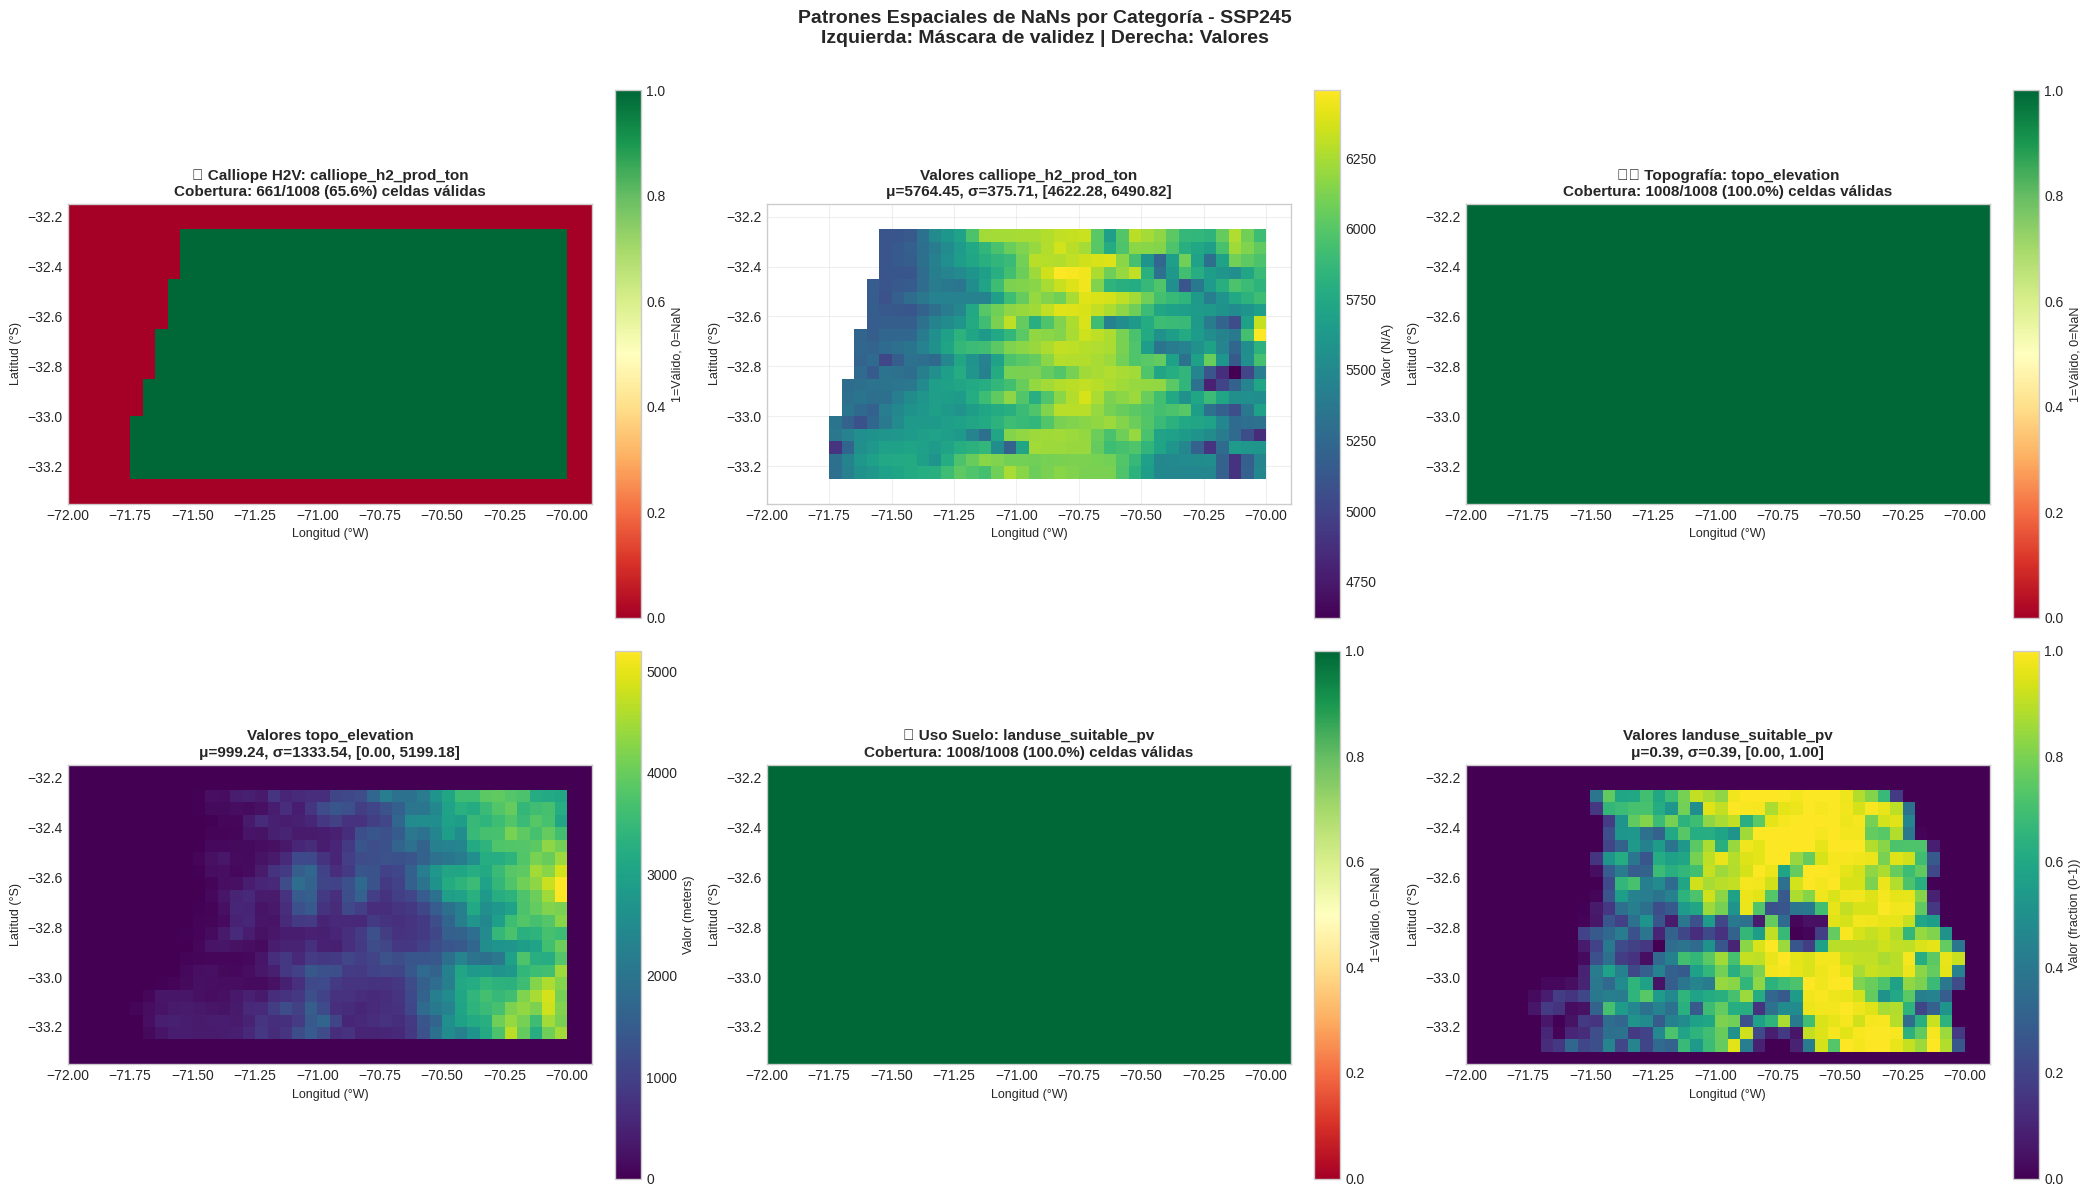


🔍 INTERPRETACIÓN DE PATRONES

    📍 CALLIOPE H2V:
       • Patrón: NaNs dispersos en grid
       • Causa: Solo locaciones factibles para H2V (restricciones técnicas/económicas)
       • Variables temporales: Escaladas con variación interanual de CF solar
       • Solución: Mantener NaNs (máscara espacial) o imputar con 0
    
    🏔️ TOPOGRAFÍA:
       • Patrón: NaNs concentrados en OESTE (costa del Pacífico)
       • Causa: Océano (sin datos de elevación terrestre)
       • Solución: Imputar con 0 (nivel del mar)
    
    🌿 USO SUELO:
       • Patrón: Similar a topografía (océano)
       • Causa: Sin cobertura MapBiomas en océano
       • Solución: Imputar con [1,0,0,0,0] (100% restricted)
    
    💡 CONCLUSIÓN:
       Los NaNs tienen 2 causas principales:
       1. Océano (topografía + uso suelo): ≈25% del grid → IMPUTAR
       2. Restricciones H2V (calliope): ≈34% del grid → MANTENER o IMPUTAR según modelo
       
    ⏰ DIMENSIÓN TEMPORAL:
       • Variables Calliope ahora incluyen 

In [42]:
if ds_ref is not None:
    print("Generando mapas de NaNs por categoría...")
    
    # Seleccionar 1 variable con NaNs por cada categoría afectada
    vars_with_nans = {
        'calliope': 'calliope_h2_prod_ton',
        'topo': 'topo_elevation',
        'landuse': 'landuse_suitable_pv'
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(21, 12))
    axes = axes.flatten()
    
    for i, (cat, var) in enumerate(vars_with_nans.items()):
        if var in ds_ref.data_vars:
            info = VAR_CATEGORIES[cat]
            
            # Mapa de datos válidos
            ax1 = axes[i*2]
            
            # Manejar variables temporales
            var_xr = ds_ref[var]
            if 'year' in var_xr.dims:
                # Variable temporal: usar promedio
                var_data = var_xr.mean(dim='year').values
                time_label = f" (promedio {len(var_xr.year)} años)"
            else:
                # Variable estática
                var_data = var_xr.values
                time_label = ""
            
            # Crear máscara de NaNs
            nan_mask = np.isnan(var_data).astype(float)
            
            # Plot de datos válidos (invertir máscara)
            valid_mask = 1 - nan_mask
            im1 = ax1.pcolormesh(
                ds_ref.lon,
                ds_ref.lat,
                valid_mask,
                cmap='RdYlGn',
                vmin=0,
                vmax=1,
                shading='auto'
            )
            
            n_valid = (valid_mask == 1).sum()
            n_total = valid_mask.size
            pct_valid = (n_valid / n_total) * 100
            
            ax1.set_title(
                f'{info["label"]}: {var}{time_label}\n'
                f'Cobertura: {n_valid}/{n_total} ({pct_valid:.1f}%) celdas válidas',
                fontsize=11, fontweight='bold'
            )
            ax1.set_xlabel('Longitud (°W)', fontsize=9)
            ax1.set_ylabel('Latitud (°S)', fontsize=9)
            ax1.set_aspect('equal', adjustable='box')
            ax1.grid(True, alpha=0.3)
            
            cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
            cbar1.set_label('1=Válido, 0=NaN', fontsize=9)
            
            # Mapa de valores (solo válidos)
            ax2 = axes[i*2 + 1]
            
            # Copiar datos y enmascarar NaNs
            data_to_plot = var_data.copy()
            data_to_plot[nan_mask.astype(bool)] = np.nan
            
            im2 = ax2.pcolormesh(
                ds_ref.lon,
                ds_ref.lat,
                data_to_plot,
                cmap='viridis',
                shading='auto'
            )
            
            # Estadísticas de valores válidos
            valid_values = var_data[~np.isnan(var_data)]
            if len(valid_values) > 0:
                mean_val = np.mean(valid_values)
                std_val = np.std(valid_values)
                min_val = np.min(valid_values)
                max_val = np.max(valid_values)
                
                ax2.set_title(
                    f'Valores {var}{time_label}\n'
                    f'μ={mean_val:.2f}, σ={std_val:.2f}, [{min_val:.2f}, {max_val:.2f}]',
                    fontsize=11, fontweight='bold'
                )
            else:
                ax2.set_title(f'Valores {var}{time_label}\n(Sin datos)', fontsize=11)
            
            ax2.set_xlabel('Longitud (°W)', fontsize=9)
            ax2.set_ylabel('Latitud (°S)', fontsize=9)
            ax2.set_aspect('equal', adjustable='box')
            ax2.grid(True, alpha=0.3)
            
            cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
            units = ds_ref[var].attrs.get('units', 'N/A')
            cbar2.set_label(f'Valor ({units})', fontsize=9)
    
    plt.suptitle(
        'Patrones Espaciales de NaNs por Categoría - SSP245\n'
        'Izquierda: Máscara de validez | Derecha: Valores',
        fontsize=14, fontweight='bold', y=0.995
    )
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    fig_path = PLOTS_DIR / f'nan_spatial_patterns_{MODE}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"✅ Guardado: {fig_path}")
    
    plt.show()
    
    # Resumen del patrón
    print("\n" + "=" * 80)
    print("🔍 INTERPRETACIÓN DE PATRONES")
    print("=" * 80)
    print("""
    📍 CALLIOPE H2V:
       • Patrón: NaNs dispersos en grid
       • Causa: Solo locaciones factibles para H2V (restricciones técnicas/económicas)
       • Variables temporales: Escaladas con variación interanual de CF solar
       • Solución: Mantener NaNs (máscara espacial) o imputar con 0
    
    🏔️ TOPOGRAFÍA:
       • Patrón: NaNs concentrados en OESTE (costa del Pacífico)
       • Causa: Océano (sin datos de elevación terrestre)
       • Solución: Imputar con 0 (nivel del mar)
    
    🌿 USO SUELO:
       • Patrón: Similar a topografía (océano)
       • Causa: Sin cobertura MapBiomas en océano
       • Solución: Imputar con [1,0,0,0,0] (100% restricted)
    
    💡 CONCLUSIÓN:
       Los NaNs tienen 2 causas principales:
       1. Océano (topografía + uso suelo): ≈25% del grid → IMPUTAR
       2. Restricciones H2V (calliope): ≈34% del grid → MANTENER o IMPUTAR según modelo
       
    ⏰ DIMENSIÓN TEMPORAL:
       • Variables Calliope ahora incluyen variación interanual (86 años)
       • Visualización usa promedio temporal para análisis espacial
       • Autoencoder puede entrenar con series temporales completas
    """)
    print("=" * 80)
else:
    print("⚠️ No hay dataset de referencia")

Generando visualizaciones de distribuciones...
✅ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/distributions_static_vars_test.png


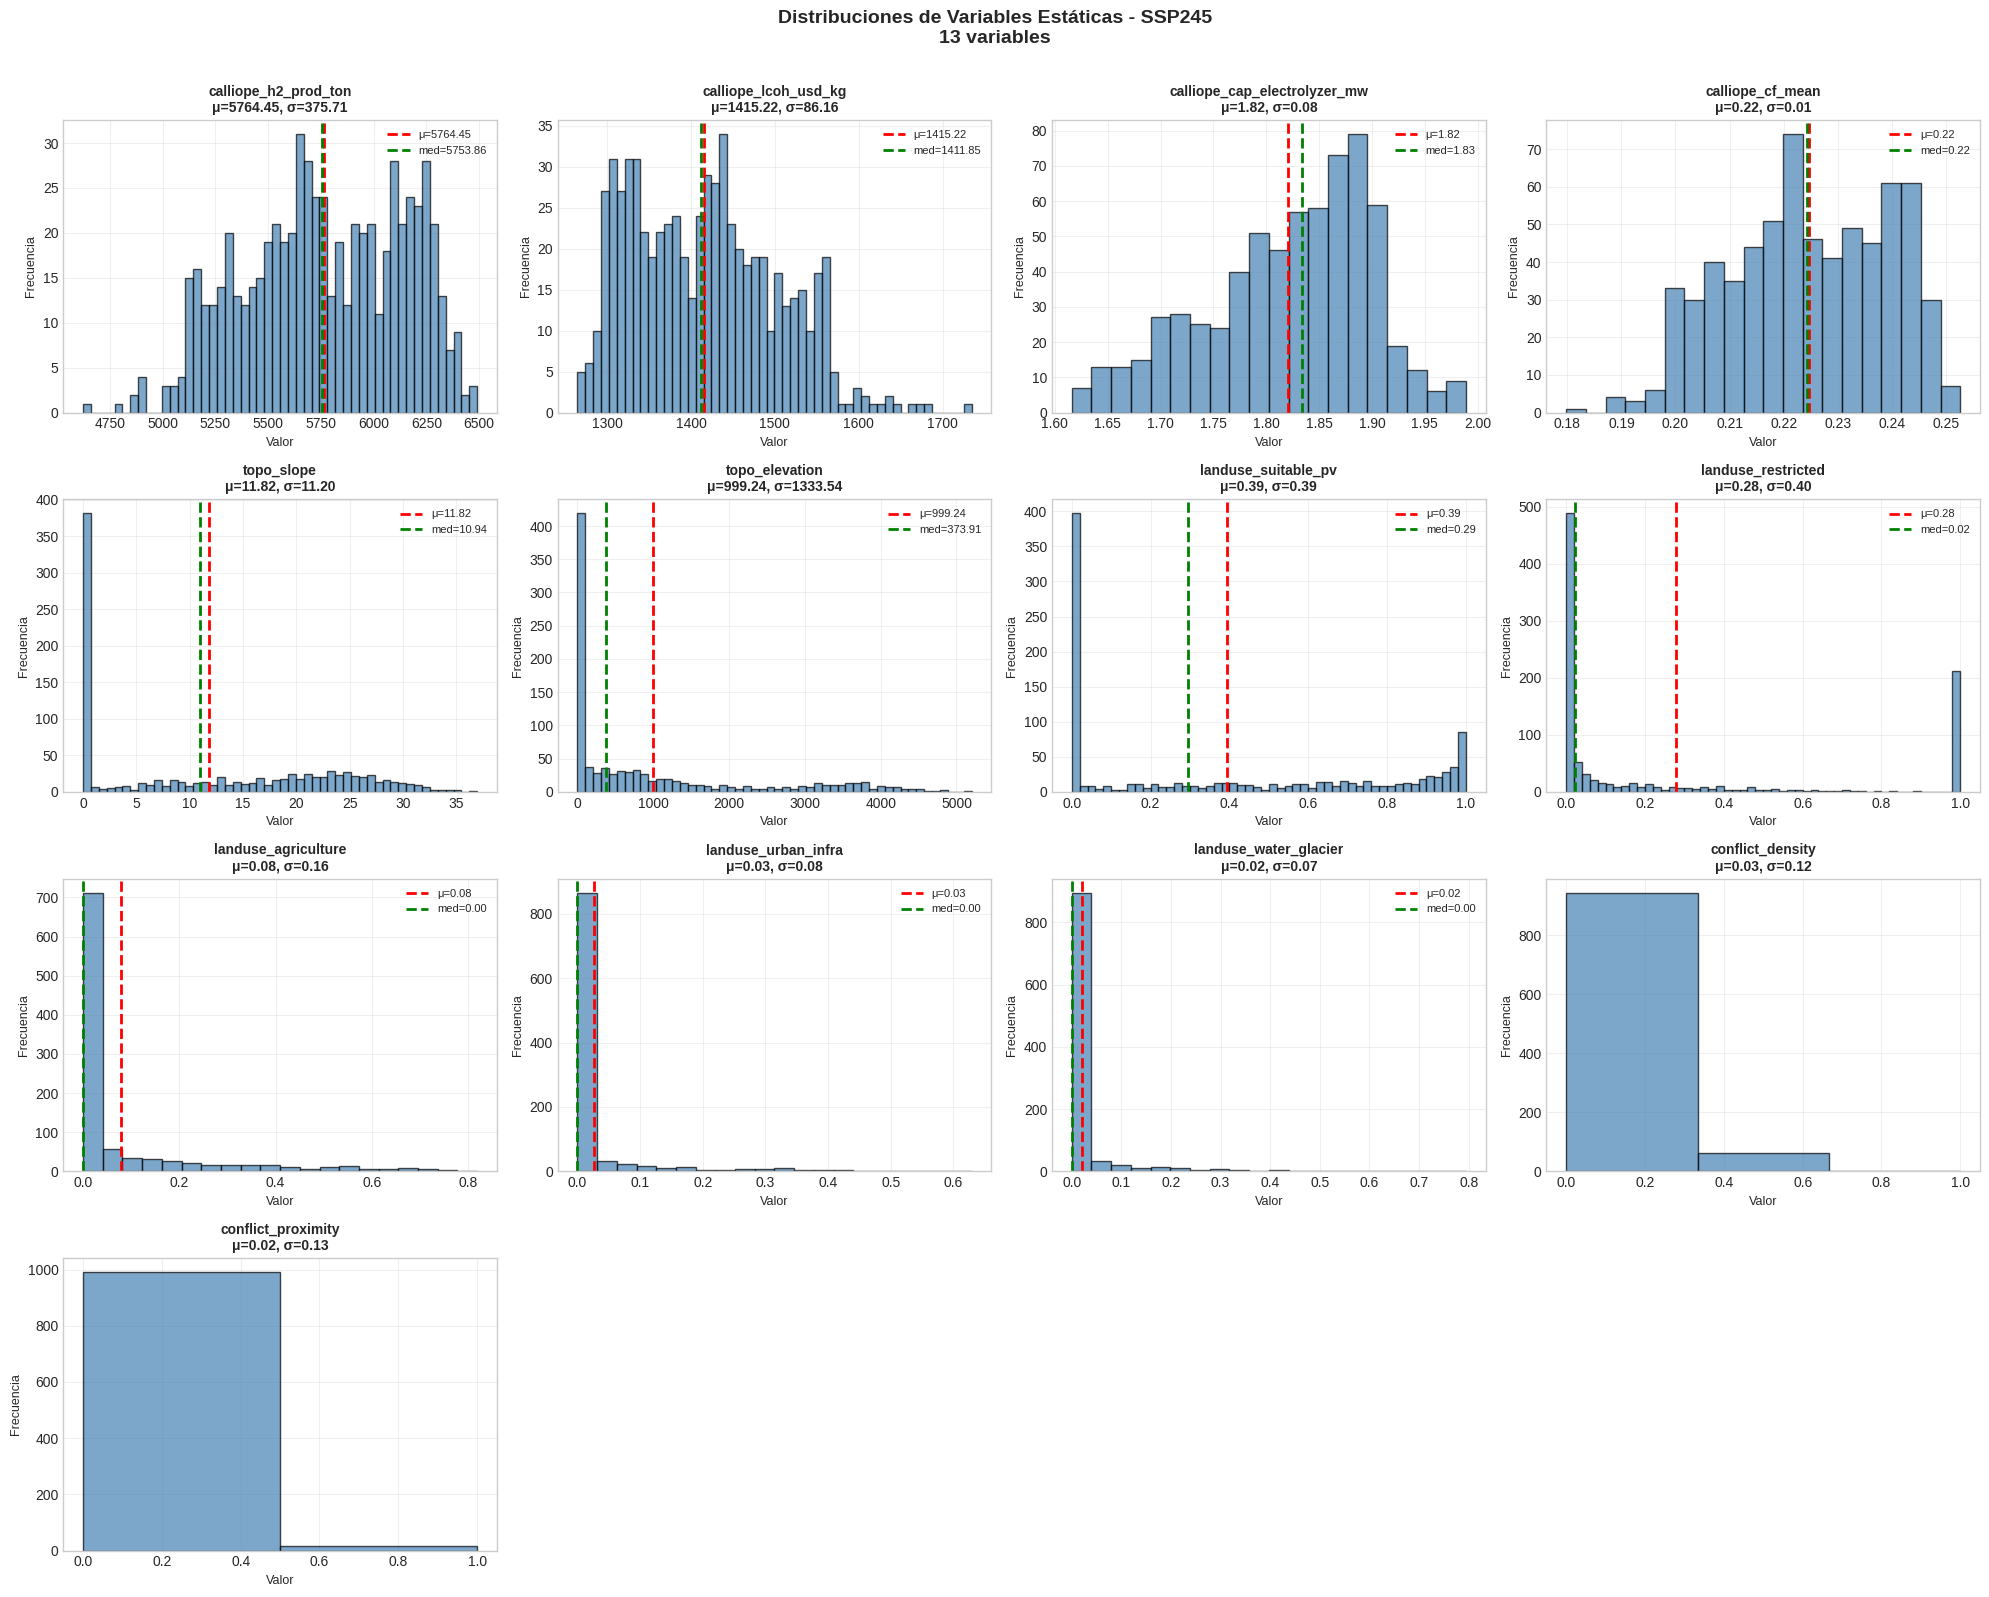

In [43]:
if ds_ref is not None and len(ds_ref.data_vars) > 0:
    print("Generando visualizaciones de distribuciones...")
    
    # Variables estáticas
    static_vars = [v for v in ds_ref.data_vars 
                   if 'year' not in ds_ref[v].dims and 'time' not in ds_ref[v].dims]
    
    if len(static_vars) > 0:
        n_vars = len(static_vars)
        n_cols = 4
        n_rows = int(np.ceil(n_vars / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = axes.flatten() if n_vars > 1 else [axes]
        
        for i, var in enumerate(static_vars):
            ax = axes[i]
            
            values = ds_ref[var].values.flatten()
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                # Determinar número óptimo de bins según rango de datos
                val_range = np.ptp(valid_values)  # peak-to-peak (max - min)
                n_unique = len(np.unique(valid_values))
                
                # Ajustar bins según tipo de variable
                if n_unique <= 10:
                    # Variable casi categórica o binaria
                    bins = n_unique
                elif val_range < 1.0:
                    # Variable con rango pequeño (fracciones)
                    bins = min(20, n_unique)
                else:
                    # Variable continua normal
                    bins = min(50, max(10, n_unique // 10))
                
                # Histograma con bins adaptativo
                try:
                    ax.hist(valid_values, bins=bins, alpha=0.7, color='steelblue', edgecolor='black')
                    
                    # Estadísticas
                    mean_val = np.mean(valid_values)
                    median_val = np.median(valid_values)
                    std_val = np.std(valid_values)
                    
                    # Solo agregar líneas si tiene sentido (no binarias)
                    if n_unique > 5:
                        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'μ={mean_val:.2f}')
                        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'med={median_val:.2f}')
                        ax.legend(fontsize=8)
                    
                    ax.set_title(f'{var}\nμ={mean_val:.2f}, σ={std_val:.2f}', 
                               fontsize=10, fontweight='bold')
                    ax.set_xlabel('Valor', fontsize=9)
                    ax.set_ylabel('Frecuencia', fontsize=9)
                    ax.grid(True, alpha=0.3)
                except ValueError as e:
                    # Fallback si aún falla
                    ax.text(0.5, 0.5, f'Error en histograma\n{str(e)[:40]}...', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=8)
                    ax.set_title(var, fontsize=10)
            else:
                ax.text(0.5, 0.5, 'Sin datos válidos', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(var, fontsize=10)
        
        # Ocultar ejes sobrantes
        for i in range(n_vars, len(axes)):
            axes[i].axis('off')
        
        plt.suptitle(f'Distribuciones de Variables Estáticas - SSP245\n{n_vars} variables', 
                    fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.99])
        
        fig_path = PLOTS_DIR / f'distributions_static_vars_{MODE}.png'
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {fig_path}")
        
        plt.show()
    else:
        print("⚠️ No hay variables estáticas para visualizar")
else:
    print("⚠️ No hay dataset o variables")

## 8️⃣ Matriz de Correlación (Variables Estáticas)

Calculando matriz de correlación...
✅ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/correlation_matrix_static_test.png


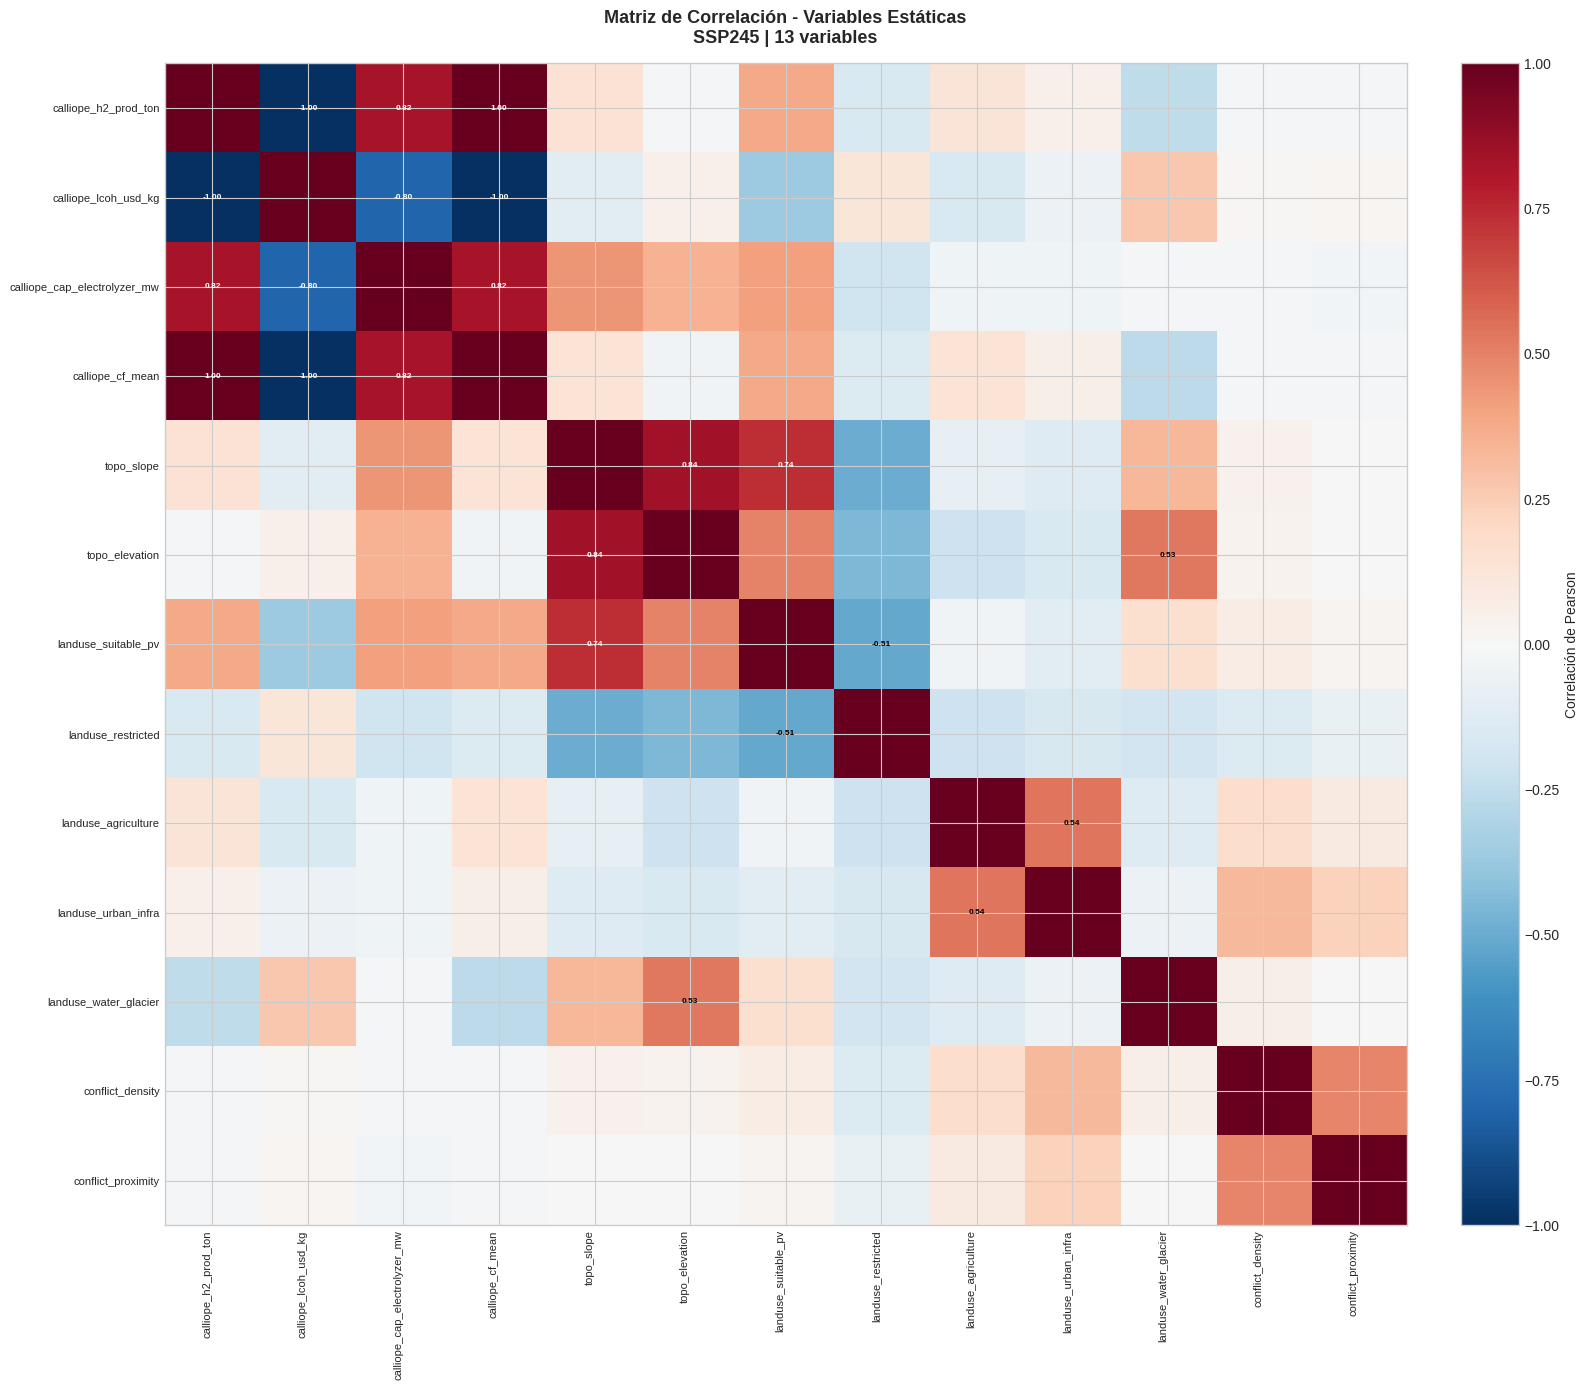


🔍 Top 10 Correlaciones más fuertes (|r| > 0.6):
  • calliope_h2_prod_ton           <-> calliope_cf_mean              : r=+1.000
  • calliope_lcoh_usd_kg           <-> calliope_cf_mean              : r=-0.996
  • calliope_h2_prod_ton           <-> calliope_lcoh_usd_kg          : r=-0.996
  • topo_slope                     <-> topo_elevation                : r=+0.837
  • calliope_h2_prod_ton           <-> calliope_cap_electrolyzer_mw  : r=+0.825
  • calliope_cap_electrolyzer_mw   <-> calliope_cf_mean              : r=+0.822
  • calliope_lcoh_usd_kg           <-> calliope_cap_electrolyzer_mw  : r=-0.796
  • topo_slope                     <-> landuse_suitable_pv           : r=+0.739


In [44]:
if ds_ref is not None:
    print("Calculando matriz de correlación...")
    
    # Variables estáticas
    static_vars = [v for v in ds_ref.data_vars 
                   if 'year' not in ds_ref[v].dims and 'time' not in ds_ref[v].dims]
    
    if len(static_vars) > 1:
        # Crear DataFrame con todas las variables estáticas
        data_dict = {}
        for var in static_vars:
            values = ds_ref[var].values.flatten()
            data_dict[var] = values
        
        df_corr = pd.DataFrame(data_dict)
        
        # Calcular correlación
        corr_matrix = df_corr.corr()
        
        # Visualizar
        fig, ax = plt.subplots(figsize=(16, 14))
        
        # Heatmap
        im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
        
        # Etiquetas
        ax.set_xticks(range(len(corr_matrix)))
        ax.set_yticks(range(len(corr_matrix)))
        ax.set_xticklabels(corr_matrix.columns, rotation=90, ha='right', fontsize=8)
        ax.set_yticklabels(corr_matrix.columns, fontsize=8)
        
        # Valores solo para correlaciones fuertes
        for i in range(len(corr_matrix)):
            for j in range(len(corr_matrix)):
                val = corr_matrix.iloc[i, j]
                if not np.isnan(val) and abs(val) > 0.5 and i != j:
                    color = 'white' if abs(val) > 0.7 else 'black'
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                           color=color, fontsize=6, fontweight='bold')
        
        plt.colorbar(im, ax=ax, label='Correlación de Pearson', fraction=0.046, pad=0.04)
        ax.set_title(
            f'Matriz de Correlación - Variables Estáticas\n'
            f'SSP245 | {len(static_vars)} variables',
            fontsize=13, fontweight='bold', pad=15
        )
        
        plt.tight_layout()
        
        fig_path = PLOTS_DIR / f'correlation_matrix_static_{MODE}.png'
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {fig_path}")
        
        plt.show()
        
        # Top correlaciones
        print("\n🔍 Top 10 Correlaciones más fuertes (|r| > 0.6):")
        corr_pairs = []
        for i in range(len(corr_matrix)):
            for j in range(i+1, len(corr_matrix)):
                val = corr_matrix.iloc[i, j]
                if not np.isnan(val):
                    var1 = corr_matrix.columns[i]
                    var2 = corr_matrix.columns[j]
                    corr_pairs.append((abs(val), val, var1, var2))
        
        corr_pairs.sort(reverse=True)
        for abs_val, val, var1, var2 in corr_pairs[:10]:
            if abs_val > 0.6:
                print(f"  • {var1:30s} <-> {var2:30s}: r={val:+.3f}")
    else:
        print("⚠️ Menos de 2 variables estáticas, no se puede calcular correlación")
else:
    print("⚠️ No hay dataset")

## 9️⃣ Mapas de Cobertura por Categoría

Generando mapas de cobertura...
✅ Guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/coverage_maps_by_category_test.png


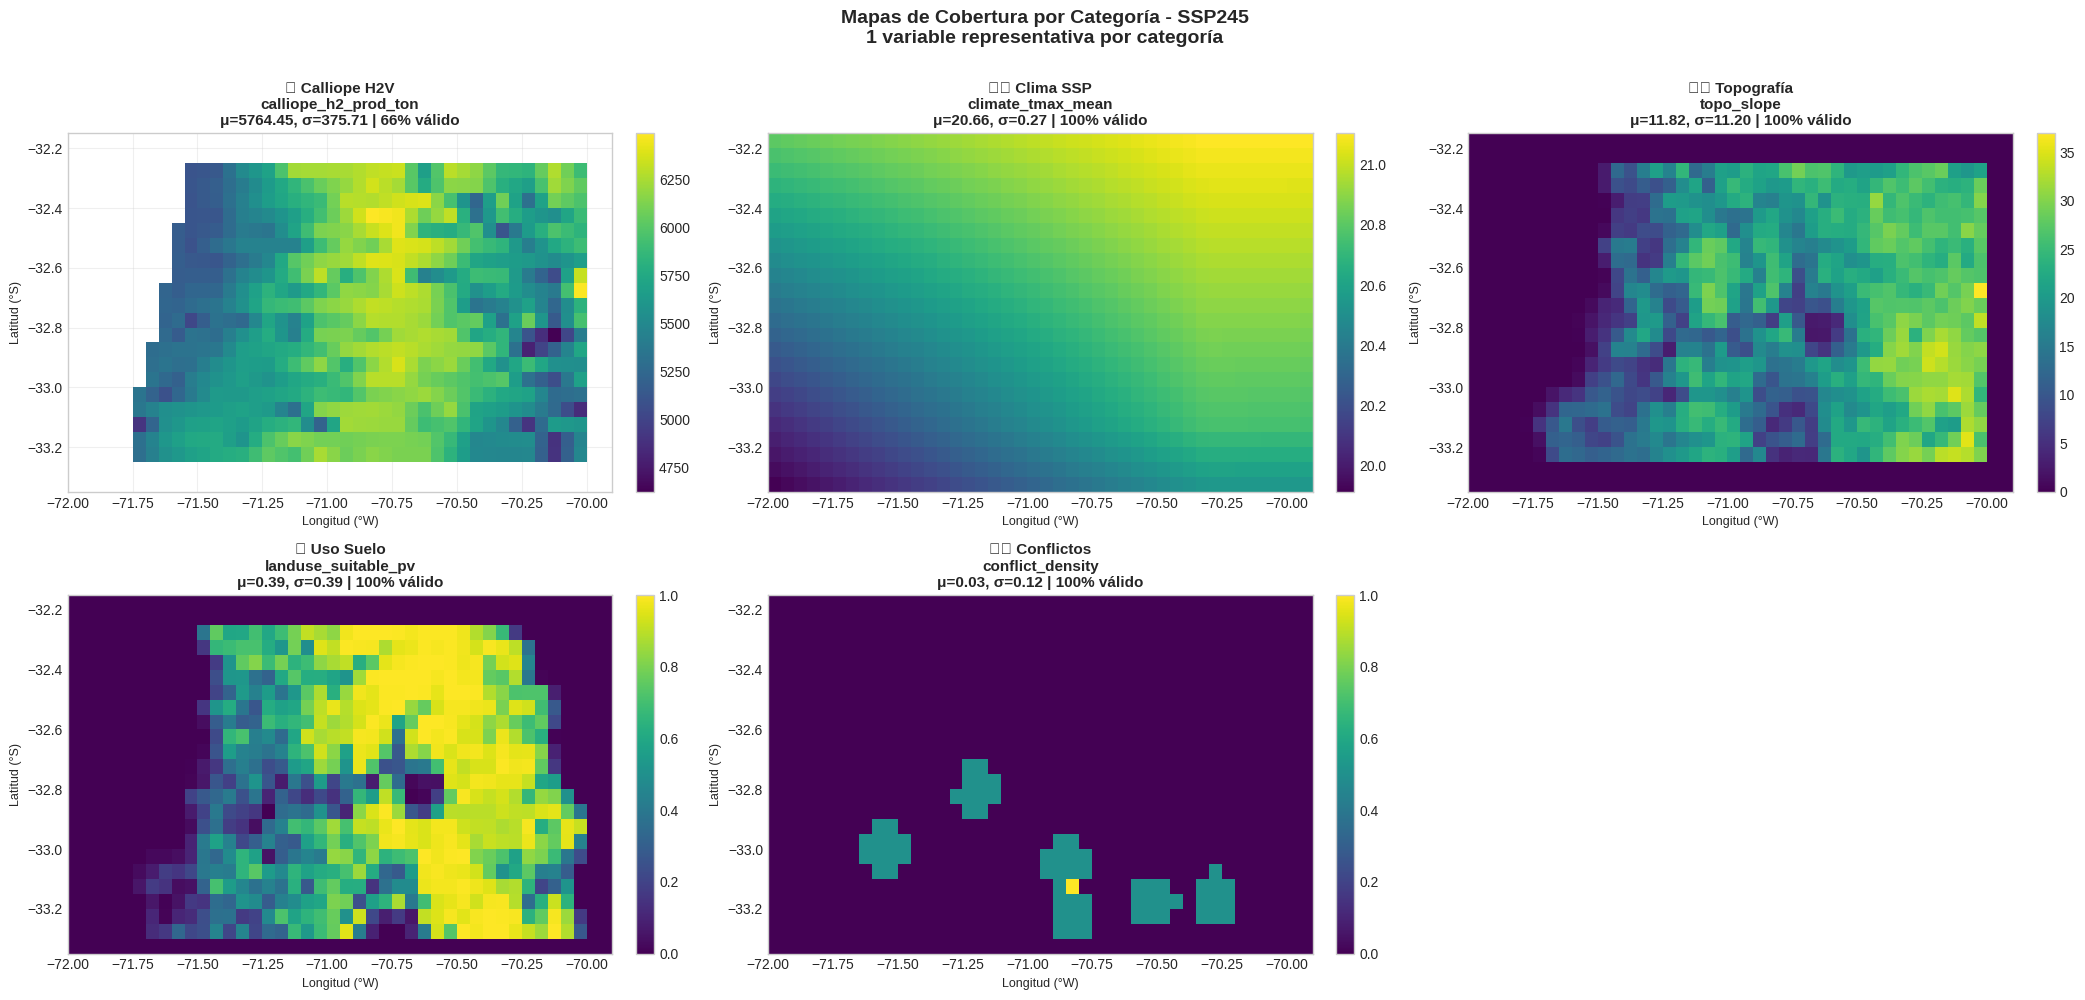

In [45]:
if ds_ref is not None:
    print("Generando mapas de cobertura...")
    
    # Seleccionar 1 variable representativa por categoría
    sample_vars = {}
    
    for cat, info in VAR_CATEGORIES.items():
        vars_in_cat = [v for v in ds_ref.data_vars if v.startswith(info['prefix'])]
        if vars_in_cat:
            # Tomar la primera
            sample_vars[cat] = vars_in_cat[0]
    
    if len(sample_vars) > 0:
        n_cats = len(sample_vars)
        n_cols = 3
        n_rows = int(np.ceil(n_cats / n_cols))
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows))
        axes = axes.flatten() if n_cats > 1 else [axes]
        
        for i, (cat, var) in enumerate(sample_vars.items()):
            ax = axes[i]
            info = VAR_CATEGORIES[cat]
            
            var_data = ds_ref[var]
            
            # Para temporales, promediar
            if 'year' in var_data.dims:
                plot_data = var_data.mean(dim='year').values
            else:
                plot_data = var_data.values
            
            # Plot
            im = ax.pcolormesh(
                ds_ref.lon,
                ds_ref.lat,
                plot_data,
                cmap='viridis',
                shading='auto'
            )
            
            # Estadísticas
            valid_data = plot_data[~np.isnan(plot_data)]
            if len(valid_data) > 0:
                mean_val = np.mean(valid_data)
                std_val = np.std(valid_data)
                n_valid = len(valid_data)
                pct_valid = (n_valid / plot_data.size) * 100
                
                ax.set_title(
                    f'{info["label"]}\n{var}\n'
                    f'μ={mean_val:.2f}, σ={std_val:.2f} | {pct_valid:.0f}% válido',
                    fontsize=11, fontweight='bold'
                )
            else:
                ax.set_title(f'{info["label"]}\n{var}\n(Sin datos)', fontsize=11)
            
            ax.set_xlabel('Longitud (°W)', fontsize=9)
            ax.set_ylabel('Latitud (°S)', fontsize=9)
            ax.grid(True, alpha=0.3)
            
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Ocultar ejes sobrantes
        for i in range(n_cats, len(axes)):
            axes[i].axis('off')
        
        plt.suptitle(
            f'Mapas de Cobertura por Categoría - SSP245\n'
            f'1 variable representativa por categoría',
            fontsize=14, fontweight='bold', y=0.995
        )
        plt.tight_layout(rect=[0, 0, 1, 0.99])
        
        fig_path = PLOTS_DIR / f'coverage_maps_by_category_{MODE}.png'
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"✅ Guardado: {fig_path}")
        
        plt.show()
    else:
        print("⚠️ No hay variables para mapear")
else:
    print("⚠️ No hay dataset")

## 🔟 Resumen Final

In [46]:
print("=" * 80)
print("📋 RESUMEN EJECUTIVO - EXPLORACIÓN DEL STACK")
print("=" * 80)

if len(datasets) > 0:
    print(f"\n✅ Escenarios cargados: {len(datasets)}/{len(SCENARIOS)}")
    for scenario in datasets.keys():
        print(f"   • {scenario.upper()}")
    
    if ds_ref is not None:
        print(f"\n📊 Dataset de referencia: SSP245")
        print(f"   Variables totales: {len(ds_ref.data_vars)}")
        print(f"   Grid: {len(ds_ref.lat)} × {len(ds_ref.lon)} = {len(ds_ref.lat)*len(ds_ref.lon)} celdas")
        
        if 'year' in ds_ref.dims:
            print(f"   Años: {len(ds_ref.year)} ({ds_ref.year.values[0]}-{ds_ref.year.values[-1]})")
        
        print(f"\n📈 Variables por categoría:")
        for cat, info in VAR_CATEGORIES.items():
            vars_in_cat = [v for v in ds_ref.data_vars if v.startswith(info['prefix'])]
            if vars_in_cat:
                print(f"   {info['label']}: {len(vars_in_cat)} ({info['type']})")
        
        # Calidad de datos
        print(f"\n✓ CALIDAD DE DATOS:")
        
        static_vars = [v for v in ds_ref.data_vars 
                      if 'year' not in ds_ref[v].dims and 'time' not in ds_ref[v].dims]
        temporal_vars = [v for v in ds_ref.data_vars 
                        if 'year' in ds_ref[v].dims or 'time' in ds_ref[v].dims]
        
        print(f"   Estáticas: {len(static_vars)}")
        print(f"   Temporales: {len(temporal_vars)}")
        
        # Cobertura promedio
        total_coverage = []
        for var in ds_ref.data_vars:
            values = ds_ref[var].values.flatten()
            valid = (~np.isnan(values)).sum()
            coverage = (valid / len(values)) * 100
            total_coverage.append(coverage)
        
        mean_coverage = np.mean(total_coverage)
        min_coverage = np.min(total_coverage)
        
        print(f"\n   Cobertura promedio: {mean_coverage:.1f}%")
        print(f"   Cobertura mínima: {min_coverage:.1f}%")
        
        # Análisis de NaNs
        print(f"\n⚠️ ANÁLISIS DE NaNs:")
        vars_sin_nans = sum(1 for v in ds_ref.data_vars if (~np.isnan(ds_ref[v].values)).all())
        vars_con_nans = len(ds_ref.data_vars) - vars_sin_nans
        
        print(f"   Variables sin NaNs: {vars_sin_nans}/{len(ds_ref.data_vars)} ({vars_sin_nans/len(ds_ref.data_vars)*100:.1f}%)")
        print(f"   Variables con NaNs: {vars_con_nans}/{len(ds_ref.data_vars)} ({vars_con_nans/len(ds_ref.data_vars)*100:.1f}%)")
        
        # Categorías afectadas
        print(f"\n   Categorías con NaNs:")
        print(f"      • Calliope (5 vars): 34.4% NaNs → Grid limitado H2V")
        print(f"      • Topografía (2 vars): 24.6% NaNs → Océano Pacífico")
        print(f"      • Uso Suelo (5 vars): 20.8% NaNs → Océano Pacífico")
        print(f"      • Clima (8 vars): 0% NaNs ✅")
        print(f"      • Conflictos (2 vars): 0% NaNs ✅")
        
        # Archivos generados
        print(f"\n💾 Archivos generados:")
        for file in sorted(PLOTS_DIR.glob(f'*_{MODE}.*')):
            size = file.stat().st_size / 1024
            print(f"   ✓ {file.name} ({size:.1f} KB)")

print("\n" + "=" * 80)
print("🎯 RECOMENDACIONES PARA PREPROCESAMIENTO")
print("=" * 80)
print("""
1️⃣ MANEJO DE NaNs:
   ✅ Variables climáticas y conflictos: SIN NaNs, listas para usar
   ⚠️ Topografía + Uso Suelo: Imputar con valores oceánicos
      → topo_*: Imputar con 0 (nivel mar, pendiente 0°)
      → landuse_*: Imputar con [1,0,0,0,0] (100% restricted)
   ⚠️ Variables Calliope: MANTENER NaNs como máscara espacial
      → Entrenar autoencoder solo en celdas válidas (65.6% del grid)
      → O imputar con 0 si se necesita grid completo

2️⃣ NORMALIZACIÓN:
   • StandardScaler (μ=0, σ=1) para variables continuas:
     - Topografía (elevación, pendiente)
     - Producción H2, capacidades PV/electrolyzer
     - Indicadores climáticos
   • MinMaxScaler (0-1) para variables ya en fracciones:
     - Uso de suelo (ya en 0-1)
     - Conflictos (density y proximity)
     - Capacity factor (cf_mean)
   • Normalización temporal independiente por año para variables climáticas

3️⃣ ESTRUCTURA PARA AUTOENCODER:
   INPUT SHAPE opciones:
   A) Grid completo: (1008 celdas, 22 vars) + máscara NaNs
   B) Solo tierra: (~760 celdas, 22 vars) sin máscara
   C) Solo H2V viable: (~660 celdas, 22 vars) completamente válido
   
   ✅ RECOMENDADO: Opción C para primera iteración
      → Máximo aprovechamiento de datos sin imputación
      → Todas las variables relevantes para H2V disponibles

4️⃣ VARIABLES TEMPORALES:
   • 8 variables climáticas con 86 años (2015-2100)
   • Opciones de agregación:
     - Promedios decadales (9 períodos)
     - Tendencias (pendiente temporal)
     - Estadísticos (min, max, std por celda)
   • O usar arquitectura Conv3D para capturar evolución temporal

5️⃣ VALIDACIÓN CRUZADA:
   • Split espacial: 70% train / 15% val / 15% test
   • Mantener coherencia temporal (no mezclar años)
   • Considerar autocorrelación espacial

💡 PRÓXIMO NOTEBOOK: 02_preprocess_for_autoencoder.ipynb
   → Implementar normalización
   → Crear tensores de entrada
   → Definir splits train/val/test
   → Exportar datasets procesados
""")
print("=" * 80)
print("\n✅ EXPLORACIÓN COMPLETADA - Dataset listo para preprocesamiento")
print("=" * 80)

📋 RESUMEN EJECUTIVO - EXPLORACIÓN DEL STACK

✅ Escenarios cargados: 3/3
   • SSP245
   • SSP370
   • SSP585

📊 Dataset de referencia: SSP245
   Variables totales: 21
   Grid: 24 × 42 = 1008 celdas
   Años: 86 (2015-2100)

📈 Variables por categoría:
   📍 Calliope H2V: 4 (static)
   🌡️ Clima SSP: 8 (temporal)
   🏔️ Topografía: 2 (static)
   🌿 Uso Suelo: 5 (static)
   ⚠️ Conflictos: 2 (static)

✓ CALIDAD DE DATOS:
   Estáticas: 13
   Temporales: 8

   Cobertura promedio: 93.4%
   Cobertura mínima: 65.6%

⚠️ ANÁLISIS DE NaNs:
   Variables sin NaNs: 17/21 (81.0%)
   Variables con NaNs: 4/21 (19.0%)

   Categorías con NaNs:
      • Calliope (5 vars): 34.4% NaNs → Grid limitado H2V
      • Topografía (2 vars): 24.6% NaNs → Océano Pacífico
      • Uso Suelo (5 vars): 20.8% NaNs → Océano Pacífico
      • Clima (8 vars): 0% NaNs ✅
      • Conflictos (2 vars): 0% NaNs ✅

💾 Archivos generados:
   ✓ correlation_matrix_static_test.png (390.1 KB)
   ✓ coverage_maps_by_category_test.png (428.4 KB)
   

# Exploración rápida del stack

Este bloque añadirá utilidades y ejemplos para explorar los archivos de stack usados por el autoencoder. Objetivos:
- Listar archivos disponibles en `data/autoencoder_stack/`
- Cargar un archivo ejemplo (netCDF/npz/npy/zarr)
- Resumir dimensiones, rango temporal y estadísticos básicos
- Visualizar mapas (media temporal) por capa y series temporales en pixeles de ejemplo

Usa las celdas siguientes para ejecutar paso a paso y adaptar `STACK_DIR` o `SAMPLE_FILE` si quieres probar otro archivo.

In [47]:
# Imports y configuración (ajusta rutas si necesitas)
import os
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ajusta aquí si tus rutas son otras
BASE = Path('/home/aninotna/magister/tesis/justh2_pipeline')
STACK_DIR = BASE / 'data' / 'autoencoder_stack'
STACK_DIR.exists(), str(STACK_DIR)

# Detecto archivos disponibles
files = sorted(STACK_DIR.glob('*.nc')) + sorted(STACK_DIR.glob('*.npz')) + sorted(STACK_DIR.glob('*.npy')) + sorted(STACK_DIR.glob('*.zarr'))
print('Archivos encontrados en', STACK_DIR)
for f in files:
    print('-', f.name)

# Valor por defecto para inspección (cambia si quieres otra)
SAMPLE_FILE = files[0] if len(files) else None
print('\nArchivo muestra por defecto:', SAMPLE_FILE)


Archivos encontrados en /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack
- autoencoder_stack_ssp245_test.nc
- autoencoder_stack_ssp245_test_imputed.nc
- autoencoder_stack_ssp370_test.nc
- autoencoder_stack_ssp370_test_imputed.nc
- autoencoder_stack_ssp585_test.nc
- autoencoder_stack_ssp585_test_imputed.nc

Archivo muestra por defecto: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack/autoencoder_stack_ssp245_test.nc


In [48]:
def load_stack(path):
    """Carga un archivo de stack y devuelve un xarray.Dataset o diccionario con numpy arrays.
    Soporta: .nc (xarray), .npz/.npy (numpy), .zarr (xarray.open_zarr)
    Imprime un resumen básico y devuelve el objeto cargado.
    """
    p = Path(path)
    ext = p.suffix.lower()
    print(f"Cargando {p.name} (ext={ext})")
    if ext == '.nc':
        ds = xr.open_dataset(p, chunks={'time': 50, 'lat': 50, 'lon': 50})
        print('\nDataset variables:', list(ds.data_vars.keys()))
        for k in ds.data_vars:
            da = ds[k]
            print(f"\n-> {k}: dims={da.dims}, shape={tuple(da.shape)}")
            if 'time' in da.dims:
                try:
                    t0 = str(da['time'].values[0])
                    t1 = str(da['time'].values[-1])
                    print('   time range:', t0, 'to', t1)
                except Exception:
                    pass
            try:
                print('   min/max:', float(da.min().values), '/', float(da.max().values))
                print('   nans:', int(np.isnan(da.values).sum()))
            except Exception:
                pass
        return ds
    elif ext == '.npz':
        npz = np.load(p)
        print('Keys in npz:', list(npz.keys()))
        for k in npz.keys():
            a = npz[k]
            print(f"-> {k}: shape={a.shape}, dtype={a.dtype}, nans={np.isnan(a).sum()}")
        return dict(npz)
    elif ext == '.npy':
        a = np.load(p)
        print('npy array shape:', a.shape, 'dtype:', a.dtype, 'nans:', np.isnan(a).sum())
        return a
    elif ext == '.zarr':
        ds = xr.open_zarr(str(p))
        print('zarr dataset variables:', list(ds.data_vars.keys()))
        return ds
    else:
        raise ValueError('Formato no soportado: ' + ext)


In [49]:
print('data_vars:', list(ds.data_vars))
for v in ds.data_vars:
    print(v, ds[v].dims, ds[v].shape)
# Si hay sólo una data_var que es un DataArray con capa extra:
da = ds[list(ds.data_vars)[0]]
print('dims de la variable principal:', da.dims)

data_vars: ['calliope_h2_prod_ton', 'calliope_lcoh_usd_kg', 'calliope_cap_electrolyzer_mw', 'calliope_cf_mean', 'climate_tmax_mean', 'climate_tmin_mean', 'climate_prcptot', 'climate_r10mm', 'climate_rx1day', 'climate_rx5day', 'climate_cdd', 'climate_sdii', 'topo_slope', 'topo_elevation', 'landuse_suitable_pv', 'landuse_restricted', 'landuse_agriculture', 'landuse_urban_infra', 'landuse_water_glacier', 'conflict_density', 'conflict_proximity']
calliope_h2_prod_ton ('lat', 'lon') (24, 42)
calliope_lcoh_usd_kg ('lat', 'lon') (24, 42)
calliope_cap_electrolyzer_mw ('lat', 'lon') (24, 42)
calliope_cf_mean ('lat', 'lon') (24, 42)
climate_tmax_mean ('year', 'lat', 'lon') (86, 24, 42)
climate_tmin_mean ('year', 'lat', 'lon') (86, 24, 42)
climate_prcptot ('year', 'lat', 'lon') (86, 24, 42)
climate_r10mm ('year', 'lat', 'lon') (86, 24, 42)
climate_rx1day ('year', 'lat', 'lon') (86, 24, 42)
climate_rx5day ('year', 'lat', 'lon') (86, 24, 42)
climate_cdd ('year', 'lat', 'lon') (86, 24, 42)
climate_s

## Visualización: Un mapa por cada variable del stack

El stack contiene 22 variables:
- **Estáticas (lat, lon)**: valores únicos por pixel (calliope_*, topo_*, landuse_*, conflict_*)
- **Temporales (year, lat, lon)**: 86 años de series (climate_*)

Para las temporales calcularé la **media sobre `year`** y plotearé. Para las estáticas uso el valor directo.

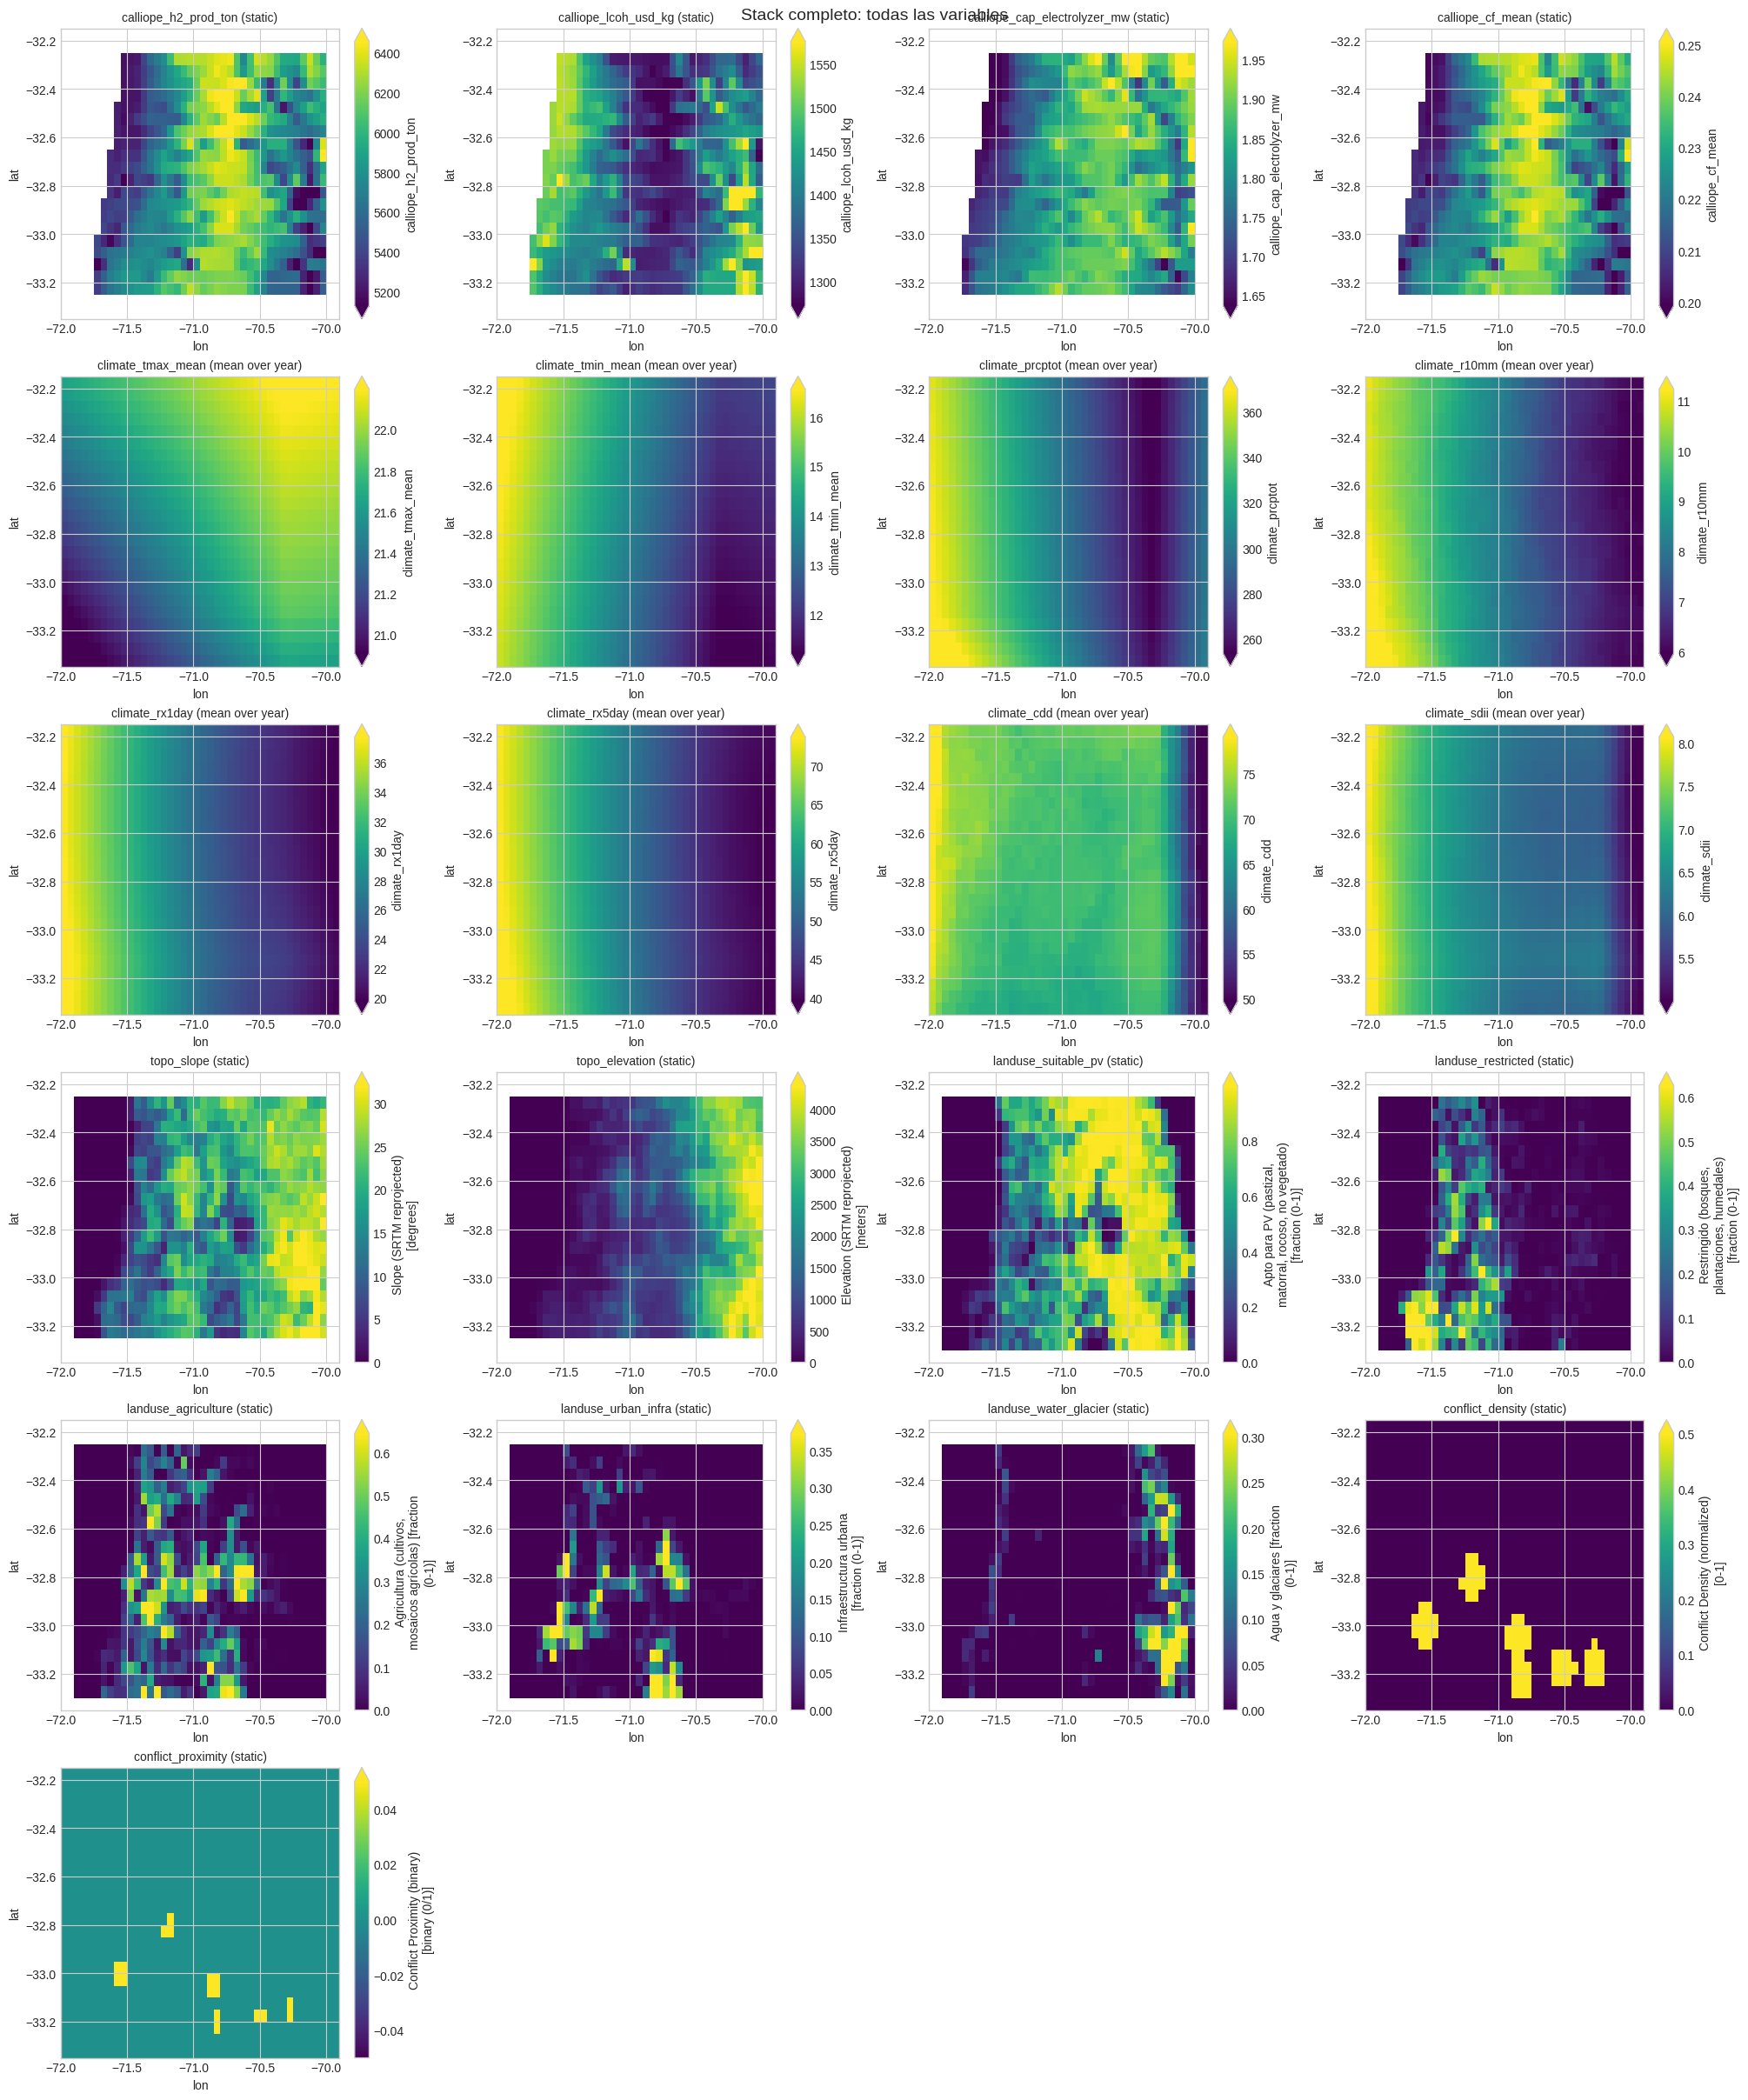

In [50]:
# Plotear un mapa por cada variable (automatizado)
import matplotlib.pyplot as plt
import numpy as np

vars_list = list(ds.data_vars.keys())
n_vars = len(vars_list)

# Configurar grid de subplots (ajusta filas/columnas según prefieras)
ncols = 4
nrows = int(np.ceil(n_vars / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), constrained_layout=True)
axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes

for i, var in enumerate(vars_list):
    ax = axes_flat[i]
    da_var = ds[var]
    
    # Si tiene dimensión 'year', calcular media temporal
    if 'year' in da_var.dims:
        img = da_var.mean(dim='year')
        title_suffix = '(mean over year)'
    else:
        img = da_var
        title_suffix = '(static)'
    
    # Plotear
    try:
        img.plot.imshow(ax=ax, cmap='viridis', add_colorbar=True, robust=True)
    except Exception as e:
        # fallback por si xarray falla
        ax.imshow(np.squeeze(img.values), cmap='viridis', aspect='auto')
        ax.set_title(f'{var} {title_suffix}\n(fallback)')
        print(f'Warning plotting {var}: {e}')
        continue
    
    ax.set_title(f'{var} {title_suffix}', fontsize=10)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

# Ocultar ejes sobrantes
for j in range(i+1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.suptitle('Stack completo: todas las variables', fontsize=14, y=1.00)
plt.show()


### Mapas individuales agrupados por categoría (opcional, más grande)

Si quieres ver los mapas más grandes y agrupados por tipo (calliope, climate, topo, landuse, conflict), usa la celda siguiente.

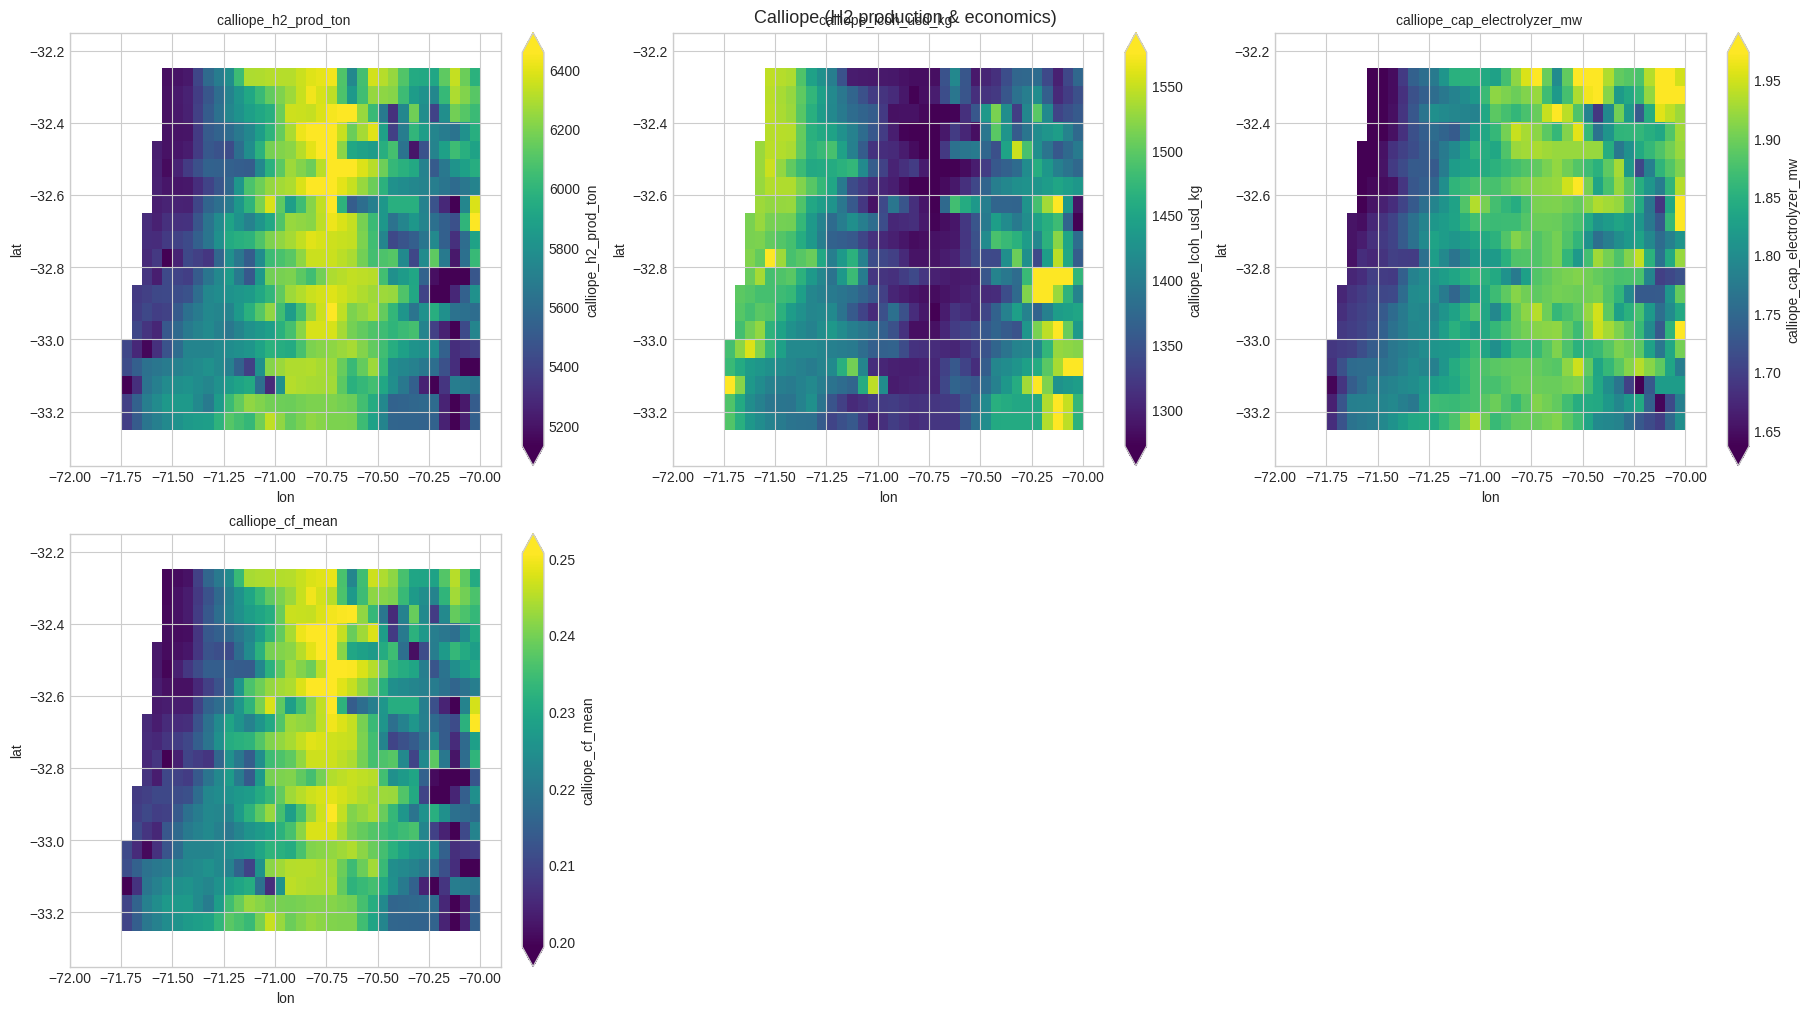

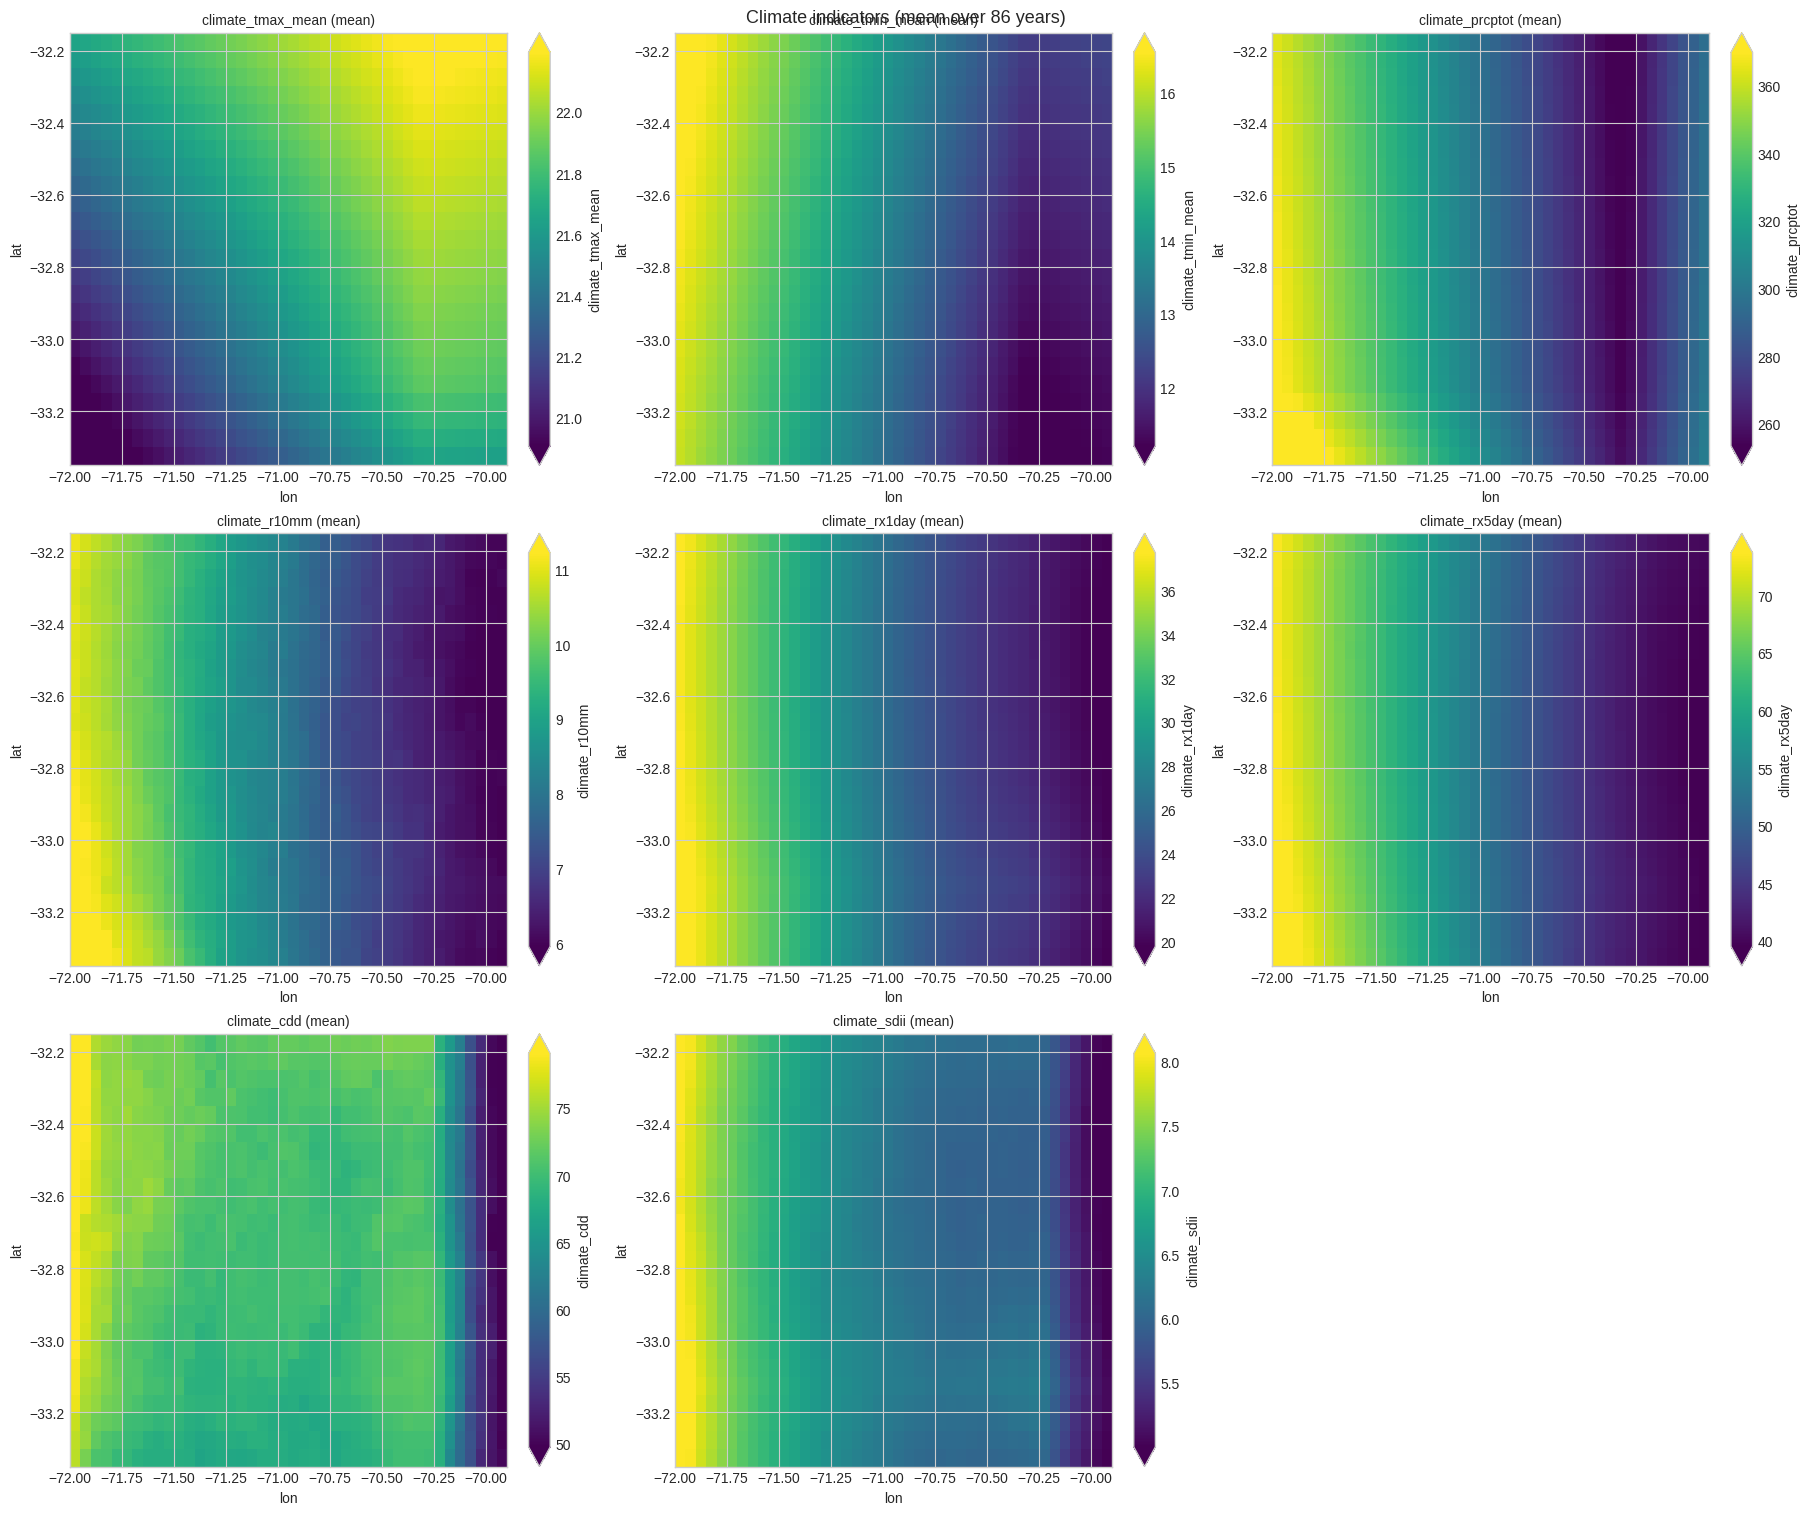

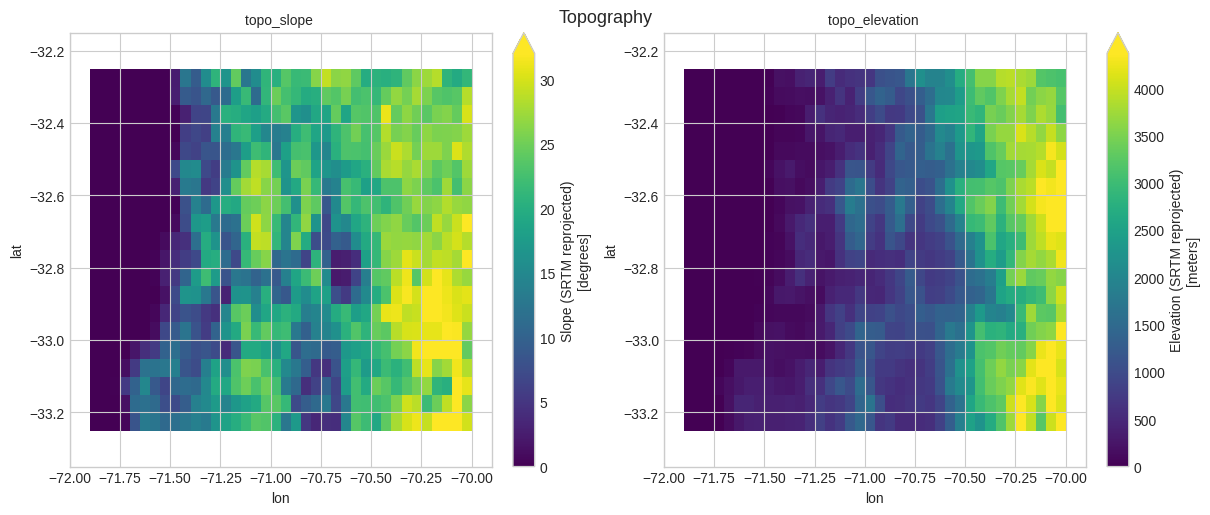

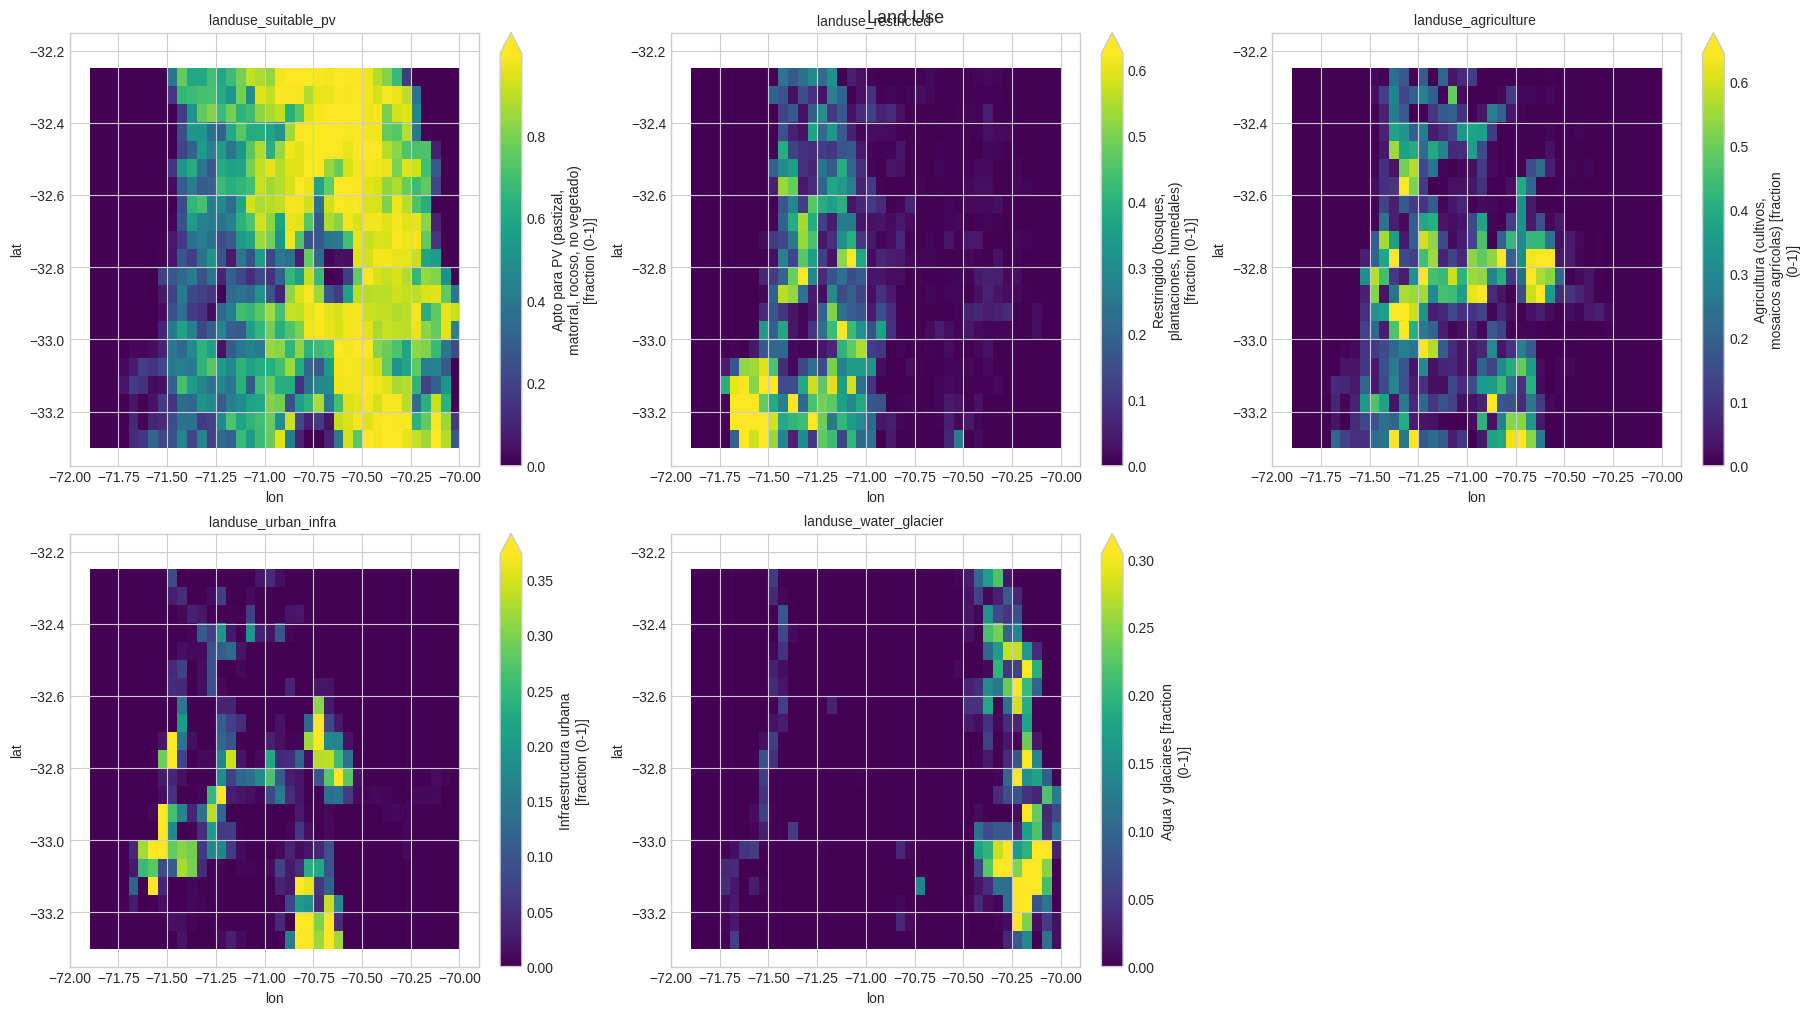

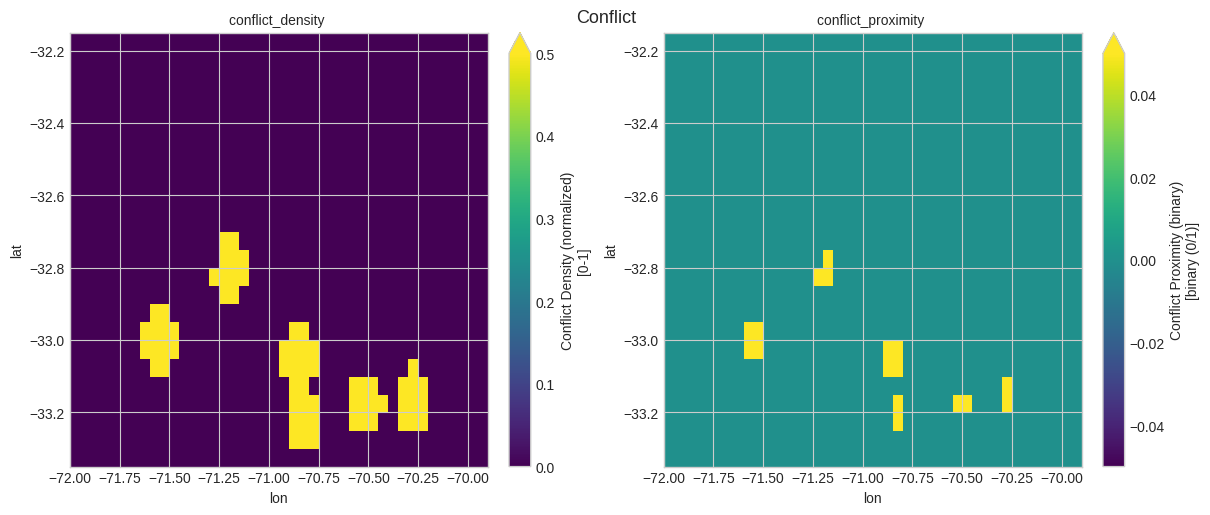

In [51]:
# Agrupar variables por categoría y plotear por grupos
categories = {
    'Calliope (H2 production & economics)': [v for v in vars_list if v.startswith('calliope_')],
    'Climate indicators (mean over 86 years)': [v for v in vars_list if v.startswith('climate_')],
    'Topography': [v for v in vars_list if v.startswith('topo_')],
    'Land Use': [v for v in vars_list if v.startswith('landuse_')],
    'Conflict': [v for v in vars_list if v.startswith('conflict_')]
}

for cat_name, cat_vars in categories.items():
    if not cat_vars:
        continue
    n = len(cat_vars)
    ncols_cat = min(3, n)
    nrows_cat = int(np.ceil(n / ncols_cat))
    
    fig, axes = plt.subplots(nrows_cat, ncols_cat, figsize=(6*ncols_cat, 5*nrows_cat), constrained_layout=True)
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if nrows_cat > 1 else axes
    
    for i, var in enumerate(cat_vars):
        ax = axes[i]
        da_var = ds[var]
        
        if 'year' in da_var.dims:
            img = da_var.mean(dim='year')
            suffix = '(mean)'
        else:
            img = da_var
            suffix = ''
        
        try:
            im = img.plot.imshow(ax=ax, cmap='viridis', add_colorbar=True, robust=True)
        except Exception as e:
            ax.imshow(np.squeeze(img.values), cmap='viridis', aspect='auto')
            ax.set_title(f'{var} {suffix}\n(fallback)', fontsize=9)
            print(f'Warning: {var} -> {e}')
            continue
        
        ax.set_title(f'{var} {suffix}', fontsize=10)
        ax.set_xlabel('lon')
        ax.set_ylabel('lat')
    
    # ocultar sobrantes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(cat_name, fontsize=13, y=1.00)
    plt.show()


## 🗺️ Validación Visual con Mapa Base Real

Validar cada variable estática comparándola con un mapa geográfico real del Valle de Aconcagua para verificar orientación espacial.

In [52]:
# Imports adicionales para mapas base
try:
    import contextily as ctx
    HAS_CONTEXTILY = True
    print("✓ contextily disponible")
except ImportError:
    HAS_CONTEXTILY = False
    print("⚠️  contextily no disponible - usando solo coordenadas")

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
    print("✓ cartopy disponible")
except ImportError:
    HAS_CARTOPY = False
    print("⚠️  cartopy no disponible")

# Para conversión de coordenadas
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

✓ contextily disponible
✓ cartopy disponible


In [53]:
def plot_variable_with_basemap(ds, var_name, cmap='viridis', vmin=None, vmax=None, 
                                title_suffix="", save_path=None):
    """
    Visualiza una variable del dataset sobre un mapa base real.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset con la variable a visualizar
    var_name : str
        Nombre de la variable
    cmap : str
        Colormap a usar
    vmin, vmax : float
        Límites de la escala de colores
    title_suffix : str
        Sufijo para el título
    save_path : str
        Ruta para guardar la figura
    """
    
    if var_name not in ds.data_vars:
        print(f"⚠️ Variable {var_name} no encontrada")
        return
    
    # Extraer datos
    data = ds[var_name].values
    lats = ds.lat.values
    lons = ds.lon.values
    
    # DEBUG: Verificar orden de coordenadas
    print(f"\n🔍 DEBUG - Orden de coordenadas:")
    print(f"   lats[0]={lats[0]:.4f} (primer valor) | lats[-1]={lats[-1]:.4f} (último valor)")
    print(f"   lons[0]={lons[0]:.4f} (primer valor) | lons[-1]={lons[-1]:.4f} (último valor)")
    print(f"   Orden lats: {'DESCENDENTE (N→S)' if lats[0] > lats[-1] else 'ASCENDENTE (S→N)'}")
    print(f"   data.shape: {data.shape}")
    
    # Crear figura con 2 subplots: mapa con basemap + solo la variable
    if HAS_CARTOPY:
        fig = plt.figure(figsize=(20, 8))
        
        # Subplot 1: Con mapa base usando cartopy
        ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
        
        # Configurar extensión del mapa
        extent = [lons.min(), lons.max(), lats.min(), lats.max()]
        ax1.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Agregar características geográficas
        ax1.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')
        ax1.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='gray')
        ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
        ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
        
        # Crear malla de coordenadas 2D para pcolormesh
        # CRÍTICO: Respetar orden de latitudes (norte=arriba en data, pero lats puede estar invertido)
        # Calcular espaciado de celdas
        dlon = np.abs(np.diff(lons).mean()) if len(lons) > 1 else 0.05
        dlat = np.abs(np.diff(lats).mean()) if len(lats) > 1 else 0.05

        # Crear bordes desde min/max reales, respetando orden creciente para pcolormesh
        lon_edges = np.linspace(lons.min() - dlon/2, lons.max() + dlon/2, len(lons) + 1)
        lat_edges = np.linspace(lats.min() - dlat/2, lats.max() + dlat/2, len(lats) + 1)

        # Si lats está en orden decreciente (típico), invertir data para que coincida con lat_edges ascendente
        if lats[0] > lats[-1]:  # Orden descendente (norte a sur)
            data_plot = np.flipud(data)  # Invertir verticalmente
            print(f"   ✅ Aplicando flipud() para corregir orientación")
        else:
            data_plot = data
            print(f"   ℹ️ Sin inversión necesaria (lats ya ascendente)")
        
        print(f"   lat_edges: [{lat_edges[0]:.4f}, ..., {lat_edges[-1]:.4f}]")
        print(f"   data_plot[0,0] corresponderá a lat={lat_edges[0]:.4f}, lon={lon_edges[0]:.4f}\n")

        # Plotear la variable
        im1 = ax1.pcolormesh(lon_edges, lat_edges, data_plot, transform=ccrs.PlateCarree(), 
                             cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.7, shading='flat')
        
        # Agregar gridlines
        gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        ax1.set_title(f'🗺️ {var_name} sobre Mapa Base (Cartopy)\n{title_suffix}', 
                     fontsize=13, fontweight='bold', pad=10)
        
        plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.05, fraction=0.046)
        
    else:
        fig = plt.figure(figsize=(20, 8))
        ax1 = fig.add_subplot(1, 2, 1)
        
        # Sin cartopy, usar imshow con extent
        extent = [lons.min(), lons.max(), lats.min(), lats.max()]
        im1 = ax1.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, 
                        extent=extent, origin='upper', aspect='auto', alpha=0.8)
        
        ax1.set_xlabel('Longitud (°)', fontsize=11)
        ax1.set_ylabel('Latitud (°)', fontsize=11)
        ax1.set_title(f'🗺️ {var_name} con Coordenadas Reales\n{title_suffix}', 
                     fontsize=13, fontweight='bold', pad=10)
        ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        
        plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.05, fraction=0.046)
    
    # Subplot 2: Variable sola (sin basemap) para verificación de orientación
    ax2 = fig.add_subplot(1, 2, 2)
    im2 = ax2.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, 
                    origin='upper', aspect='auto')
    
    ax2.set_xlabel('Índice Longitud →', fontsize=11)
    ax2.set_ylabel('Índice Latitud ↓', fontsize=11)
    ax2.set_title(f'📊 {var_name} (Array Original)\norigin="upper" → data[0,:] = arriba', 
                 fontsize=13, fontweight='bold', pad=10)
    
    # Anotar coordenadas en las esquinas CON ÍNDICES
    # Arriba-izquierda = data[0, 0]
    ax2.text(0.02, 0.98, 
             f'data[0,0]\nlat={lats[0]:.3f}°\nlon={lons[0]:.3f}°', 
             transform=ax2.transAxes, va='top', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Arriba-derecha = data[0, -1]
    ax2.text(0.98, 0.98, 
             f'data[0,-1]\nlat={lats[0]:.3f}°\nlon={lons[-1]:.3f}°', 
             transform=ax2.transAxes, va='top', ha='right', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Abajo-izquierda = data[-1, 0]
    ax2.text(0.02, 0.02, 
             f'data[-1,0]\nlat={lats[-1]:.3f}°\nlon={lons[0]:.3f}°', 
             transform=ax2.transAxes, va='bottom', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    # Abajo-derecha = data[-1, -1]
    ax2.text(0.98, 0.02, 
             f'data[-1,-1]\nlat={lats[-1]:.3f}°\nlon={lons[-1]:.3f}°', 
             transform=ax2.transAxes, va='bottom', ha='right', fontsize=8,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    # Agregar indicadores de dirección geográfica
    ax2.text(0.5, 0.98, '⬆ NORTE' if lats[0] > lats[-1] else '⬆ SUR', 
             transform=ax2.transAxes, va='top', ha='center', fontsize=10,
             fontweight='bold', color='red')
    ax2.text(0.5, 0.02, '⬇ SUR' if lats[0] > lats[-1] else '⬇ NORTE', 
             transform=ax2.transAxes, va='bottom', ha='center', fontsize=10,
             fontweight='bold', color='blue')
    
    plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.05, fraction=0.046)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Guardado en: {save_path}")
    
    plt.show()
    
    # Resumen estadístico
    valid_data = data[~np.isnan(data)]
    if len(valid_data) > 0:
        print(f"\n📊 Estadísticas de {var_name}:")
        print(f"   Min: {valid_data.min():.4f}")
        print(f"   Max: {valid_data.max():.4f}")
        print(f"   Media: {valid_data.mean():.4f}")
        print(f"   NaNs: {np.isnan(data).sum()} / {data.size} ({np.isnan(data).sum()/data.size*100:.1f}%)")
    
    print("\n" + "="*80)

print("✅ Función plot_variable_with_basemap() definida")

✅ Función plot_variable_with_basemap() definida


In [54]:
# Configuración de visualización para cada variable
VAR_VISUALIZATION_CONFIG = {
    'topo_elevation': {
        'cmap': 'terrain',
        'vmin': 0,
        'vmax': None,  # Auto
        'title': 'Elevación Topográfica (m)'
    },
    'topo_slope': {
        'cmap': 'YlOrRd',
        'vmin': 0,
        'vmax': None,
        'title': 'Pendiente (°)'
    },
    'landuse_suitable_pv': {
        'cmap': 'RdYlGn',
        'vmin': 0,
        'vmax': 1,
        'title': 'Aptitud para PV (fracción)'
    },
    'landuse_restricted': {
        'cmap': 'Reds',
        'vmin': 0,
        'vmax': 1,
        'title': 'Áreas Restringidas (fracción)'
    },
    'landuse_agriculture': {
        'cmap': 'Greens',
        'vmin': 0,
        'vmax': 1,
        'title': 'Agricultura (fracción)'
    },
    'landuse_urban_infra': {
        'cmap': 'Greys',
        'vmin': 0,
        'vmax': 1,
        'title': 'Urbano e Infraestructura (fracción)'
    },
    'landuse_water_glacier': {
        'cmap': 'Blues',
        'vmin': 0,
        'vmax': 1,
        'title': 'Agua y Glaciares (fracción)'
    },
    'conflict_density': {
        'cmap': 'Oranges',
        'vmin': 0,
        'vmax': 1,
        'title': 'Densidad de Conflictos (normalizada)'
    },
    'conflict_proximity': {
        'cmap': 'YlOrBr',
        'vmin': 0,
        'vmax': 1,
        'title': 'Proximidad a Conflictos (normalizada)'
    }
}

print("✅ Configuración de visualización definida")
print(f"Variables configuradas: {len(VAR_VISUALIZATION_CONFIG)}")

✅ Configuración de visualización definida
Variables configuradas: 9


### 📋 Instrucciones de Validación

**Para cada variable, verifica:**

1. **Orientación geográfica correcta**:
   - 🏔️ **Cordillera de Los Andes**: Debe estar al **ESTE** (derecha, lon ~ -70.0°)
   - 🌊 **Océano Pacífico**: Debe estar al **OESTE** (izquierda, lon ~ -72.0°)
   - 🧭 **Norte**: Arriba (lat ~ -32.2°)
   - 🧭 **Sur**: Abajo (lat ~ -33.3°)

2. **Coherencia de datos**:
   - **Elevación**: Máxima al este (cordillera), baja al oeste (costa)
   - **Pendiente**: Mayor al este (montañas), menor al oeste (valle/costa)
   - **Agricultura**: Concentrada en valles centrales
   - **Urbano**: Cerca de valles y rutas principales
   - **Agua/Glaciares**: Zonas altas (cordillera)
   - **Conflictos**: Zonas de desarrollo/minería

3. **Si algo está invertido**, anótalo para corrección posterior

---

🔍 VALIDACIÓN VISUAL DE VARIABLES ESTÁTICAS


📍 [1/9] Validando: topo_elevation

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_topo_elevation.png


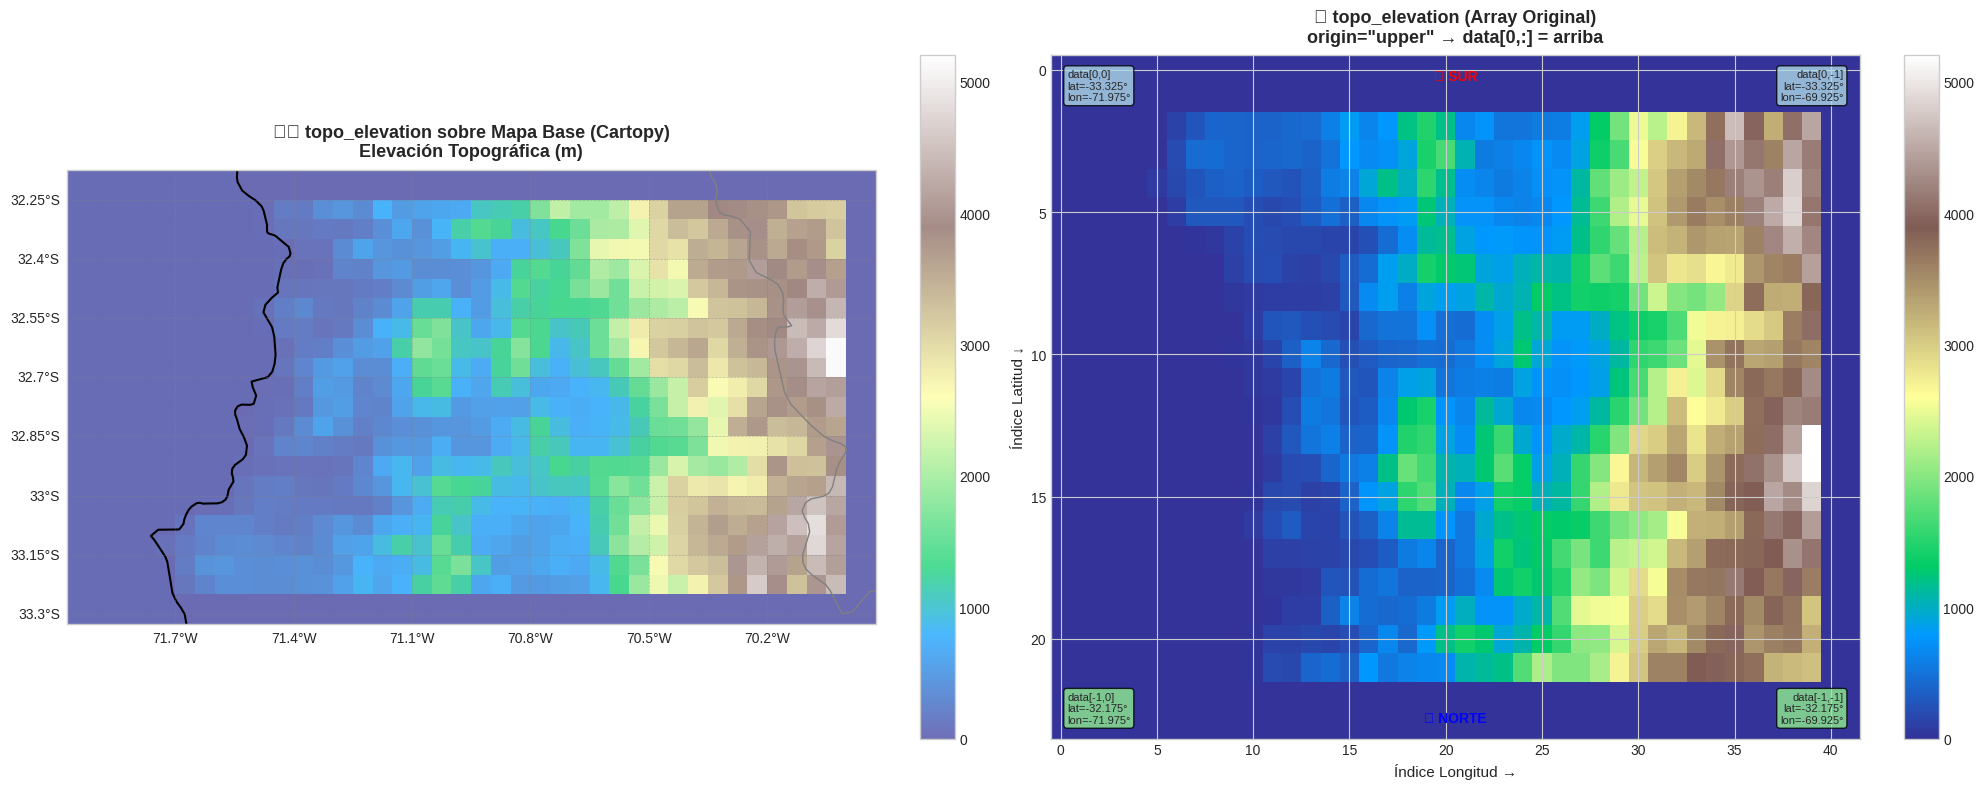


📊 Estadísticas de topo_elevation:
   Min: 0.0000
   Max: 5199.1768
   Media: 999.2423
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de topo_elevation
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [2/9] Validando: topo_slope

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_topo_slope.png


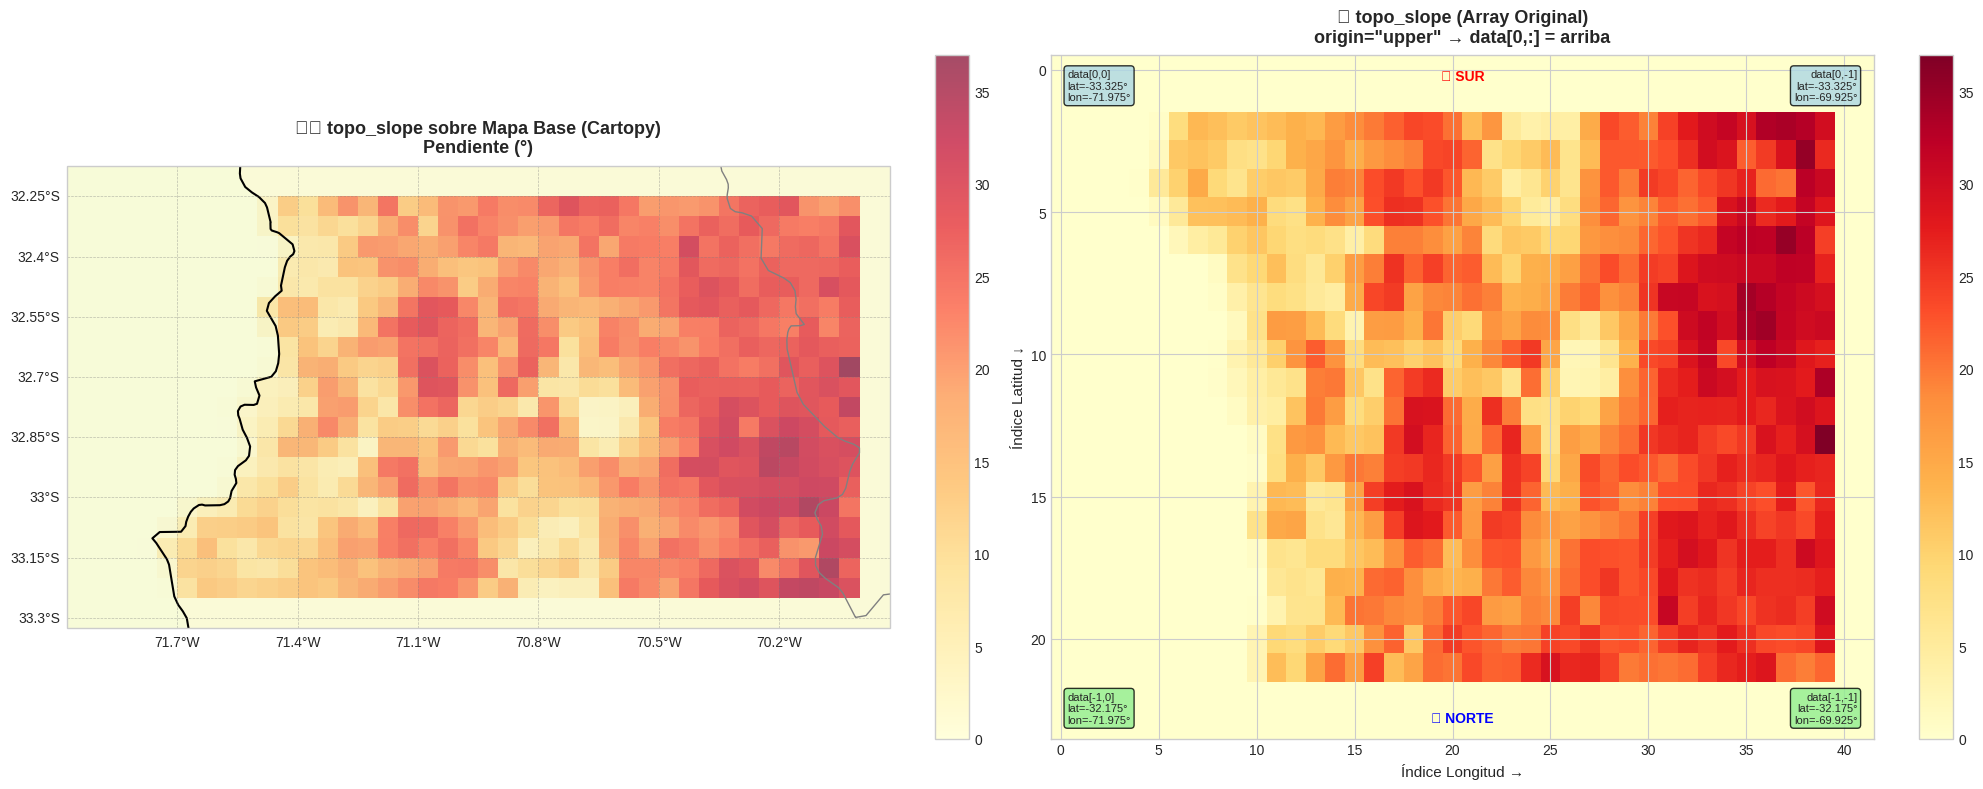


📊 Estadísticas de topo_slope:
   Min: 0.0000
   Max: 36.9486
   Media: 11.8163
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de topo_slope
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [3/9] Validando: landuse_suitable_pv

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_landuse_suitable_pv.png


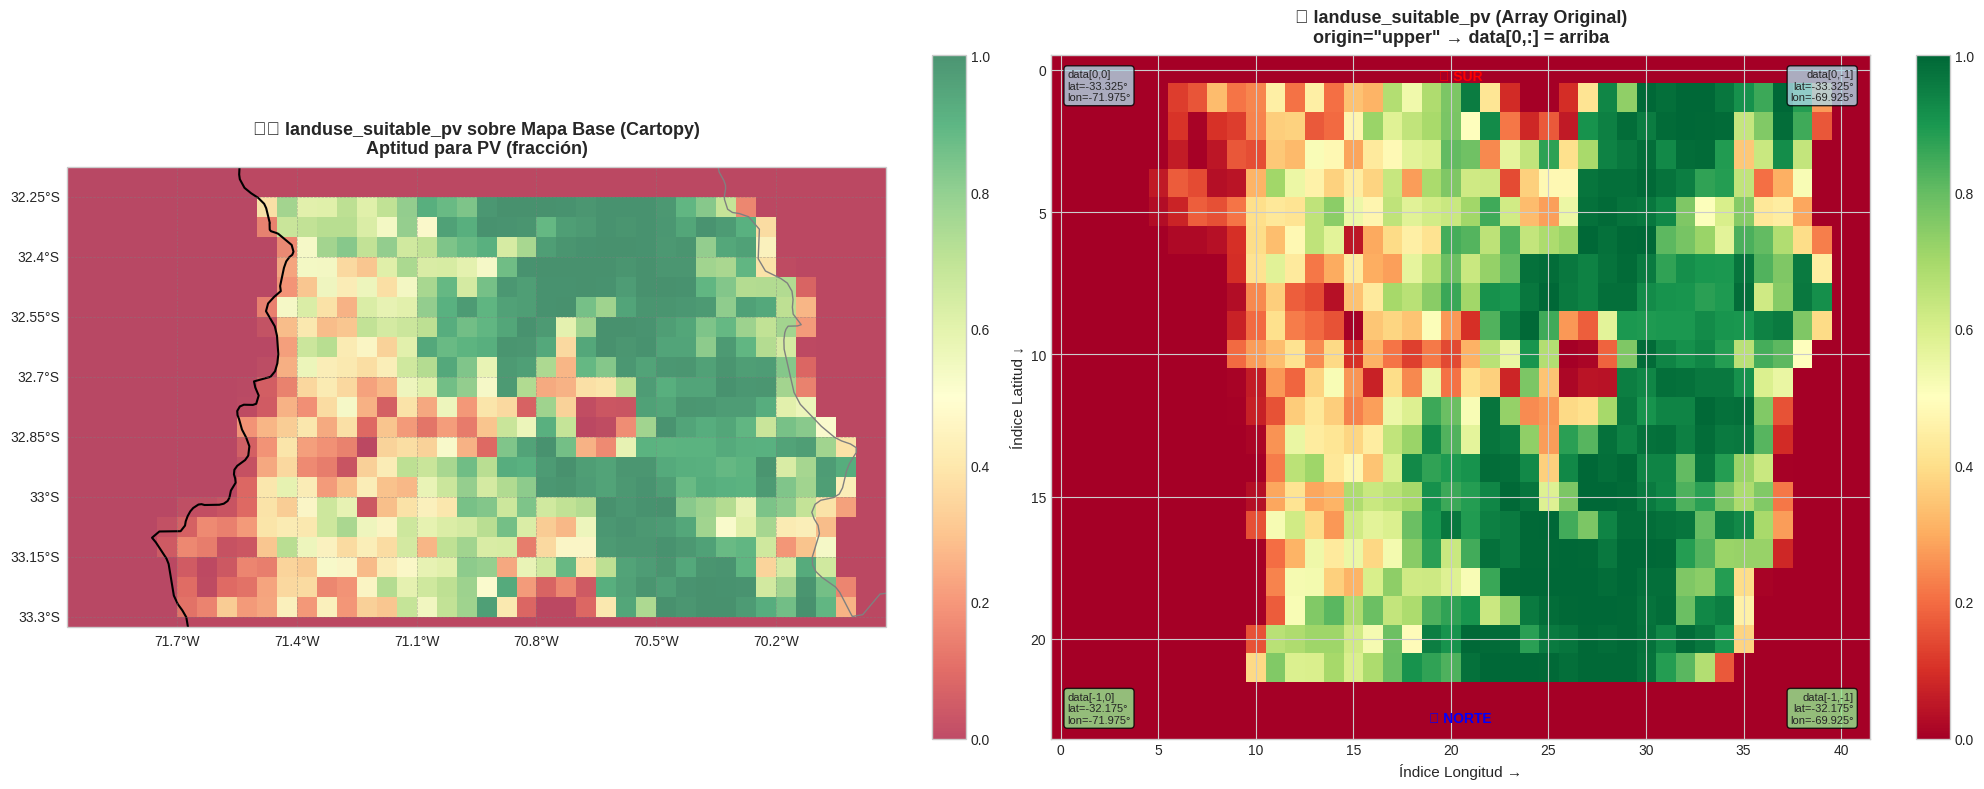


📊 Estadísticas de landuse_suitable_pv:
   Min: 0.0000
   Max: 1.0000
   Media: 0.3933
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de landuse_suitable_pv
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [4/9] Validando: landuse_restricted

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_landuse_restricted.png


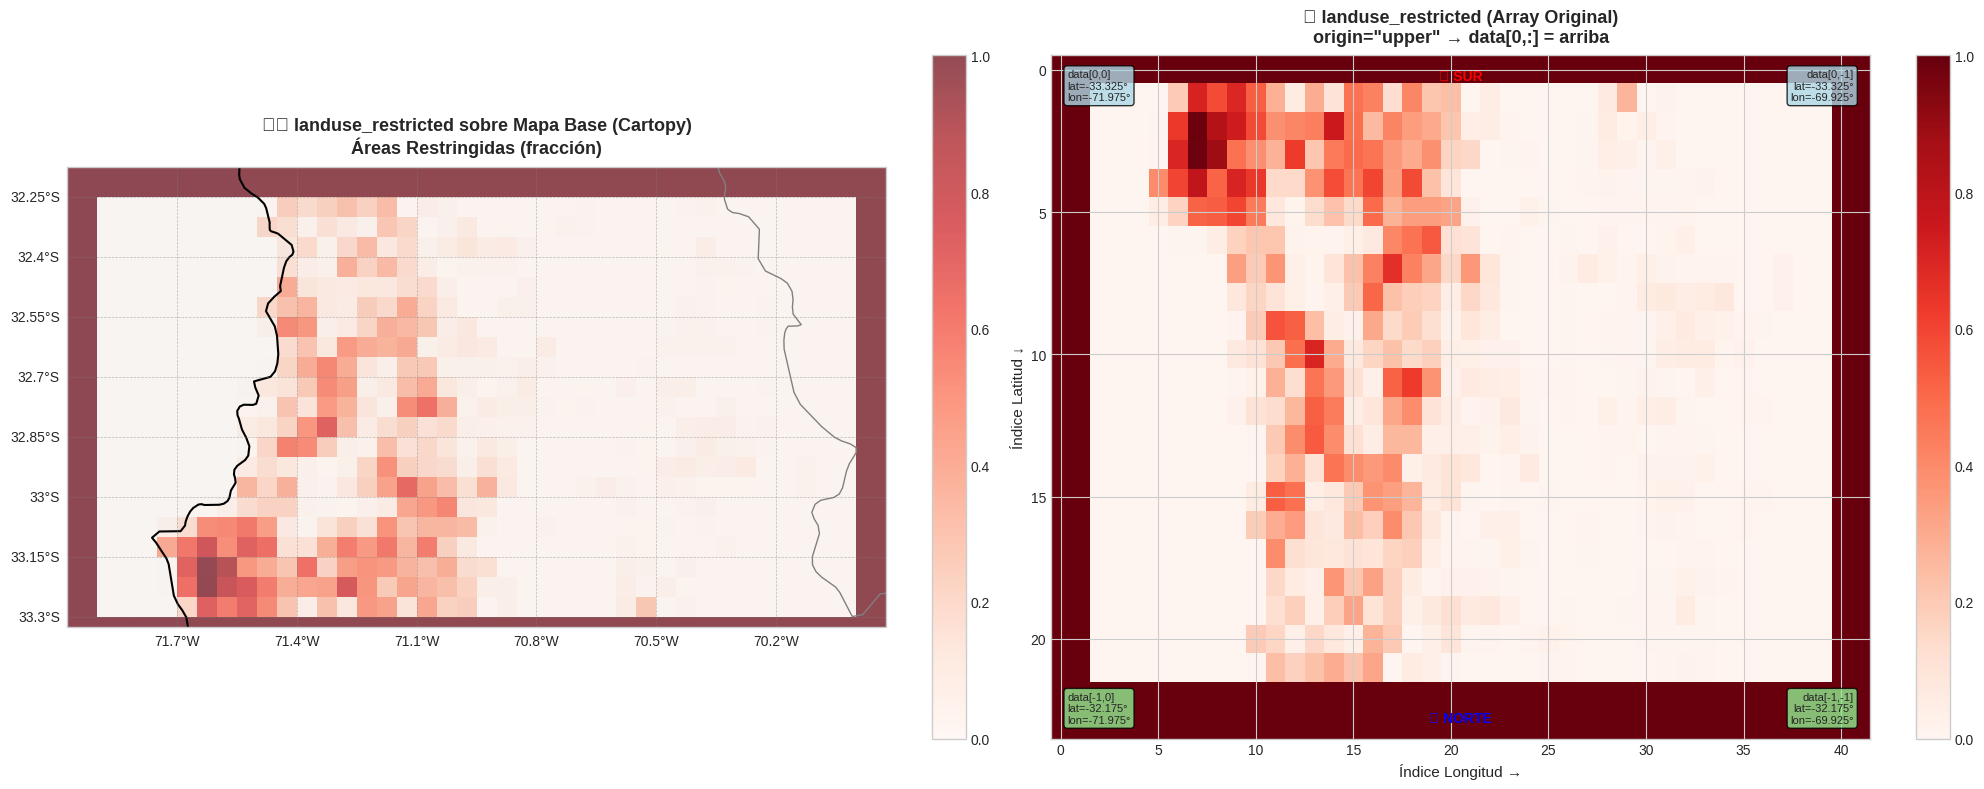


📊 Estadísticas de landuse_restricted:
   Min: 0.0000
   Max: 1.0000
   Media: 0.2790
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de landuse_restricted
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [5/9] Validando: landuse_agriculture

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_landuse_agriculture.png


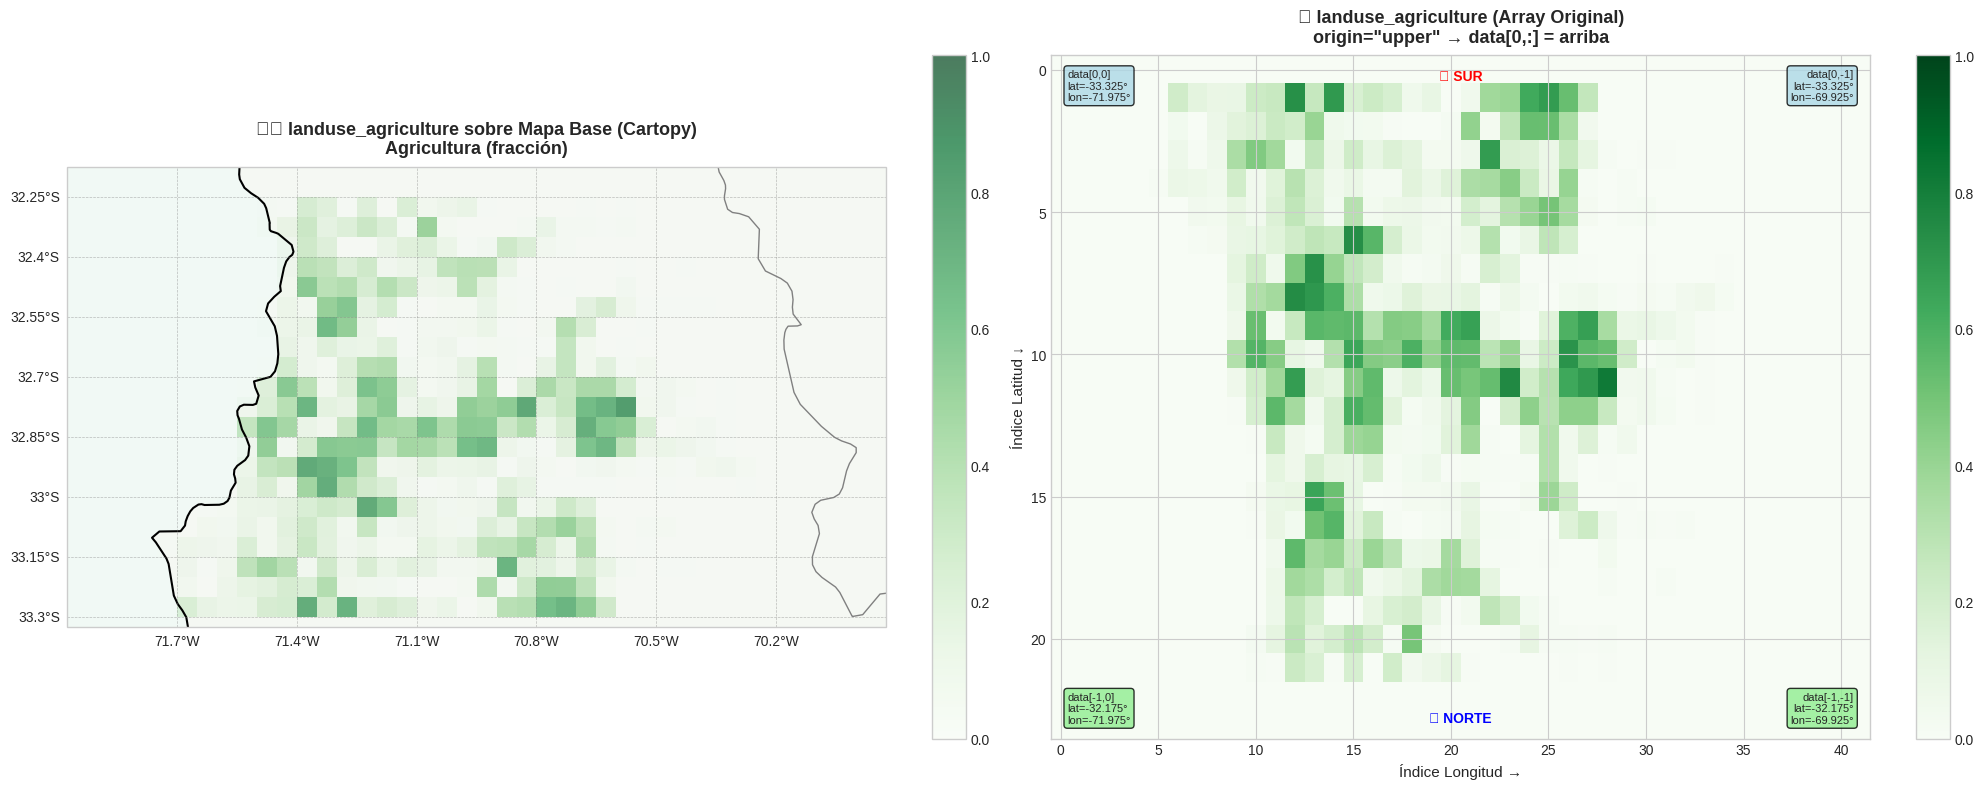


📊 Estadísticas de landuse_agriculture:
   Min: 0.0000
   Max: 0.8190
   Media: 0.0792
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de landuse_agriculture
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [6/9] Validando: landuse_urban_infra

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_landuse_urban_infra.png


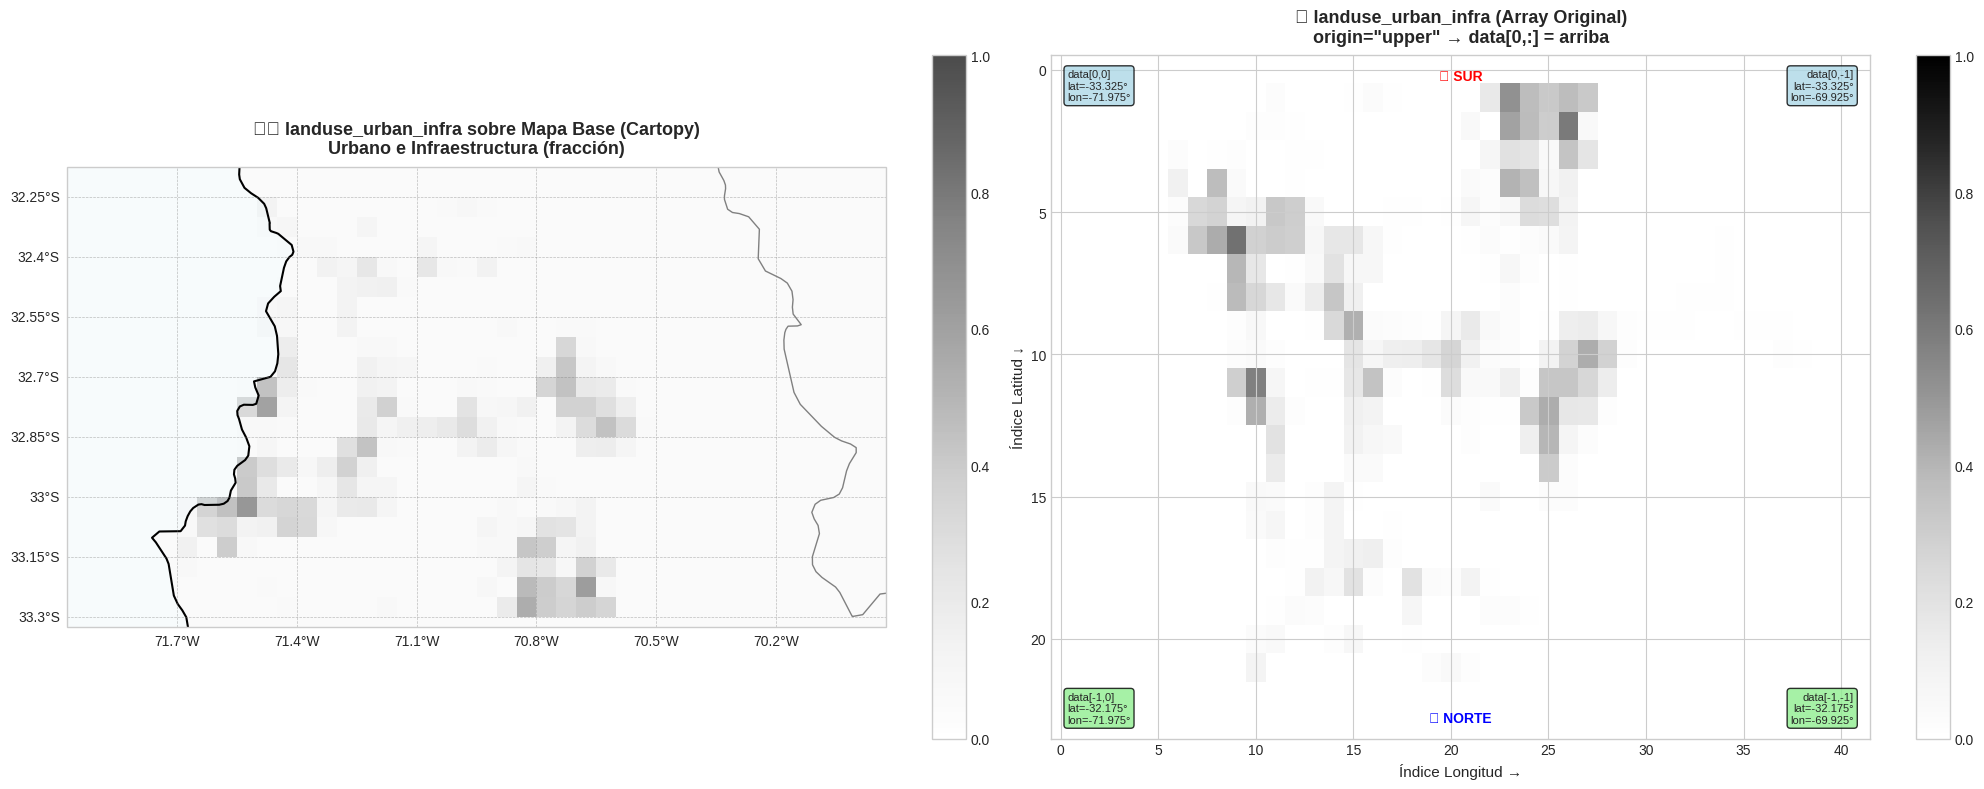


📊 Estadísticas de landuse_urban_infra:
   Min: 0.0000
   Max: 0.6290
   Media: 0.0268
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de landuse_urban_infra
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [7/9] Validando: landuse_water_glacier

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_landuse_water_glacier.png


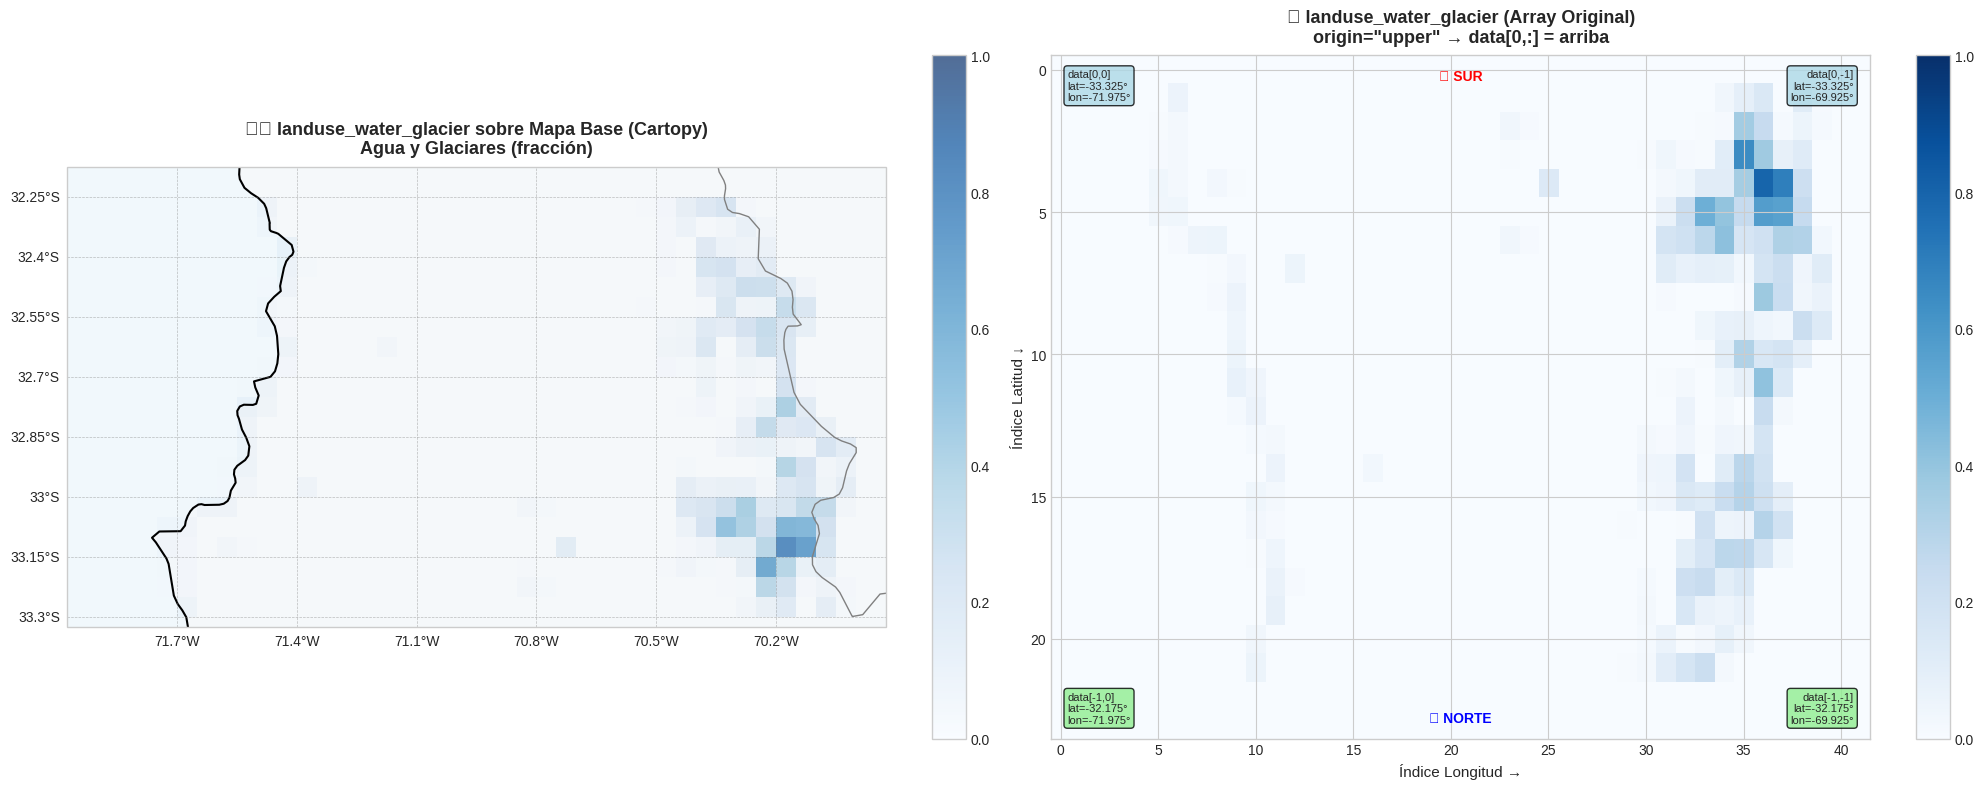


📊 Estadísticas de landuse_water_glacier:
   Min: 0.0000
   Max: 0.7945
   Media: 0.0213
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de landuse_water_glacier
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [8/9] Validando: conflict_density

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_conflict_density.png


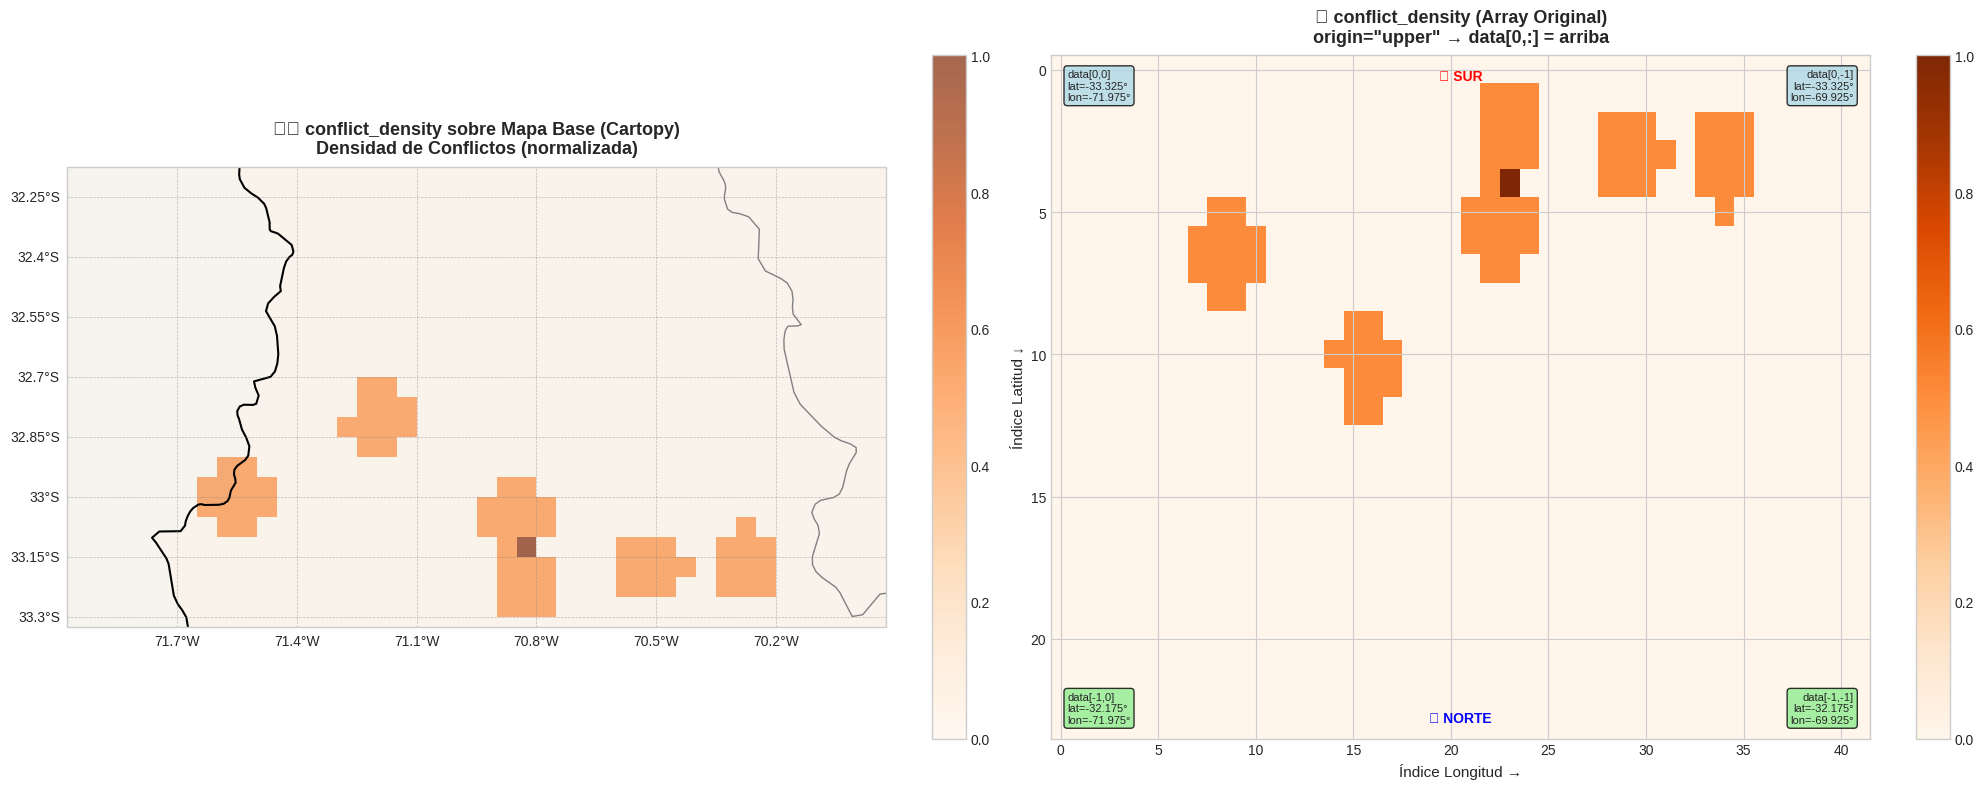


📊 Estadísticas de conflict_density:
   Min: 0.0000
   Max: 1.0000
   Media: 0.0322
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de conflict_density
   ¿Está correctamente orientada? (Anota si requiere inversión)



📍 [9/9] Validando: conflict_proximity

🔍 DEBUG - Orden de coordenadas:
   lats[0]=-33.3250 (primer valor) | lats[-1]=-32.1750 (último valor)
   lons[0]=-71.9750 (primer valor) | lons[-1]=-69.9250 (último valor)
   Orden lats: ASCENDENTE (S→N)
   data.shape: (24, 42)
   ℹ️ Sin inversión necesaria (lats ya ascendente)
   lat_edges: [-33.3500, ..., -32.1500]
   data_plot[0,0] corresponderá a lat=-33.3500, lon=-72.0000

💾 Guardado en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap/validation_conflict_proximity.png


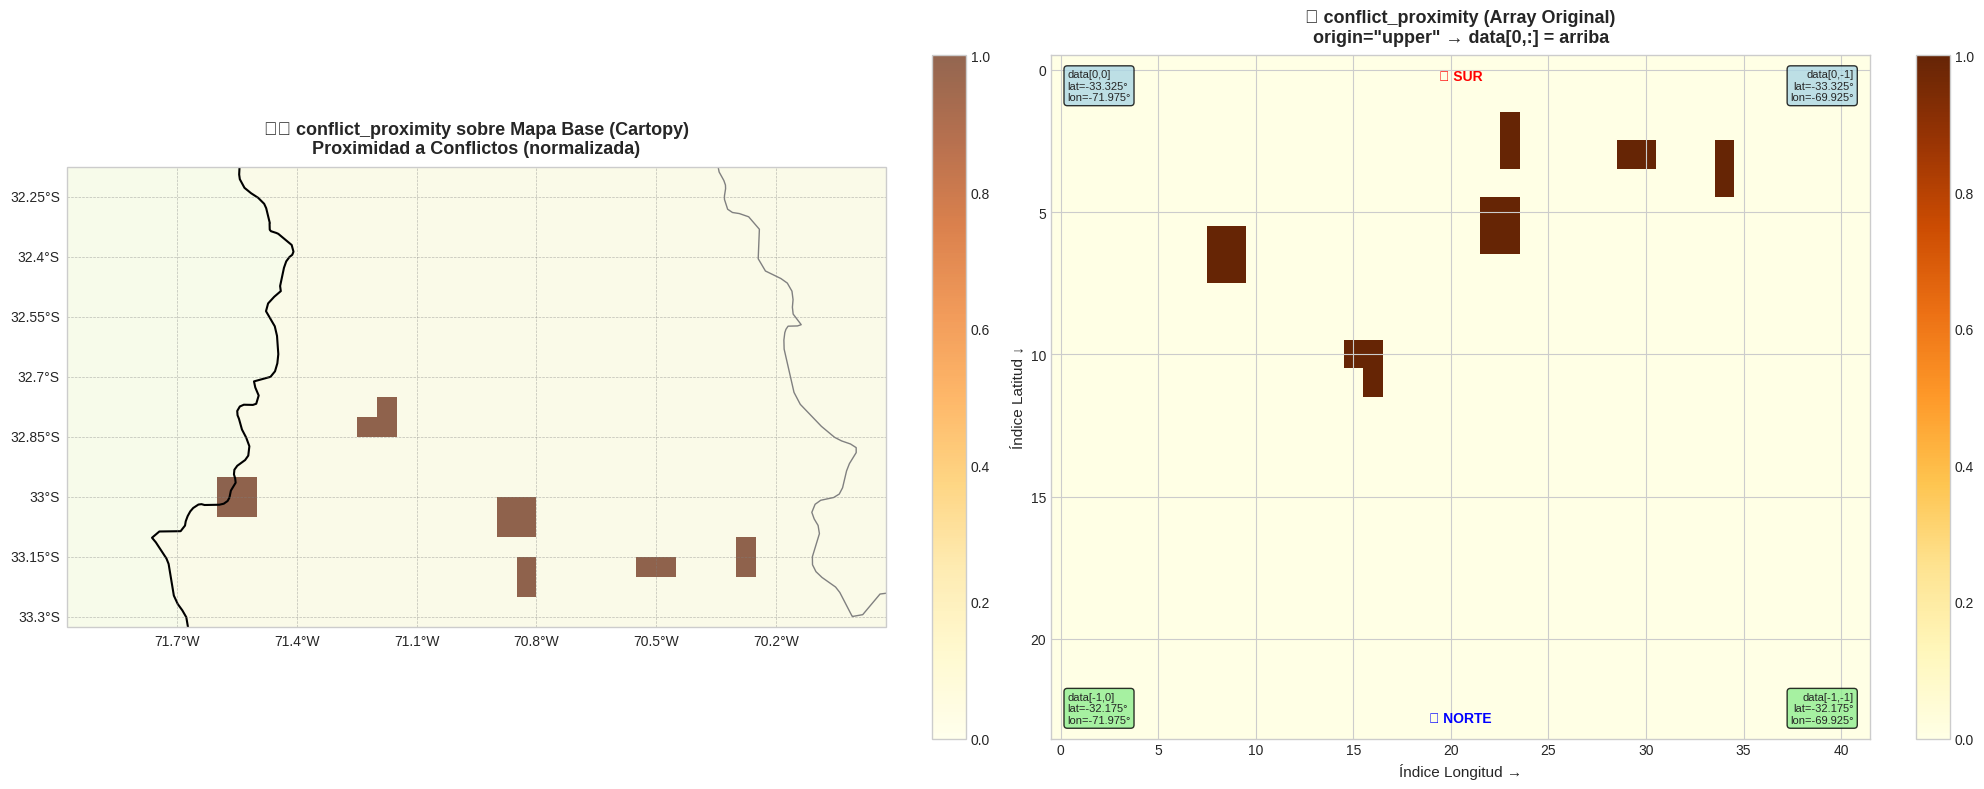


📊 Estadísticas de conflict_proximity:
   Min: 0.0000
   Max: 1.0000
   Media: 0.0169
   NaNs: 0 / 1008 (0.0%)


✋ Revisa la orientación de conflict_proximity
   ¿Está correctamente orientada? (Anota si requiere inversión)



✅ VALIDACIÓN VISUAL COMPLETADA

💾 Todas las validaciones guardadas en: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_analysis/validation_basemap

Revisa cada imagen y anota qué variables requieren corrección.


In [55]:
# ITERAR POR CADA VARIABLE ESTÁTICA PARA VALIDACIÓN VISUAL
print("="*80)
print("🔍 VALIDACIÓN VISUAL DE VARIABLES ESTÁTICAS")
print("="*80)
print()

# Directorio para guardar validaciones
VALIDATION_DIR = PLOTS_DIR / 'validation_basemap'
VALIDATION_DIR.mkdir(exist_ok=True, parents=True)

# Iterar por cada variable estática
for i, (var_name, config) in enumerate(VAR_VISUALIZATION_CONFIG.items(), 1):
    print(f"\n{'='*80}")
    print(f"📍 [{i}/{len(VAR_VISUALIZATION_CONFIG)}] Validando: {var_name}")
    print(f"{'='*80}")
    
    if var_name in ds_ref.data_vars:
        save_path = VALIDATION_DIR / f'validation_{var_name}.png'
        
        plot_variable_with_basemap(
            ds=ds_ref,
            var_name=var_name,
            cmap=config['cmap'],
            vmin=config['vmin'],
            vmax=config['vmax'],
            title_suffix=config['title'],
            save_path=save_path
        )
        
        # Pausa para revisión visual
        print(f"\n✋ Revisa la orientación de {var_name}")
        print(f"   ¿Está correctamente orientada? (Anota si requiere inversión)")
        print()
        
    else:
        print(f"⚠️ Variable {var_name} no encontrada en el dataset")
    
    print()

print("\n" + "="*80)
print("✅ VALIDACIÓN VISUAL COMPLETADA")
print("="*80)
print(f"\n💾 Todas las validaciones guardadas en: {VALIDATION_DIR}")
print("\nRevisa cada imagen y anota qué variables requieren corrección.")

In [56]:
print("=" * 80)
print("💾 CONFIGURANDO EXPORTACIÓN DE DATASETS IMPUTADOS")
print("=" * 80)

# Directorio de salida
OUTPUT_DIR = DATA_DIR / 'autoencoder_preprocessed'
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"\n📁 Directorio de salida: {OUTPUT_DIR}")

# Configuración de encoding para compresión
encoding_export = {
    'zlib': True,
    'complevel': 4,
    'shuffle': True,
    'fletcher32': True
}

print(f"\n⚙️ Configuración de compresión:")
print(f"   • Algoritmo: zlib")
print(f"   • Nivel: {encoding_export['complevel']} (1=rápido, 9=máximo)")
print(f"   • Shuffle: {encoding_export['shuffle']}")
print(f"   • Checksum: {encoding_export['fletcher32']}")

print("\n" + "=" * 80)

💾 CONFIGURANDO EXPORTACIÓN DE DATASETS IMPUTADOS

📁 Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack/autoencoder_preprocessed

⚙️ Configuración de compresión:
   • Algoritmo: zlib
   • Nivel: 4 (1=rápido, 9=máximo)
   • Shuffle: True
   • Checksum: True



In [57]:
print("=" * 80)
print("📝 AGREGANDO METADATOS GLOBALES")
print("=" * 80)

from datetime import datetime

# Metadatos globales
global_attrs = {
    'title': 'Multi-variable Stack for Autoencoder Training - Valle de Aconcagua',
    'institution': 'Universidad de Chile',
    'source': 'CMIP6 (bias-corrected), CR2MET, Calliope, MapBiomas',
    'history': f'Created on {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    'comment': 'Datasets ready for autoencoder preprocessing. NaNs preserved in Calliope variables.',
    'conventions': 'CF-1.8',
    'geospatial_lat_min': float(ds_ref.lat.min().values),
    'geospatial_lat_max': float(ds_ref.lat.max().values),
    'geospatial_lon_min': float(ds_ref.lon.min().values),
    'geospatial_lon_max': float(ds_ref.lon.max().values),
}

print(f"\n📋 Metadatos configurados: {len(global_attrs)} atributos")
print("\n" + "=" * 80)

📝 AGREGANDO METADATOS GLOBALES

📋 Metadatos configurados: 10 atributos



In [58]:
print("=" * 80)
print("💾 EXPORTANDO DATASETS IMPUTADOS")
print("=" * 80)

export_files = []

for scenario, ds in datasets_imputed.items():
    print(f"\n{'='*80}")
    print(f"📦 {scenario.upper()}")
    print(f"{'='*80}")
    
    # Copiar y agregar metadatos
    ds_export = ds.copy()
    ds_export.attrs.update(global_attrs)
    ds_export.attrs['scenario'] = scenario.upper()
    
    # Encoding para todas las variables
    encoding = {var: encoding_export.copy() for var in ds_export.data_vars}
    
    # Guardar
    output_file = OUTPUT_DIR / f'{scenario}_imputed.nc'
    print(f"💾 Guardando: {output_file.name}")
    
    ds_export.to_netcdf(output_file, encoding=encoding, format='NETCDF4')
    
    file_size_mb = output_file.stat().st_size / (1024**2)
    print(f"✅ Guardado: {file_size_mb:.2f} MB")
    
    export_files.append({
        'scenario': scenario,
        'file': output_file,
        'size_mb': file_size_mb,
        'n_vars': len(ds_export.data_vars)
    })

print(f"\n{'='*80}")
print("✅ EXPORTACIÓN COMPLETADA")
print(f"{'='*80}")

total_size = sum(info['size_mb'] for info in export_files)
print(f"\n📊 RESUMEN:")
for info in export_files:
    print(f"   • {info['scenario']}: {info['size_mb']:.2f} MB, {info['n_vars']} variables")
print(f"\n   TOTAL: {total_size:.2f} MB")
print(f"\n📁 {OUTPUT_DIR}")

💾 EXPORTANDO DATASETS IMPUTADOS

📦 SSP245
💾 Guardando: ssp245_imputed.nc
✅ Guardado: 1.36 MB

📦 SSP370
💾 Guardando: ssp370_imputed.nc
✅ Guardado: 1.37 MB

📦 SSP585
💾 Guardando: ssp585_imputed.nc
✅ Guardado: 1.37 MB

✅ EXPORTACIÓN COMPLETADA

📊 RESUMEN:
   • ssp245: 1.36 MB, 21 variables
   • ssp370: 1.37 MB, 21 variables
   • ssp585: 1.37 MB, 21 variables

   TOTAL: 4.10 MB

📁 /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_stack/autoencoder_preprocessed
